# Bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import pynvml
import psutil
import time

import cv2
import random
import torch, gc
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models
from sklearn.model_selection import train_test_split
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import warnings

warnings.filterwarnings("ignore")

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Leitura dos dados e tratamento dos dados

## Leitura dos dados

In [2]:
# Diretório base
base_data_dir = "data"

# Lista de subpastas válidas com gps_log.csv
data_folders = [
    os.path.join(base_data_dir, d)
    for d in os.listdir(base_data_dir)
    if os.path.isdir(os.path.join(base_data_dir, d)) and
       os.path.exists(os.path.join(base_data_dir, d, "gps_log.csv"))
]

print(f"Encontradas {len(data_folders)} rotas com gps_log.csv")

Encontradas 3 rotas com gps_log.csv


## Montagem do dataset

In [3]:
# Lista acumuladora dos dados de todas as rotas
dataset_gpss = []

for folder in data_folders:
    csv_path = os.path.join(folder, "gps_log.csv")
    images_dir = os.path.join(folder, "images")
    
    dataset_gps = pd.read_csv(csv_path)
    dataset_gps["label"] = dataset_gps["label"].astype(str).str.strip().str.lower()
    dataset_gps = dataset_gps[dataset_gps["label"].isin(["intersection", "straight", "curve"])].copy()
    
    # Caminho completo da imagem
    dataset_gps["filepath"] = images_dir + "/" + dataset_gps["filename"].astype(str).str.strip()
    
    # Rótulo binário: 1 = cruzamento, 0 = curva ou reta
    dataset_gps["target"] = dataset_gps["label"].apply(lambda x: 1 if x == "intersection" else 0)
    
    dataset_gpss.append(dataset_gps[["filepath", "target"]])

# Unifica os dados de todas as rotas
dataset_images = pd.concat(dataset_gpss, ignore_index=True)

In [4]:
# Colunas
COLUMNS = [
    "filename", "timestamp", "latitude", 
    "longitude", "node_index", "label"
]

# Lista acumuladora dos dados de todas as rotas
dataset_gpss = []

for folder in data_folders:
    csv_path = os.path.join(folder, "gps_log.csv")

    dataset_gps = pd.read_csv(csv_path, usecols=COLUMNS)
    dataset_gps["label"] = dataset_gps["label"].astype(str).str.strip().str.lower()
    dataset_gps = dataset_gps[dataset_gps["label"].isin(["intersection", "straight", "curve"])]

    dataset_gpss.append(dataset_gps)

# Unifica os dados de todas as rotas
dataset_gps = pd.concat(dataset_gpss, ignore_index=True)


## Analise exploratoria dos dados

In [5]:
# Drecrição dos dados
print(f"Total de imagens válidas: {len(dataset_images)}")
print("Distribuição das classes:")
print(dataset_images["target"].value_counts().rename({0: "Não cruzamento", 1: "Cruzamento"}))

Total de imagens válidas: 3132
Distribuição das classes:
Não cruzamento    1637
Cruzamento        1495
Name: target, dtype: int64


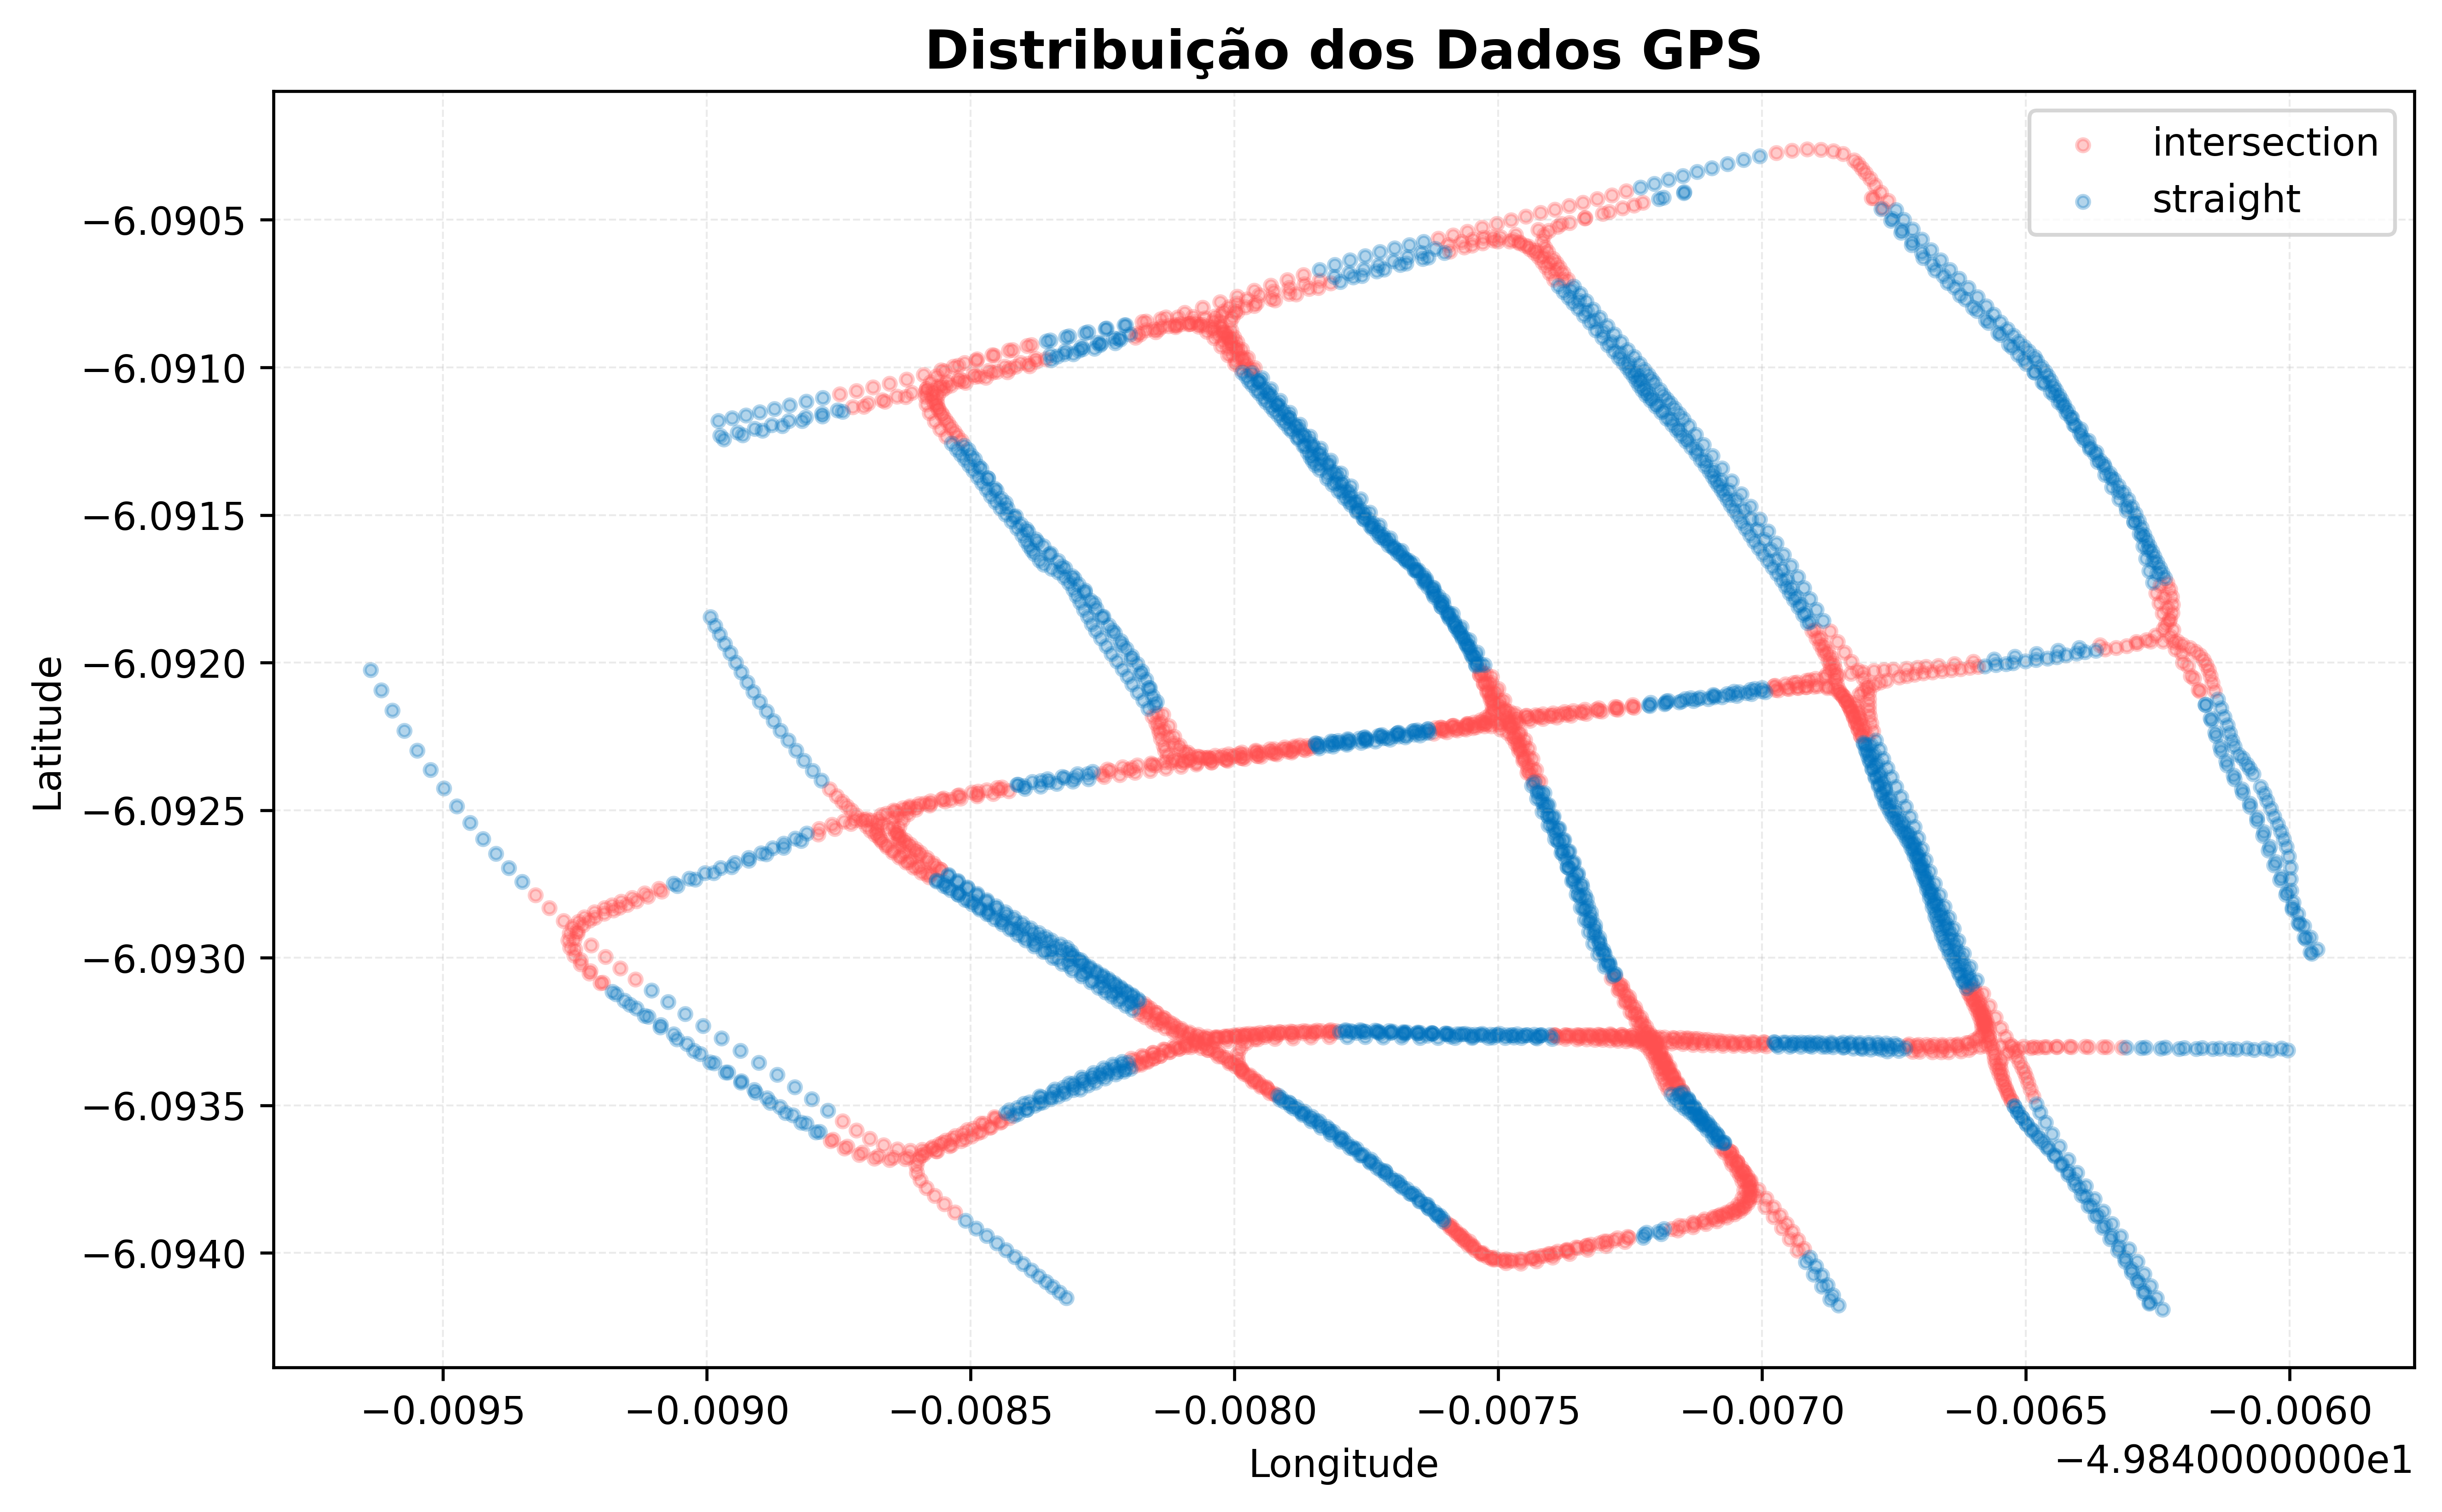

In [8]:
# Define as cores para cada categoria
colors = {"intersection": "#ff5050", "straight": "#0072be"}

# plot dos dados GPS
plt.figure(figsize=(10, 6), dpi=600)
plt.title("Distribuição dos Dados GPS", fontsize=14, fontweight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.25)
for label, color in colors.items():
    subset = dataset_gps[dataset_gps["label"] == label]
    plt.scatter(subset["longitude"], subset["latitude"],
                color=color, label=label, s=10, alpha=0.3)

plt.legend()
plt.show()

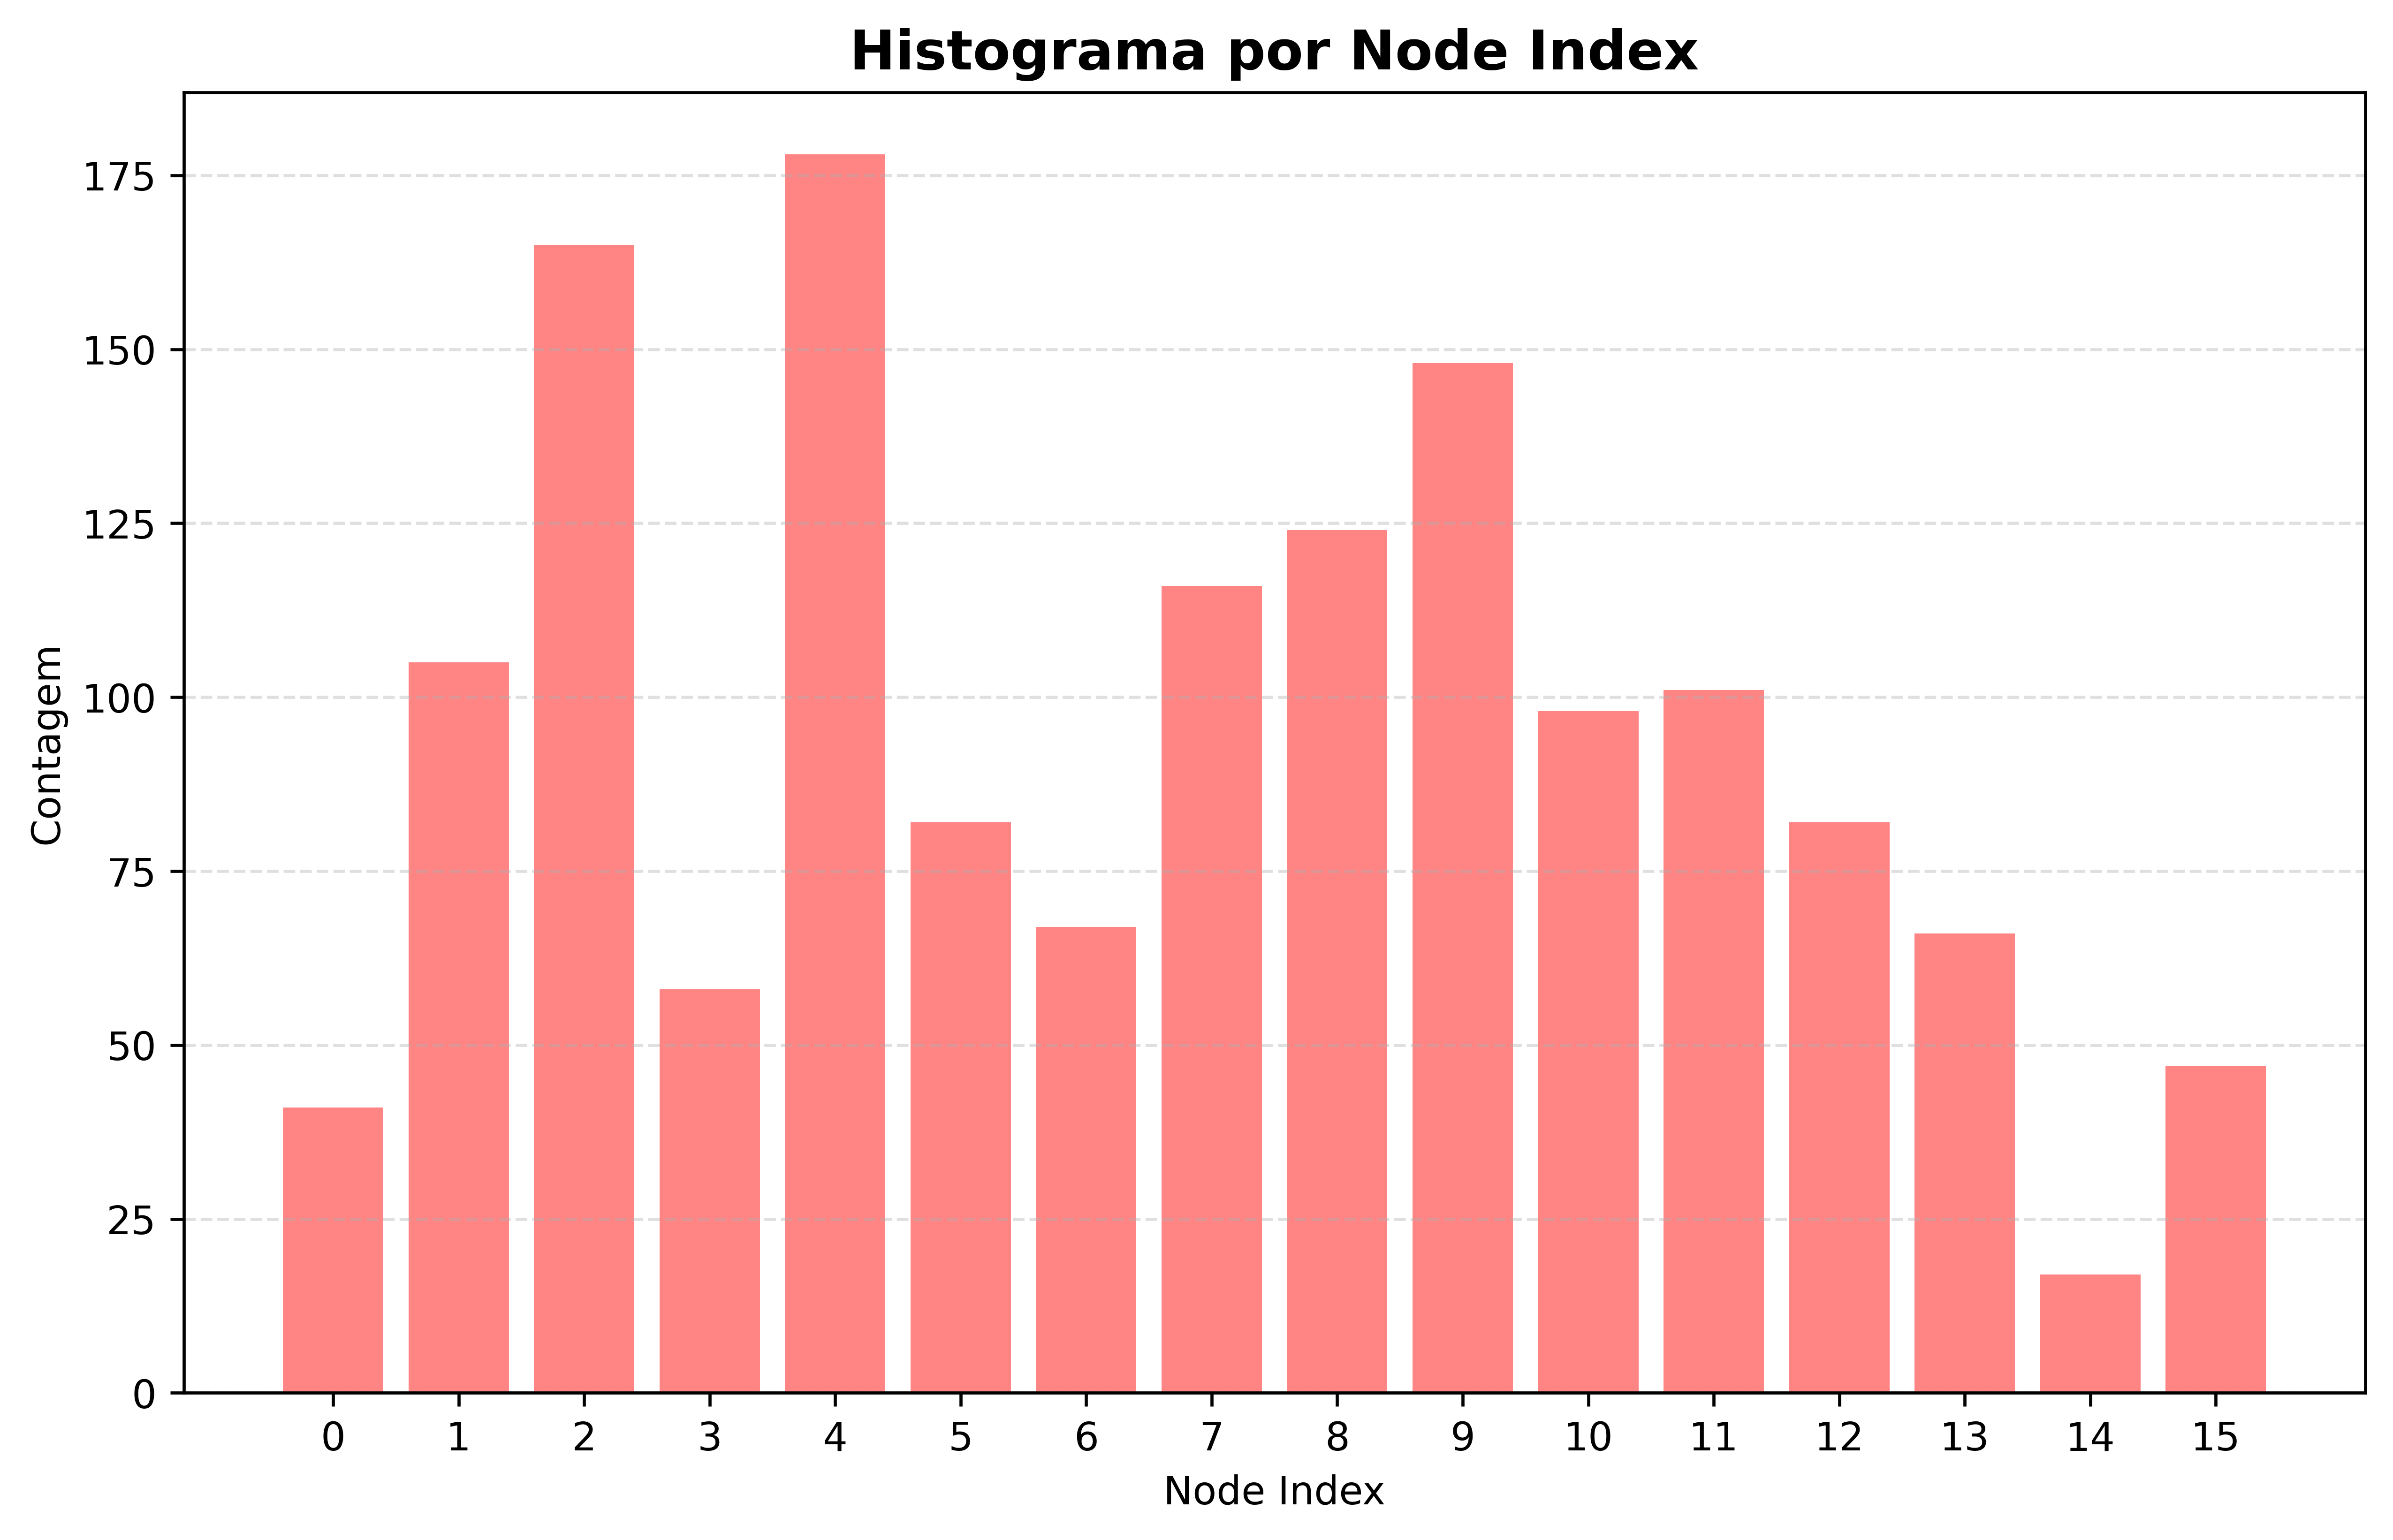

In [9]:
# Contagem por node_index
node_order = list(map(str, range(16)))
node_counts = dataset_gps[dataset_gps["label"]=="intersection"]["node_index"].astype(str).value_counts().reindex(node_order, fill_value=0)

plt.figure(figsize=(10, 6), dpi=600)
plt.bar(node_order, node_counts.values, alpha=0.7, color="#ff5050")
plt.title("Histograma por Node Index", fontsize=14, fontweight='bold')
plt.xlabel("Node Index")
plt.ylabel("Contagem")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

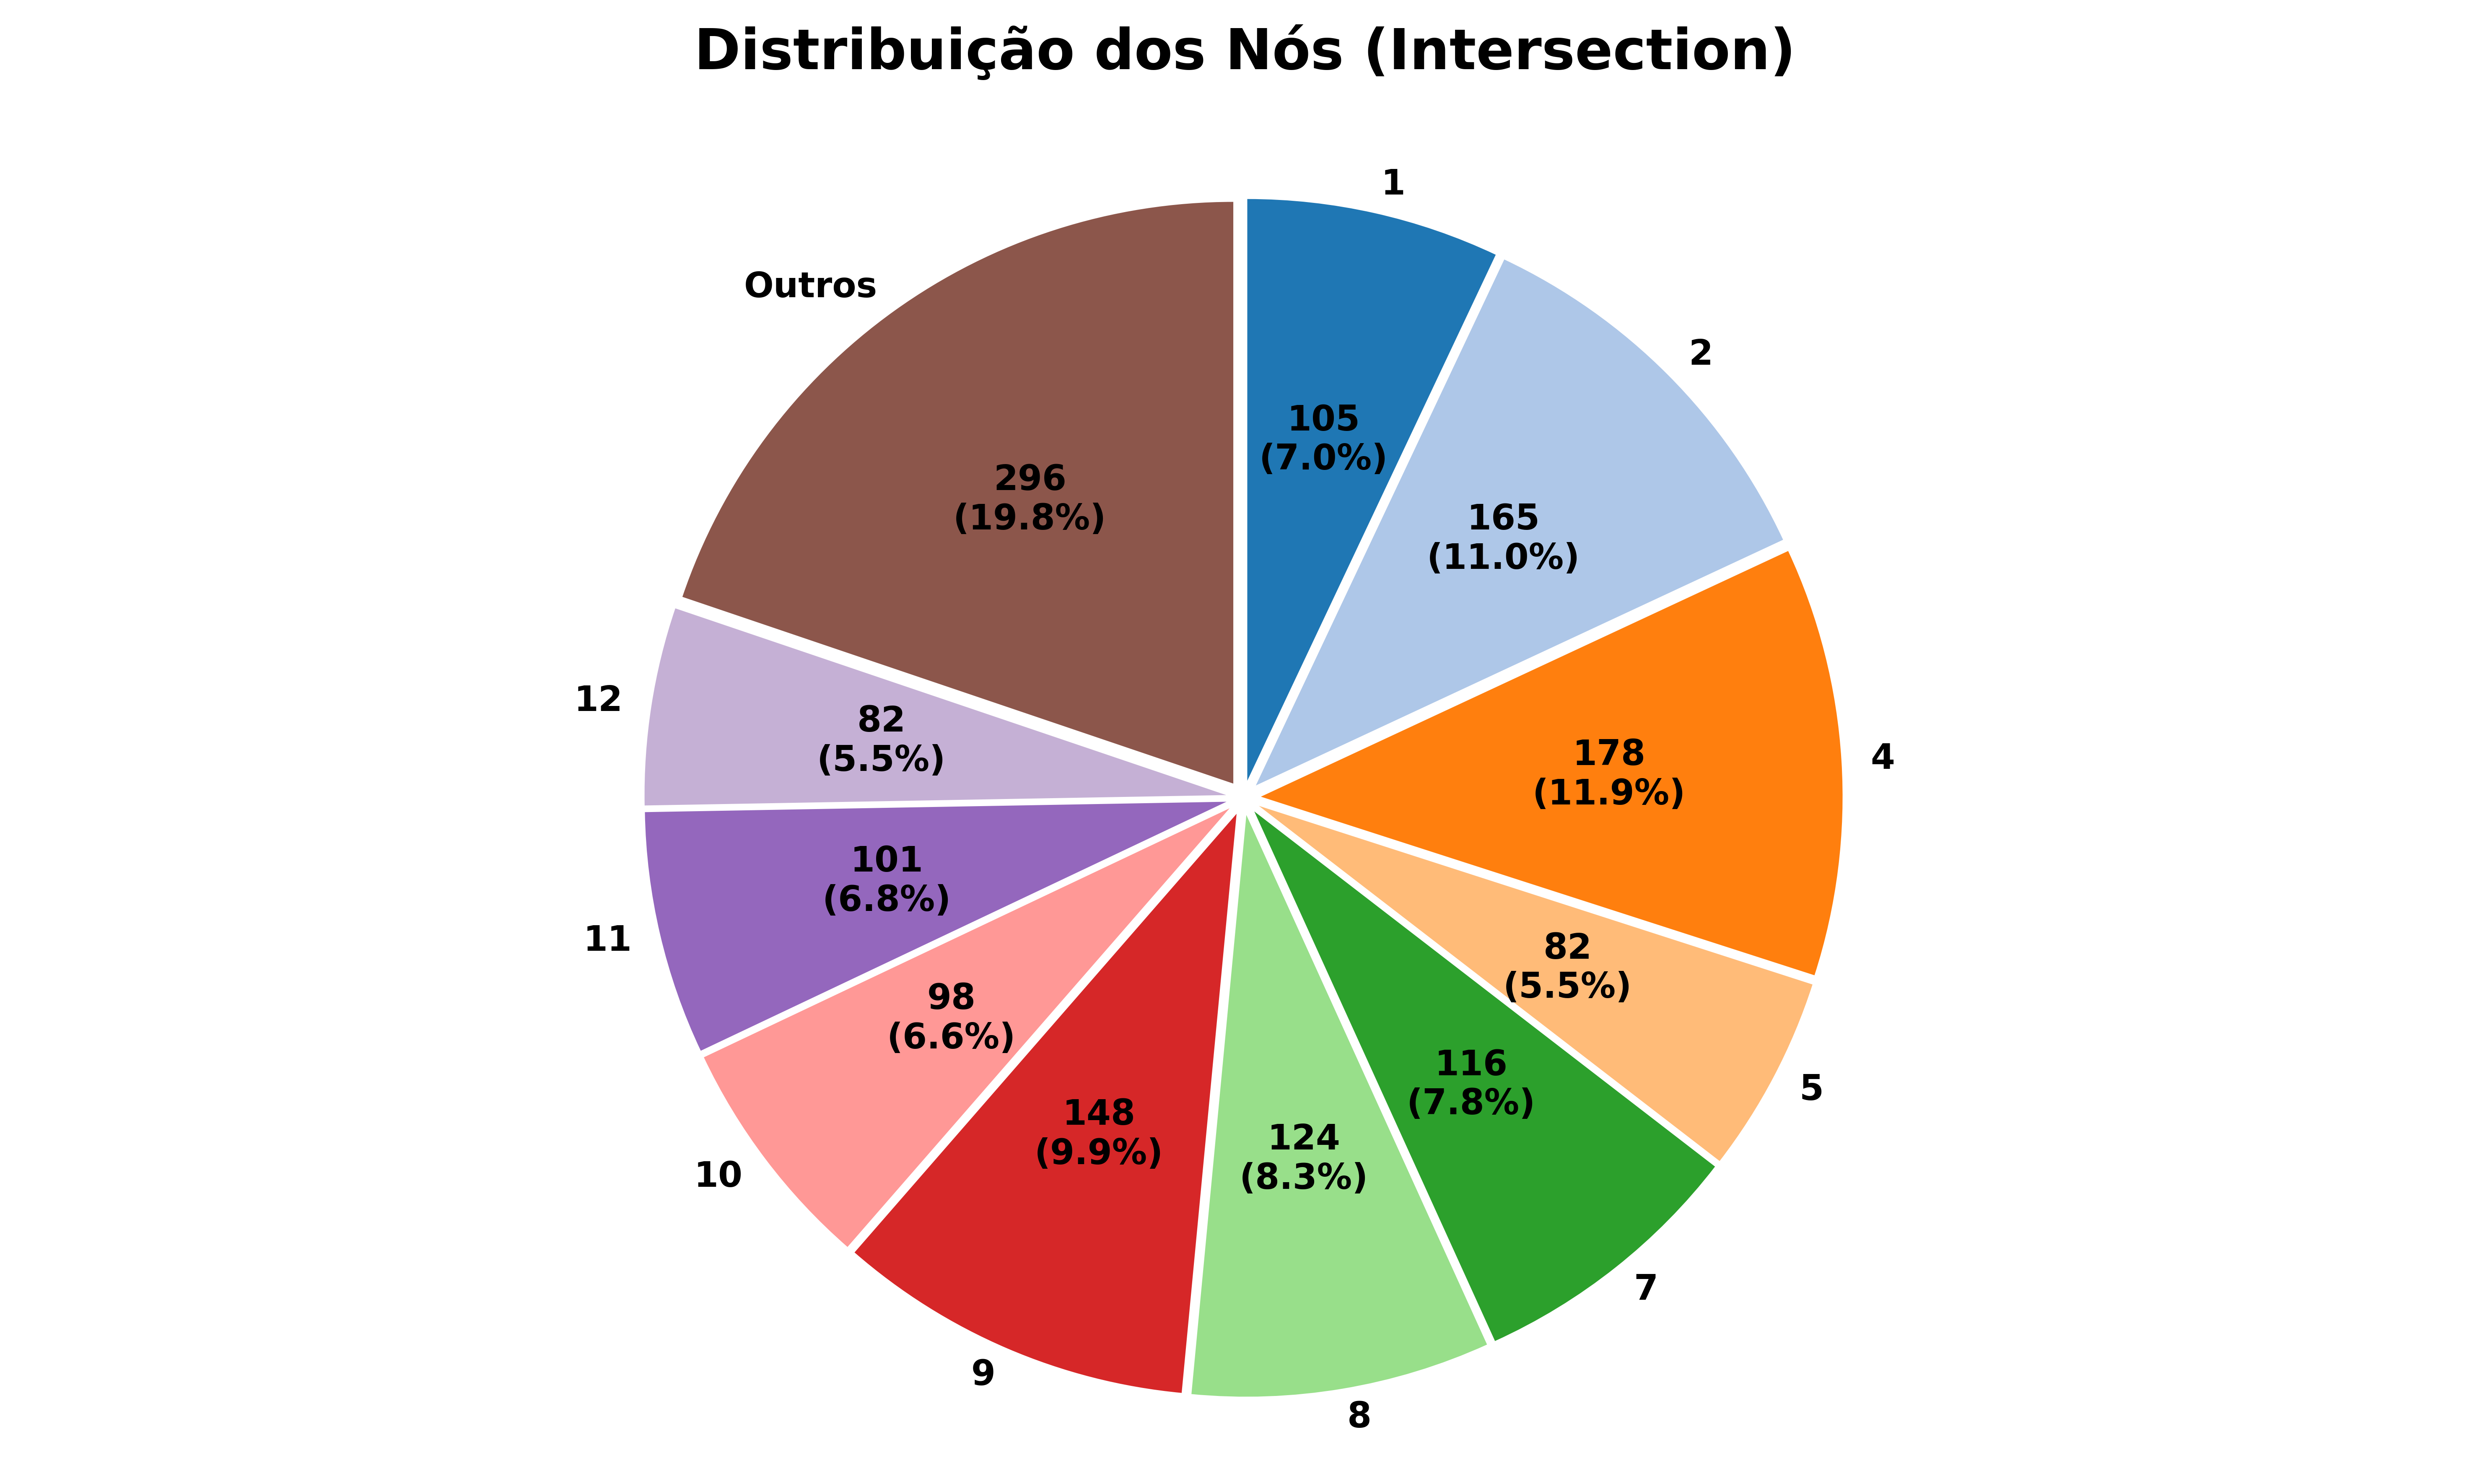

In [11]:
# Contagem de nós e porcentagens
# Converter para DataFrame para facilitar o agrupamento
df_counts = pd.DataFrame({"Node": node_counts.index, "Count": node_counts.values})
df_counts["Perc"] = df_counts["Count"] / df_counts["Count"].sum() * 100

# Separar nós >= 2% e somar os menores
df_major = df_counts[df_counts["Perc"] >= 5]
df_minor = df_counts[df_counts["Perc"] < 5]

if not df_minor.empty:
    outros = pd.DataFrame({
        "Node": ["Outros"],
        "Count": [df_minor["Count"].sum()],
        "Perc": [df_minor["Perc"].sum()]
    })
    df_final = pd.concat([df_major, outros], ignore_index=True)
else:
    df_final = df_major

# Função para contagem + %
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}\n({pct:.1f}%)"
    return my_autopct

# Gráfico
plt.figure(figsize=(10, 6), dpi=600)
plt.pie(
    df_final["Count"],
    labels=df_final["Node"],
    autopct=make_autopct(df_final["Count"]),
    startangle=90,
    counterclock=False,
    colors=plt.cm.tab20.colors,
    explode=[0.03] * len(df_final),
    labeldistance=1.05,
    textprops={'fontsize': 10, 'weight': 'bold'}
)
plt.title("Distribuição dos Nós (Intersection)", fontsize=16, fontweight="bold", pad=20)
plt.axis("equal")
plt.tight_layout()
plt.show()


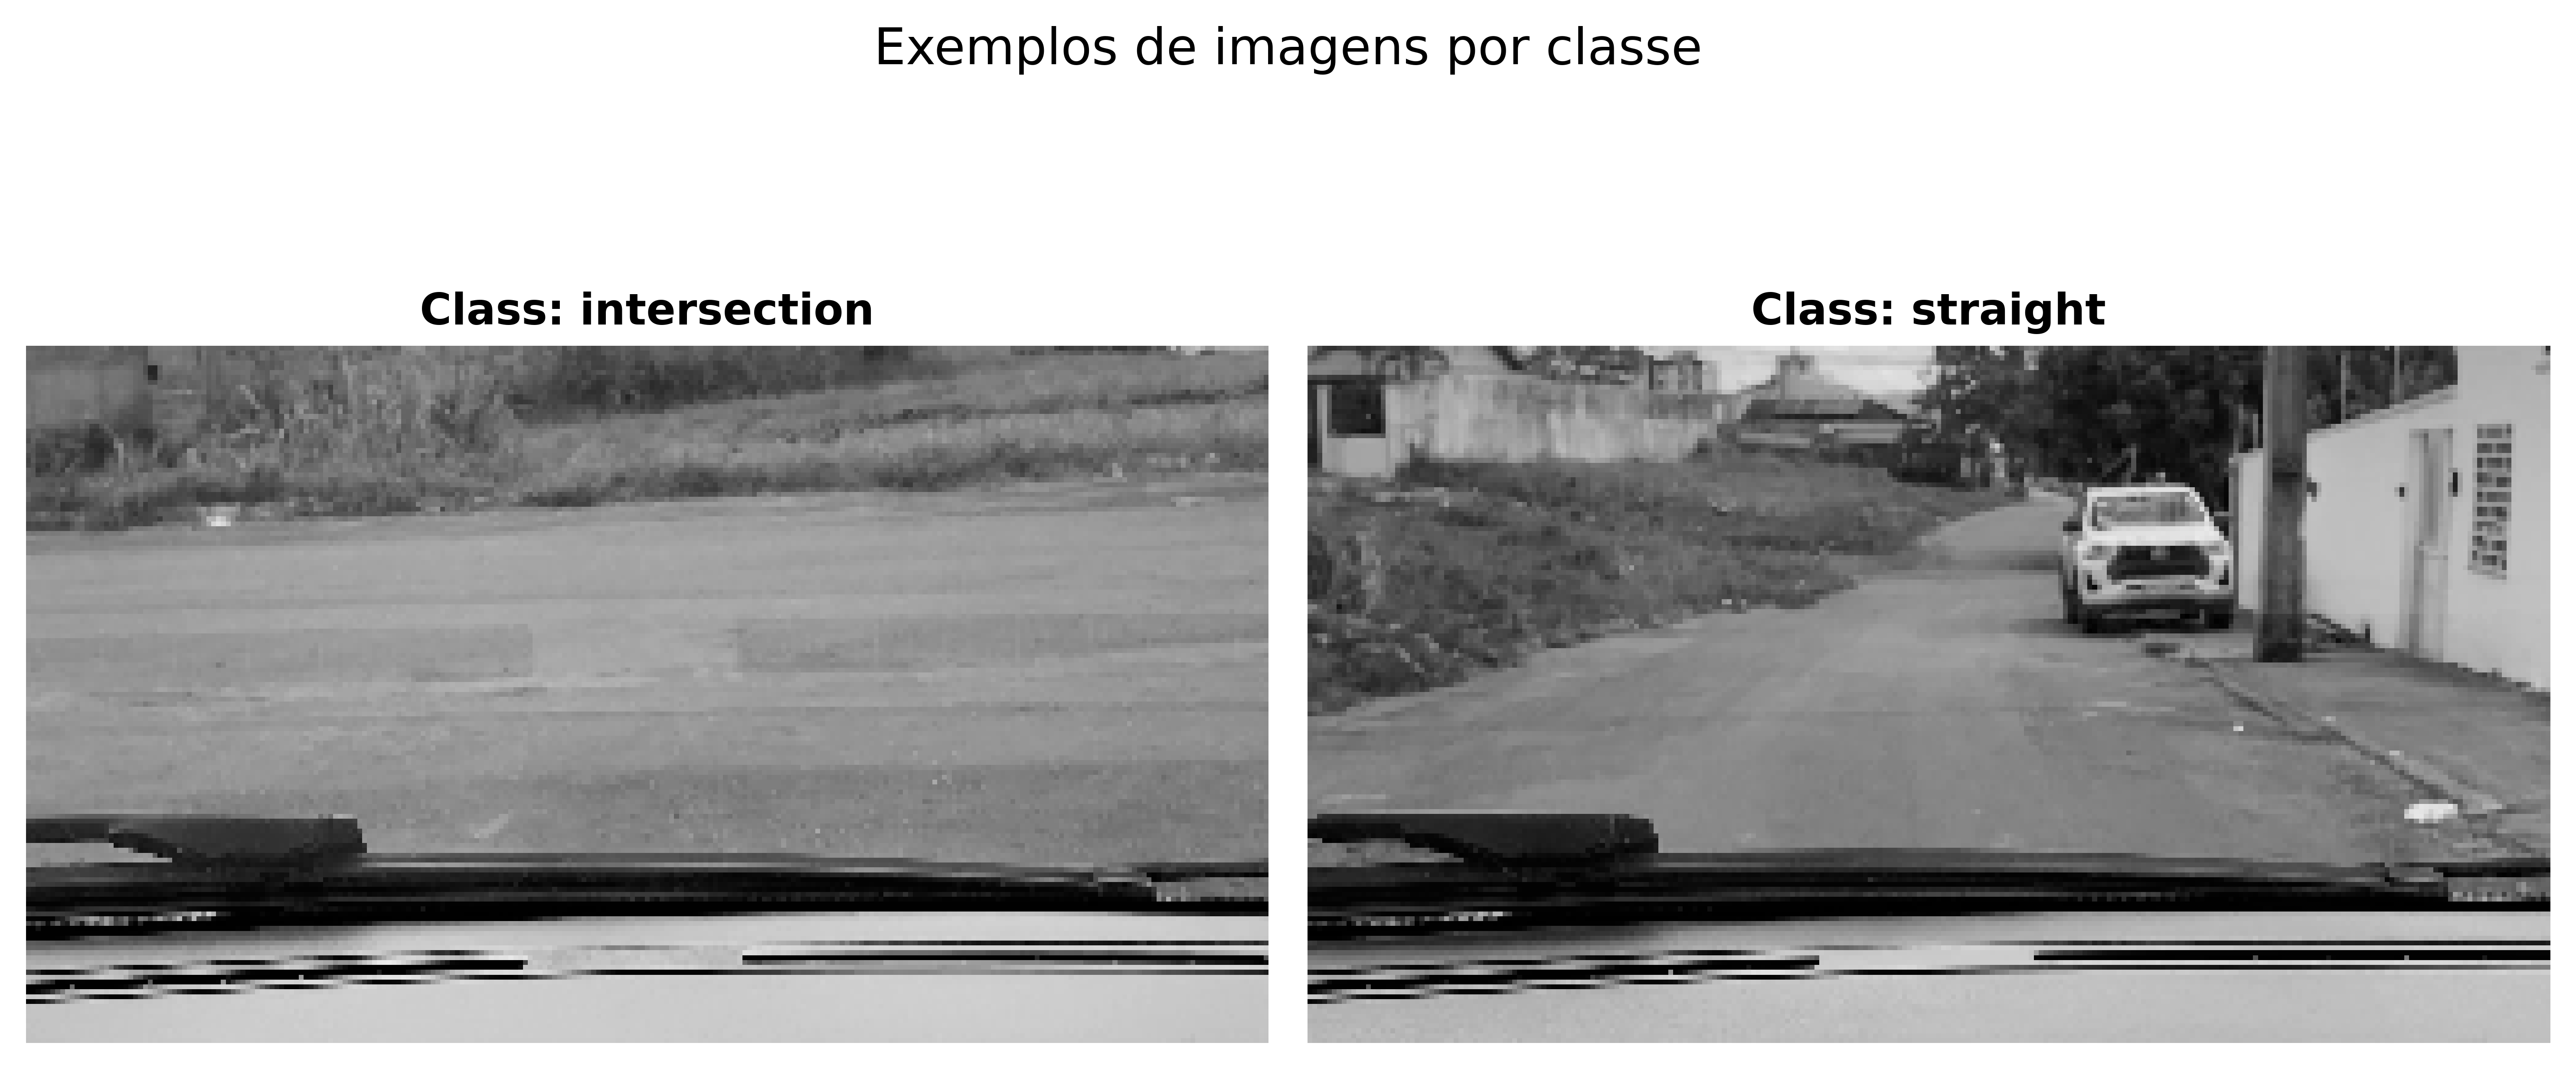

In [12]:
# Filtra um exemplo por classe
sample_intersection = dataset_images[dataset_images["target"] == 1].iloc[0]
sample_straight = dataset_images[dataset_images["target"] == 0].iloc[0]

# Carrega e converte as imagens (BGR → RGB)
img_intersection = cv2.cvtColor(cv2.imread(sample_intersection["filepath"]), cv2.COLOR_BGR2RGB)
img_straight = cv2.cvtColor(cv2.imread(sample_straight["filepath"]), cv2.COLOR_BGR2RGB)

# Plota lado a lado
plt.figure(figsize=(10, 5), dpi=600)

plt.subplot(1, 2, 1)
plt.imshow(img_intersection)
plt.title("Class: intersection", fontsize=12, fontweight="bold")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_straight)
plt.title("Class: straight", fontsize=12, fontweight="bold")
plt.axis("off")

plt.suptitle("Exemplos de imagens por classe", fontsize=14)
plt.tight_layout()
plt.show()


In [13]:
# Exibe shape
print(f"images shape: {img_intersection.shape}")

images shape: (143, 255, 3)


## Dados de treino e de teste

In [14]:
# Cria os vetores de entrada e saída
seed = 42
random.seed(seed); np.random.seed(seed)

X = dataset_images["filepath"].astype(str).values
y = dataset_images["target"].astype(int).values

# Divisao dos dados de treino, validação e teste (70% treino, 15% validação, 15% teste)
x_train, x_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=seed
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed
)

print("Split sizes:", len(x_train), len(x_val), len(x_test))
print("Train dist:", Counter(y_train))
print("Val   dist:", Counter(y_val))
print("Test  dist:", Counter(y_test))

Split sizes: 2192 470 470
Train dist: Counter({0: 1146, 1: 1046})
Val   dist: Counter({0: 245, 1: 225})
Test  dist: Counter({0: 246, 1: 224})


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# reshape das imagens de entrada
img_size = (256, 256)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Transformações de dados
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0), ratio=(1.6, 2.2), interpolation=Image.BILINEAR),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.08),
    transforms.RandomRotation(degrees=5, expand=False),
    # transforms.RandomHorizontalFlip(p=0.0)
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

# eval sem aleatoriedade
eval_tfms = transforms.Compose([
    transforms.Resize(img_size, interpolation=Image.BILINEAR),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


# Caminho completo das imagens
train_pairs = list(zip(x_train, y_train))
val_pairs   = list(zip(x_val,   y_val))
test_pairs  = list(zip(x_test,  y_test))

# Funcao de leitura das imagens
def load_image_tensor(img_path, transform):
    """Lê arquivo de imagem com OpenCV, converte para RGB e aplica transform."""
    img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Imagem não encontrada: {img_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    if transform is not None:
        return transform(pil_img)
    return transforms.ToTensor()(pil_img)

# Load de iamgens do batch
def collate_from_paths(batch, transform):
    """
    batch: lista de tuplas (path, label)
    Retorna: (tensor_imgs[B,3,H,W], tensor_labels[B])
    """
    imgs, labels = [], []
    for path, label in batch:
        imgs.append(load_image_tensor(path, transform))
        labels.append(int(label))
    imgs = torch.stack(imgs, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)
    return imgs, labels

# DataLoaders
batch_size = 16

train_loader = DataLoader(
    train_pairs, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True,
    collate_fn=lambda b: collate_from_paths(b, train_tfms)
)
val_loader = DataLoader(
    val_pairs, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True,
    collate_fn=lambda b: collate_from_paths(b, eval_tfms)
)
test_loader = DataLoader(
    test_pairs, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True,
    collate_fn=lambda b: collate_from_paths(b, eval_tfms)
)

# MobileNetV3‑Small 

## Construção do modelo

In [16]:
# opção 1: focal loss para focar em exemplos difíceis
def focal_loss(logits, targets, gamma=2.0, alpha=0.75):
    ce = F.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce)
    loss = alpha * ((1 - pt) ** gamma) * ce
    return loss.mean()

# opção 2: mixup leve (use em vez da focal loss)
def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, None
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, (y_a, y_b), lam

In [17]:
# carrega o modelo MobileNetV3
try:
    mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
except Exception as e:
    print("Aviso: não foi possível carregar pesos pré-treinados. Usando pesos aleatórios.", str(e))
    mobilenet = models.mobilenet_v3_small(weights=None)

# substituição da última camada para 2 classes
in_features = mobilenet.classifier[-1].in_features
mobilenet.classifier[-1] = nn.Linear(in_features, 2)
mobilenet = mobilenet.to(device)

## Treinamento

In [18]:
# Função de avaliação
criterion_ce = nn.CrossEntropyLoss()

@torch.no_grad()
def run_eval(model, data_loader, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for imgs, labels in data_loader:
        imgs  = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(imgs)
        loss   = criterion_ce(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(data_loader.dataset)
    from sklearn.metrics import accuracy_score, f1_score
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="binary", pos_label=1)
    return avg_loss, acc, f1, all_preds, all_labels

In [19]:
# Treinamento do modelo MobileNetV3
# configuração do otimizador e do scheduler (warmup + cosine)
base_lr = 3e-4
min_lr  = 1e-5
total_epochs  = 40
warmup_epochs = 3

def get_lr(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs * base_lr
    t = (epoch - warmup_epochs) / max(1, (total_epochs - warmup_epochs))
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * t))

optimizer = torch.optim.AdamW(mobilenet.parameters(), lr=base_lr, weight_decay=1e-4)

# treinamento do modelo MobileNetV3 com early stopping e restore
epochs      = total_epochs 
patience    = 6
min_delta   = 0.0
model_path  = "src/Models/mobilenet_best.pth"

best_val_loss  = math.inf
best_epoch     = 0
trigger_times  = 0

use_focal = True          # True = usar Focal Loss; False = usar MixUp + CE
mixup_alpha = 0.2         # usado apenas se use_focal=False

# histórico para plot
hist_epochs_m, hist_train_loss_m, hist_val_loss_m, hist_val_acc_m, hist_val_f1_m = [], [], [], [], []

for epoch in range(1, epochs + 1):
    mobilenet.train()
    # atualiza LR manualmente (warmup + cosine)
    for g in optimizer.param_groups:
        g['lr'] = get_lr(epoch-1)

    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_focal:
            logits = mobilenet(imgs)
            loss   = focal_loss(logits, labels, gamma=2.0, alpha=0.75)
        else:
            imgs_m, y_mix, lam = mixup_batch(imgs, labels, alpha=mixup_alpha)
            logits = mobilenet(imgs_m)
            ya, yb = y_mix
            loss = lam * F.cross_entropy(logits, ya) + (1 - lam) * F.cross_entropy(logits, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    train_loss_m = running_loss / len(train_loader.dataset)

    val_loss_m, val_acc_m, val_f1_m, _, _ = run_eval(mobilenet, val_loader, device)
    print(f"[MobileNet][Epoch {epoch:02d}] lr={optimizer.param_groups[0]['lr']:.6f} | "
          f"train_loss={train_loss_m:.4f} | val_loss={val_loss_m:.4f} | val_acc={val_acc_m:.4f} | val_f1={val_f1_m:.4f}")

    if val_loss_m < (best_val_loss - min_delta):
        best_val_loss = val_loss_m
        best_epoch    = epoch
        trigger_times = 0
        torch.save(mobilenet.state_dict(), model_path)
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping ativado na epoch {epoch:02d} (sem melhora por {patience} épocas).")
            break
    # acumula histórico
    hist_epochs_m.append(epoch)
    hist_train_loss_m.append(train_loss_m)
    hist_val_loss_m.append(val_loss_m)
    hist_val_acc_m.append(val_acc_m)
    hist_val_f1_m.append(val_f1_m)

# restaura o melhor estado salvo
if torch.cuda.is_available():
    mobilenet.load_state_dict(torch.load(model_path))
else:
    mobilenet.load_state_dict(torch.load(model_path, map_location="cpu"))

print(f"Melhor modelo restaurado da epoch {best_epoch:02d} com val_loss={best_val_loss:.4f}.")

[MobileNet][Epoch 01] lr=0.000100 | train_loss=0.1159 | val_loss=0.6468 | val_acc=0.5596 | val_f1=0.6656
[MobileNet][Epoch 02] lr=0.000200 | train_loss=0.0906 | val_loss=0.5849 | val_acc=0.6830 | val_f1=0.7225
[MobileNet][Epoch 03] lr=0.000300 | train_loss=0.0803 | val_loss=0.5188 | val_acc=0.7851 | val_f1=0.7856
[MobileNet][Epoch 04] lr=0.000300 | train_loss=0.0610 | val_loss=0.4571 | val_acc=0.8170 | val_f1=0.8352
[MobileNet][Epoch 05] lr=0.000299 | train_loss=0.0517 | val_loss=0.3684 | val_acc=0.8809 | val_f1=0.8843
[MobileNet][Epoch 06] lr=0.000298 | train_loss=0.0479 | val_loss=0.3127 | val_acc=0.8553 | val_f1=0.8341
[MobileNet][Epoch 07] lr=0.000295 | train_loss=0.0374 | val_loss=0.2851 | val_acc=0.9170 | val_f1=0.9154
[MobileNet][Epoch 08] lr=0.000292 | train_loss=0.0356 | val_loss=0.2729 | val_acc=0.9085 | val_f1=0.9007
[MobileNet][Epoch 09] lr=0.000287 | train_loss=0.0300 | val_loss=0.3543 | val_acc=0.8766 | val_f1=0.8845
[MobileNet][Epoch 10] lr=0.000282 | train_loss=0.0238 |

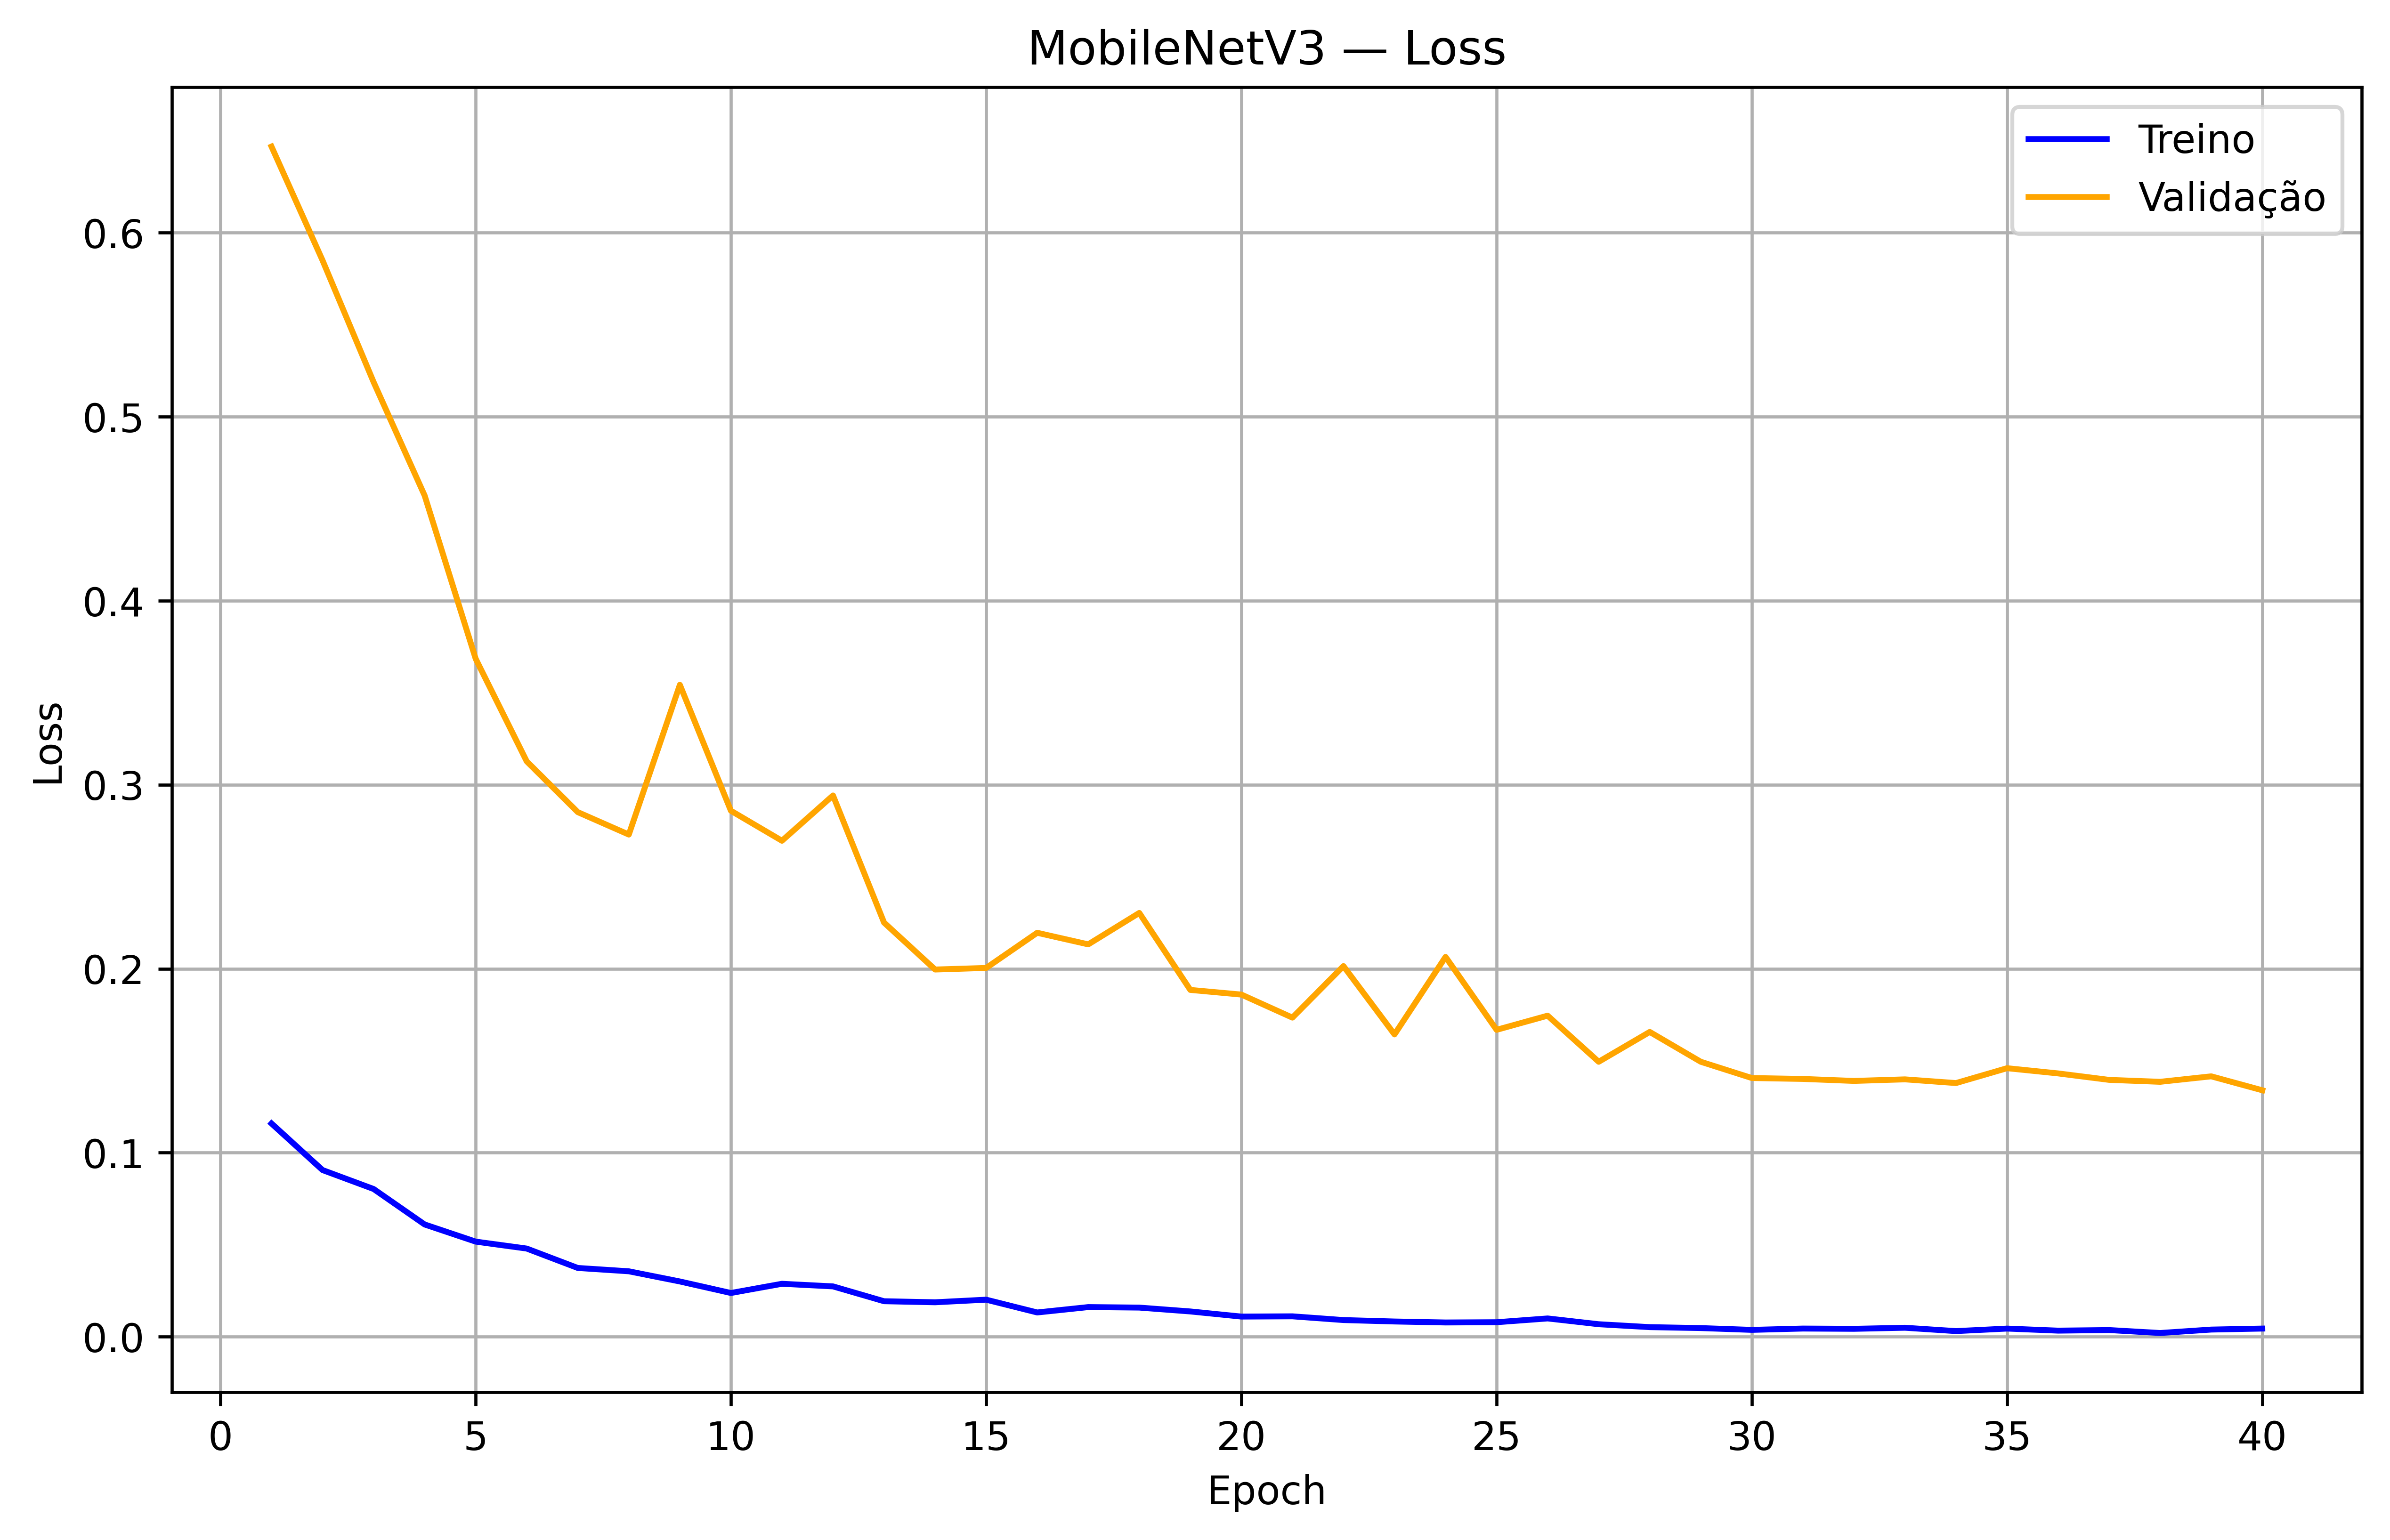

In [20]:
# Plot Loss treino vs validação
plt.figure(figsize=(10,6), dpi=600)
plt.plot(hist_epochs_m, hist_train_loss_m, label="Treino", color="blue")
plt.plot(hist_epochs_m, hist_val_loss_m, label="Validação", color="orange")
plt.title("MobileNetV3 — Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True); plt.legend(); plt.show()

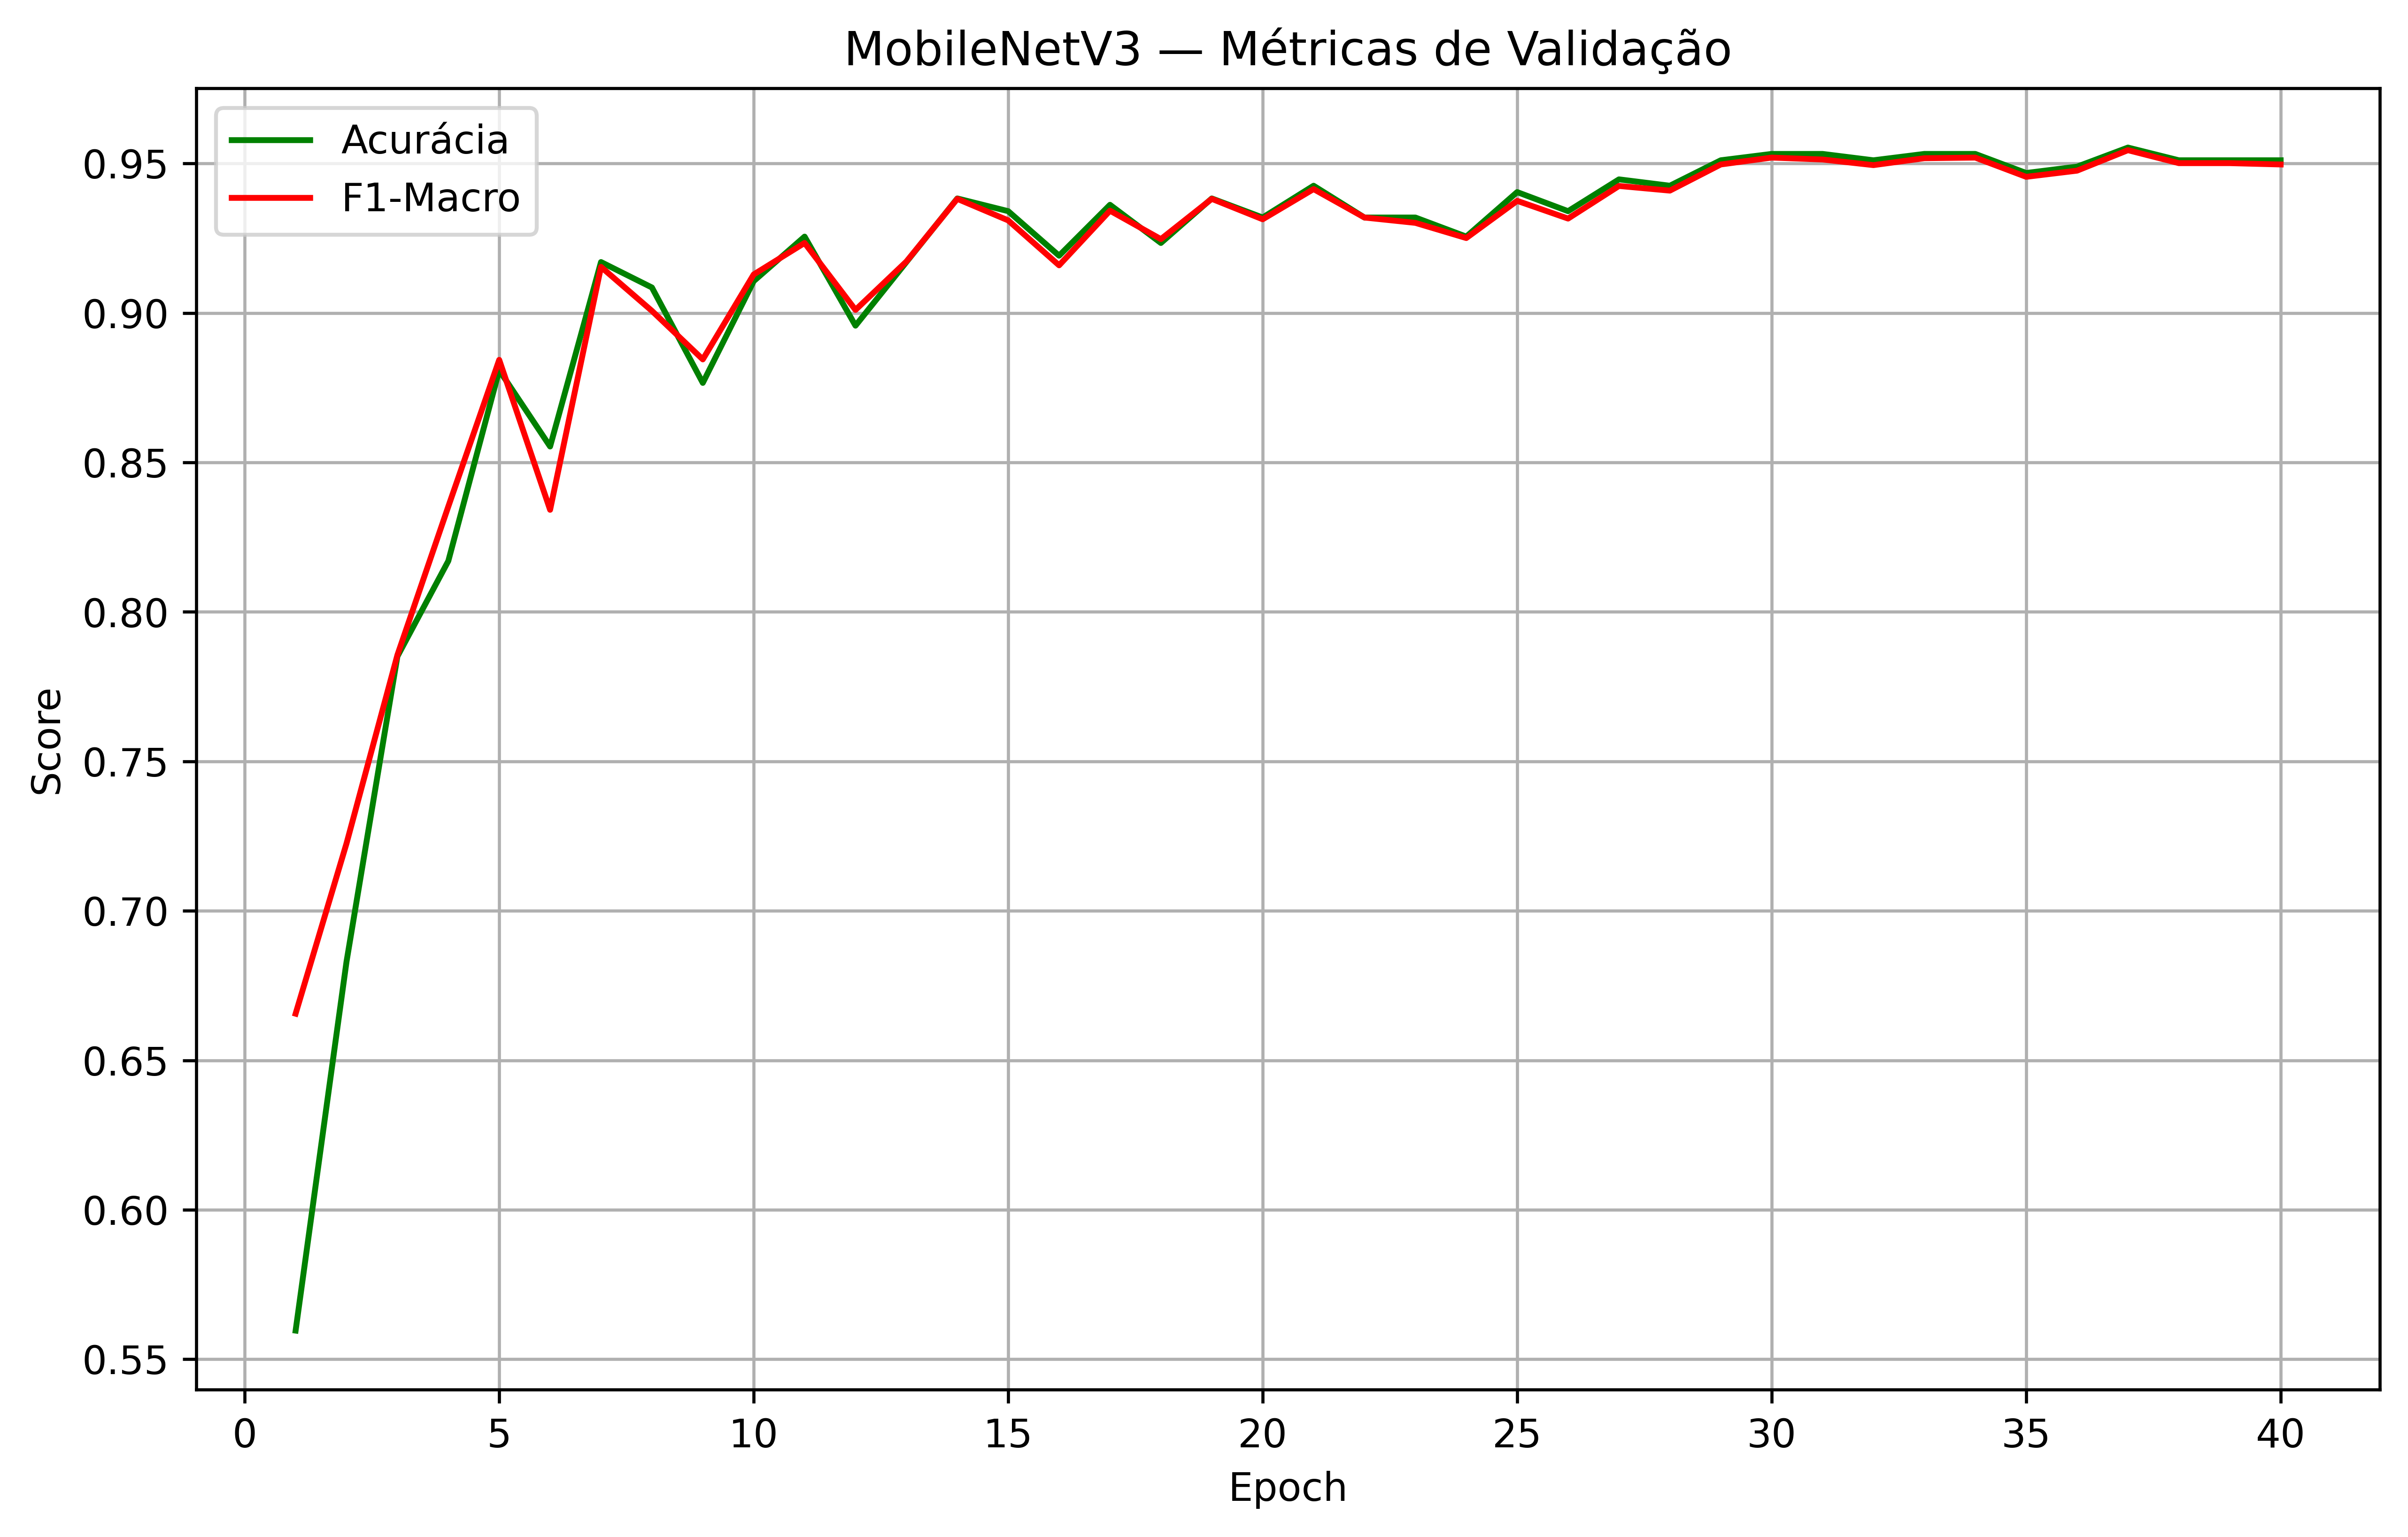

In [21]:
# Plot Métricas accuracy vs F1
plt.figure(figsize=(10,6), dpi=600)
plt.plot(hist_epochs_m, hist_val_acc_m, label="Acurácia", color="green")
plt.plot(hist_epochs_m, hist_val_f1_m, label="F1-Macro", color="red")
plt.title("MobileNetV3 — Métricas de Validação")
plt.xlabel("Epoch"); plt.ylabel("Score")
plt.grid(True); plt.legend(); plt.show()

## Teste

### Funções

In [22]:
# Utilização de GPU (%)
pynvml.nvmlInit()
_NVML_READY = False

In [23]:
# Funções de avaliação final
@torch.no_grad()
def eval_classification(model, data_loader, device, criterion=None):
    """
    Avalia classificação (loss, acc, F1) e retorna y_true/y_pred.
    """
    model.eval()
    all_logits = []
    all_targets = []
    running_loss = 0.0
    n_samples = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        if criterion is not None:
            loss = criterion(logits, targets)
            running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        all_logits.append(preds.detach().cpu())
        all_targets.append(targets.detach().cpu())
        n_samples += images.size(0)

    y_pred = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_targets).numpy()

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    avg_loss = (running_loss / n_samples) if (criterion is not None and n_samples > 0) else float("nan")
    return avg_loss, acc, f1m, y_pred, y_true

In [24]:
# Função de medição de desempenho (FPS e recursos)
@torch.no_grad()
def measure_perf(model, data_loader, device, warmup_batches=3, sample_interval=5, max_batches=None):
    """
    Mede eficiência computacional durante INFERÊNCIA:
    - FPS médio (frames/segundo)
    - Uso médio de CPU (%), RAM (MB), GPU-Util (%) [se NVML], GPU-Mem (MB)
    """
    model.eval()

    # Info de processo para CPU/RAM (se disponível)
    proc = psutil.Process(os.getpid()) if psutil is not None else None

    # Seleciona GPU handle (se NVML disponível)
    gpu_handle = None
    if _NVML_READY and torch.cuda.is_available():
        try:
            gpu_index = torch.cuda.current_device()
            gpu_handle = pynvml.nvmlDeviceGetHandleByIndex(gpu_index)
        except Exception:
            gpu_handle = None

    # Warmup
    wb = 0
    for images, _ in data_loader:
        images = images.to(device, non_blocking=True)
        _ = model(images)
        wb += 1
        if wb >= warmup_batches:
            break

    # Medições
    start_time = time.perf_counter()
    n_frames = 0

    cpu_samples = []
    ram_samples_mb = []
    gpu_util_samples = []
    gpu_mem_samples_mb = []

    batch_idx = 0
    for images, _ in data_loader:
        images = images.to(device, non_blocking=True)

        # Inferência cronometrada
        _ = model(images)
        torch.cuda.synchronize(device) if device.type == "cuda" else None

        n_frames += images.size(0)

        # Amostragem em intervalos de batch para reduzir overhead
        if (batch_idx % sample_interval) == 0:
            # CPU e RAM
            if proc is not None:
                try:
                    cpu_samples.append(proc.cpu_percent(interval=None))  # % desde última chamada
                    ram_samples_mb.append(proc.memory_info().rss / (1024**2))
                except Exception:
                    pass

            # GPU util e memória alocada
            if torch.cuda.is_available():
                try:
                    # Memórias via PyTorch
                    mem_alloc_mb = torch.cuda.memory_allocated(device) / (1024**2)
                    gpu_mem_samples_mb.append(mem_alloc_mb)
                except Exception:
                    pass

            if gpu_handle is not None:
                try:
                    util = pynvml.nvmlDeviceGetUtilizationRates(gpu_handle)
                    gpu_util_samples.append(util.gpu)  # em %
                except Exception:
                    pass

        batch_idx += 1
        if max_batches is not None and batch_idx >= max_batches:
            break

    total_time = time.perf_counter() - start_time
    fps = (n_frames / total_time) if total_time > 0 else 0.0

    # Médias seguras
    def _safe_mean(x): 
        return float(np.mean(x)) if len(x) > 0 else float("nan")

    metrics = {
        "fps_mean": fps,
        "cpu_percent_mean": _safe_mean(cpu_samples),            # %
        "ram_mb_mean": _safe_mean(ram_samples_mb),             # MB
        "gpu_util_percent_mean": _safe_mean(gpu_util_samples), # % (se disponível)
        "gpu_mem_mb_mean": _safe_mean(gpu_mem_samples_mb),     # MB
        "frames_counted": n_frames,
        "time_seconds": total_time
    }
    return metrics

In [25]:
# Função de plot da matriz de confusão
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    """Plota matriz de confusão; se normalize=True, mostra porcentagens por linha."""
    import matplotlib.pyplot as plt
    if normalize:
        with np.errstate(all='ignore'):
            cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)

    fig, ax = plt.subplots(figsize=(6.7, 4), dpi=600)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proporção" if normalize else "Contagem", rotation=-90, va="bottom")

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)

    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=0, fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)

    fmt = ".1%" if normalize else "d"
    thresh = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = format(cm[i, j], fmt)
            ax.text(j, i, value,
                    ha="center", va="center",
                    fontsize=11,
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mobilenet.to(device)  # MUITO importante

torch.backends.cudnn.benchmark = True  # ajuda performance se input size fixo

@torch.no_grad()
def sanity_cuda_forward(model, device, shape=(1,3,255,255)):
    model.eval()
    x = torch.randn(*shape, device=device)
    torch.cuda.synchronize() if device.type == "cuda" else None
    t0 = time.perf_counter()
    _ = model(x)
    torch.cuda.synchronize() if device.type == "cuda" else None
    dt = time.perf_counter() - t0
    print(f"[Sanity] forward {shape} on {device}: {dt*1000:.2f} ms")

sanity_cuda_forward(mobilenet, device)


[Sanity] forward (1, 3, 255, 255) on cuda: 113.11 ms


In [27]:
# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mobilenet.to(device)

torch.backends.cudnn.benchmark = True  # ajuda performance se input size fixo

@torch.no_grad()
def sanity_cuda_forward(model, device, shape=(1,3,255,255)):
    model.eval()
    x = torch.randn(*shape, device=device)
    torch.cuda.synchronize() if device.type == "cuda" else None
    t0 = time.perf_counter()
    _ = model(x)
    torch.cuda.synchronize() if device.type == "cuda" else None
    dt = time.perf_counter() - t0
    print(f"[Sanity] forward {shape} on {device}: {dt*1000:.2f} ms")

sanity_cuda_forward(mobilenet, device)


[Sanity] forward (1, 3, 255, 255) on cuda: 3.79 ms


In [28]:
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
    print("cuda:", torch.version.cuda, "| cudnn:", torch.backends.cudnn.version())


torch: 2.5.1+cu121
cuda available: True
device: NVIDIA GeForce RTX 3060 Laptop GPU
cuda: 12.1 | cudnn: 90100


### Clasificação

In [29]:
# Execução da avaliação 
criterion = nn.CrossEntropyLoss()

test_loss_m, test_acc_m, test_f1_m, y_pred_m, y_true_m = eval_classification(
    mobilenet, test_loader, device, criterion
)
print(f"[MobileNetV3-Small BEST] test_loss={test_loss_m:.4f} | test_acc={test_acc_m:.4f} | test_f1={test_f1_m:.4f}")

[MobileNetV3-Small BEST] test_loss=0.1284 | test_acc=0.9574 | test_f1=0.9573


### Matriz de confusão

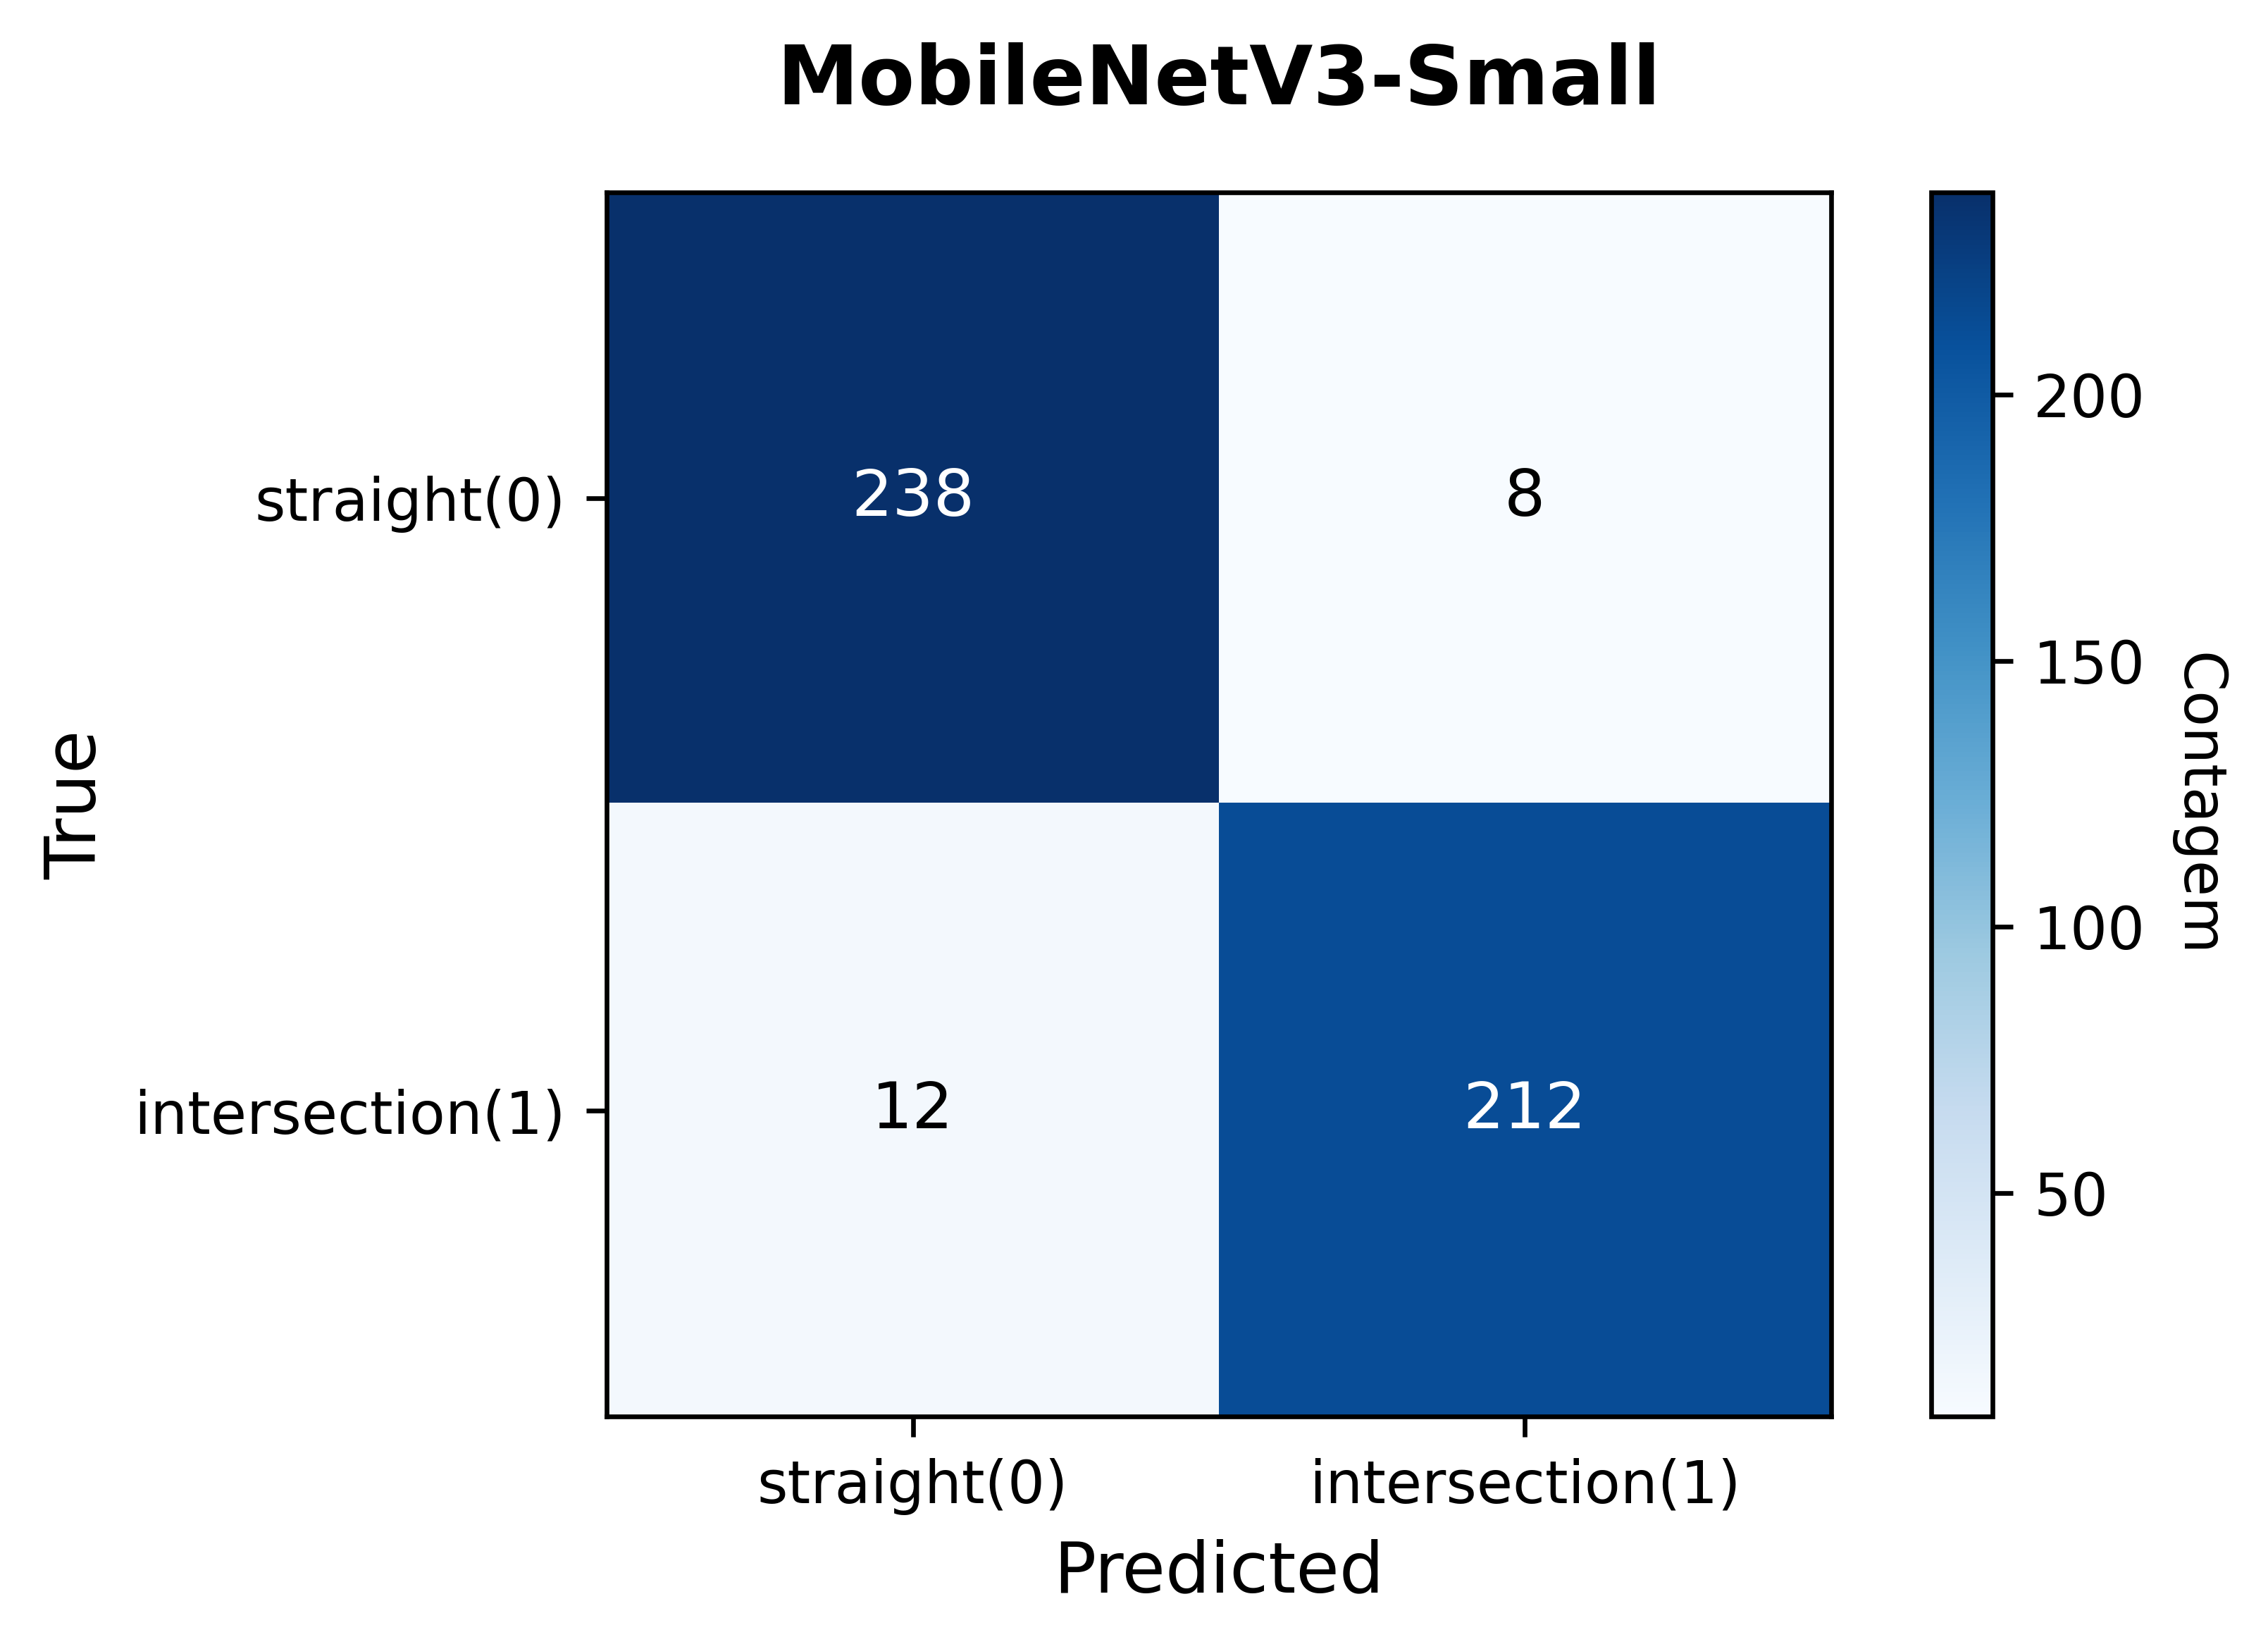

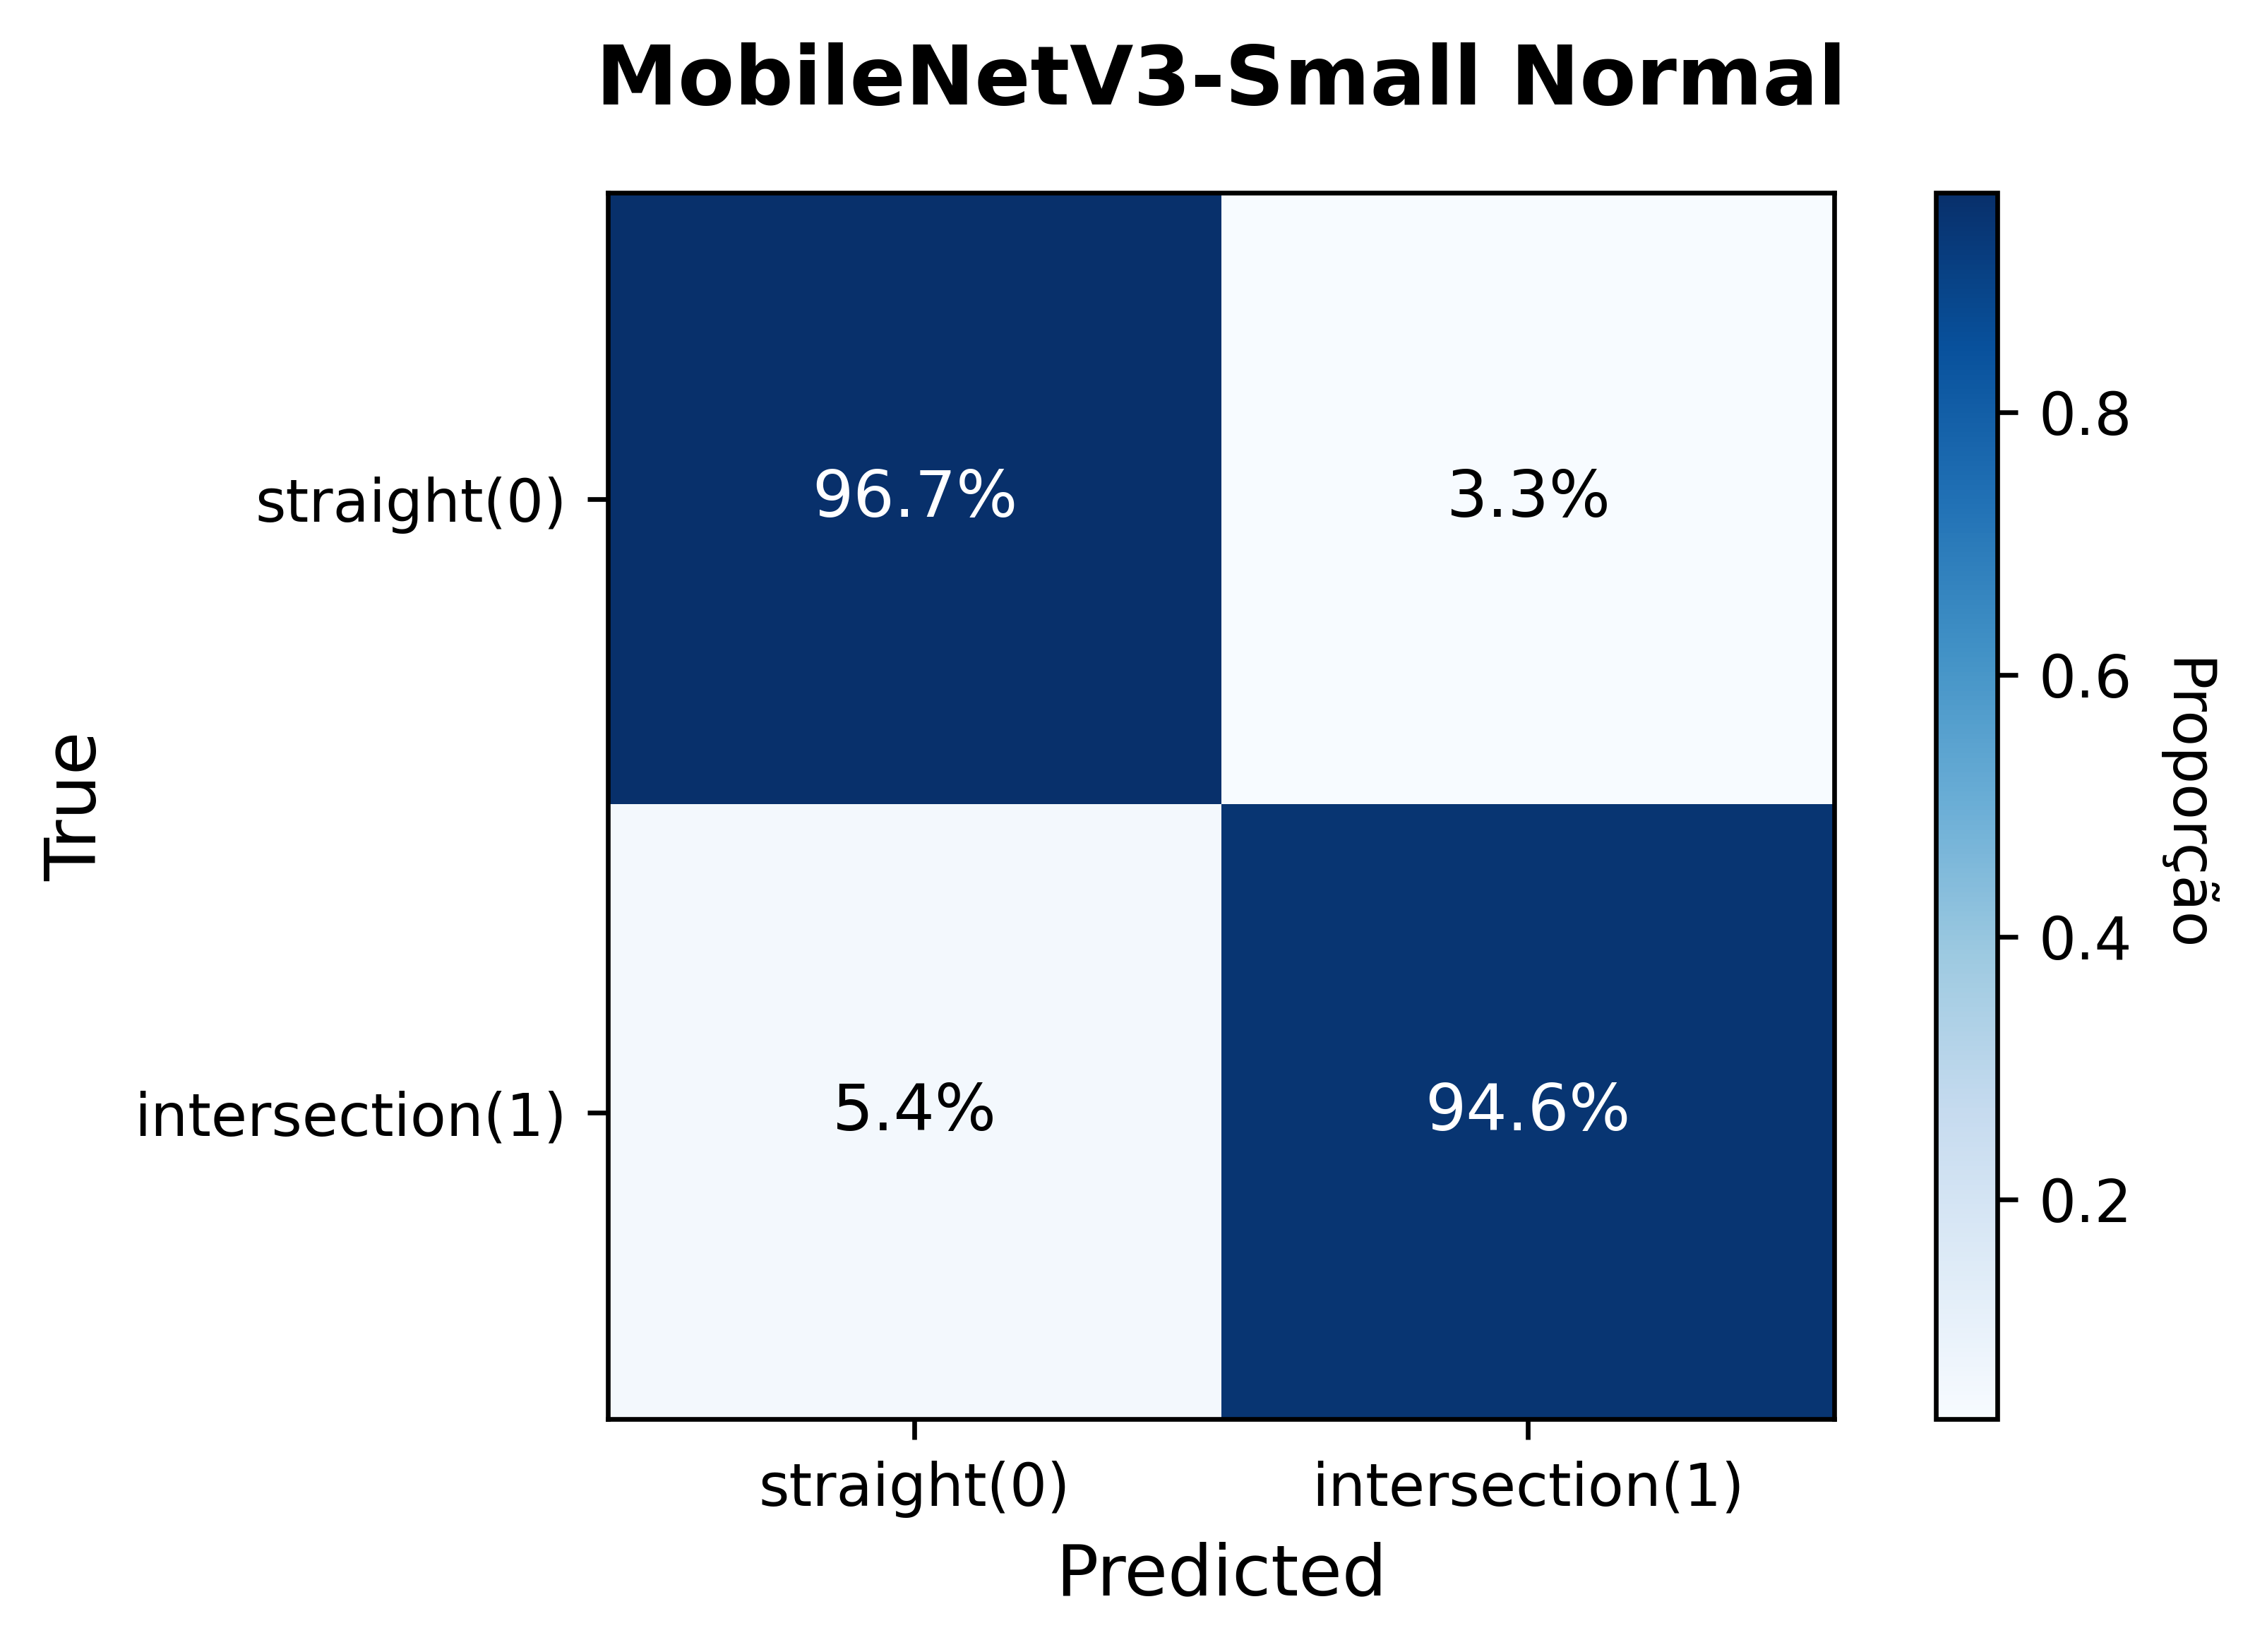

In [30]:
# Matriz de confusão
class_names = ["straight(0)", "intersection(1)"]
cm_m = confusion_matrix(y_true_m, y_pred_m, labels=[0, 1])

plot_confusion_matrix(cm_m, class_names, title="MobileNetV3-Small", normalize=False)
plot_confusion_matrix(cm_m, class_names, title="MobileNetV3-Small Normal", normalize=True)

### FPS e recursos

In [31]:
# Métricas de eficiência computacional
perf_m = measure_perf(
    mobilenet, test_loader, device,
    warmup_batches=3,     # pequeno aquecimento
    sample_interval=5,    # amostrar recursos a cada 5 batches
    max_batches=None      # ou limite ex.: 200, se desejar reduzir tempo
)

# Impressão consolidada
print("\n=== Eficiência Computacional (MobileNetV3-Small) ===")
print(f"FPS médio:                 {perf_m['fps_mean']:.2f}")
print(f"CPU média (%):             {perf_m['cpu_percent_mean']:.1f}" if not np.isnan(perf_m['cpu_percent_mean']) else "CPU média (%):             N/D")
print(f"RAM média (MB):            {perf_m['ram_mb_mean']:.1f}" if not np.isnan(perf_m['ram_mb_mean']) else "RAM média (MB):            N/D")
print(f"GPU Util média (%):        {perf_m['gpu_util_percent_mean']:.1f}" if not np.isnan(perf_m['gpu_util_percent_mean']) else "GPU Util média (%):        N/D")
print(f"GPU Mem aloc média (MB):   {perf_m['gpu_mem_mb_mean']:.1f}" if not np.isnan(perf_m['gpu_mem_mb_mean']) else "GPU Mem aloc média (MB):   N/D")
print(f"Frames contabilizados:     {perf_m['frames_counted']}")
print(f"Tempo total (s):           {perf_m['time_seconds']:.2f}")


=== Eficiência Computacional (MobileNetV3-Small) ===
FPS médio:                 488.83
CPU média (%):             665.2
RAM média (MB):            2013.5
GPU Util média (%):        N/D
GPU Mem aloc média (MB):   63.6
Frames contabilizados:     470
Tempo total (s):           0.96


# EfficientNet-B0

## Construção do modelo

In [32]:
gc.collect()
torch.cuda.empty_cache()
# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
# Focal Loss (opção 1)
def focal_loss_e(logits, targets, gamma=2.0, alpha=0.75):
    ce = F.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce)
    loss = alpha * ((1 - pt) ** gamma) * ce
    return loss.mean()

# MixUp (opção 2)
def mixup_batch_e(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, None
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, (y_a, y_b), lam

In [34]:
# Carrega o modelo EfficientNet-B0

try:
    efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
except Exception as e:
    print("Aviso: não foi possível carregar pesos pré-treinados. Usando pesos aleatórios.", str(e))
    efficientnet = models.efficientnet_b0(weights=None)

in_features_e = efficientnet.classifier[-1].in_features
efficientnet.classifier[-1] = nn.Linear(in_features_e, 2)
efficientnet = efficientnet.to(device)

## Treinamento

In [35]:
# Scheduler com warmup + cosine
base_lr_e = 3e-4
min_lr_e  = 1e-5
total_epochs_e  = 40
warmup_epochs_e = 3

def get_lr_e(epoch):
    if epoch < warmup_epochs_e:
        return (epoch + 1) / warmup_epochs_e * base_lr_e
    t = (epoch - warmup_epochs_e) / max(1, (total_epochs_e - warmup_epochs_e))
    return min_lr_e + 0.5 * (base_lr_e - min_lr_e) * (1 + np.cos(np.pi * t))

optimizer_e = torch.optim.AdamW(efficientnet.parameters(), lr=base_lr_e, weight_decay=1e-4)

# Treinamento com Early Stopping e restauração do melhor
epochs_e    = total_epochs_e
patience_e  = 6
min_delta_e = 0.0
model_path_e = "src/Models/efficientnet_b0_best.pth"

best_val_loss_e  = math.inf
best_epoch_e     = 0
trigger_times_e  = 0

use_focal_e  = True      # True = usar Focal Loss; False = usar MixUp + CE
mixup_alpha_e = 0.2      # usado apenas se use_focal_e=False

# histórico para plot
hist_epochs_e, hist_train_loss_e, hist_val_loss_e, hist_val_acc_e, hist_val_f1_e = [], [], [], [], []

for epoch in range(1, epochs_e + 1):
    efficientnet.train()
    for g in optimizer_e.param_groups:
        g['lr'] = get_lr_e(epoch-1)

    running_loss_e = 0.0

    for imgs, labels in train_loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_focal_e:
            logits = efficientnet(imgs)
            loss   = focal_loss_e(logits, labels, gamma=2.0, alpha=0.75)
        else:
            imgs_m, y_mix, lam = mixup_batch_e(imgs, labels, alpha=mixup_alpha_e)
            logits = efficientnet(imgs_m)
            ya, yb = y_mix
            loss = lam * F.cross_entropy(logits, ya) + (1 - lam) * F.cross_entropy(logits, yb)

        optimizer_e.zero_grad(set_to_none=True)
        loss.backward()
        optimizer_e.step()

        running_loss_e += loss.item() * imgs.size(0)

    train_loss_e = running_loss_e / len(train_loader.dataset)

    val_loss_e, val_acc_e, val_f1_e, _, _ = run_eval(efficientnet, val_loader, device)
    print(f"[EfficientNet-B0][Epoch {epoch:02d}] lr={optimizer_e.param_groups[0]['lr']:.6f} | "
          f"train_loss={train_loss_e:.4f} | val_loss={val_loss_e:.4f} | val_acc={val_acc_e:.4f} | val_f1={val_f1_e:.4f}")

    if val_loss_e < (best_val_loss_e - min_delta_e):
        best_val_loss_e = val_loss_e
        best_epoch_e    = epoch
        trigger_times_e = 0
        torch.save(efficientnet.state_dict(), model_path_e)
    else:
        trigger_times_e += 1
        if trigger_times_e >= patience_e:
            print(f"Early stopping ativado na epoch {epoch:02d} (sem melhora por {patience_e} épocas).")
            break
    
    # acumula histórico
    hist_epochs_e.append(epoch)
    hist_train_loss_e.append(train_loss_e)
    hist_val_loss_e.append(val_loss_e)
    hist_val_acc_e.append(val_acc_e)
    hist_val_f1_e.append(val_f1_e)    

# Restauração do melhor estado
if torch.cuda.is_available():
    efficientnet.load_state_dict(torch.load(model_path_e))
else:
    efficientnet.load_state_dict(torch.load(model_path_e, map_location="cpu"))

print(f"Melhor modelo (EfficientNet-B0) restaurado da epoch {best_epoch_e:02d} com val_loss={best_val_loss_e:.4f}.")

[EfficientNet-B0][Epoch 01] lr=0.000100 | train_loss=0.1157 | val_loss=0.5641 | val_acc=0.7660 | val_f1=0.7277
[EfficientNet-B0][Epoch 02] lr=0.000200 | train_loss=0.0865 | val_loss=0.4375 | val_acc=0.8426 | val_f1=0.8295
[EfficientNet-B0][Epoch 03] lr=0.000300 | train_loss=0.0745 | val_loss=0.3973 | val_acc=0.8617 | val_f1=0.8519
[EfficientNet-B0][Epoch 04] lr=0.000300 | train_loss=0.0489 | val_loss=0.2817 | val_acc=0.8957 | val_f1=0.8928
[EfficientNet-B0][Epoch 05] lr=0.000299 | train_loss=0.0477 | val_loss=0.2629 | val_acc=0.9085 | val_f1=0.9051
[EfficientNet-B0][Epoch 06] lr=0.000298 | train_loss=0.0368 | val_loss=0.2549 | val_acc=0.9128 | val_f1=0.9083
[EfficientNet-B0][Epoch 07] lr=0.000295 | train_loss=0.0293 | val_loss=0.2705 | val_acc=0.9128 | val_f1=0.9140
[EfficientNet-B0][Epoch 08] lr=0.000292 | train_loss=0.0363 | val_loss=0.2349 | val_acc=0.9277 | val_f1=0.9244
[EfficientNet-B0][Epoch 09] lr=0.000287 | train_loss=0.0256 | val_loss=0.2091 | val_acc=0.9383 | val_f1=0.9351
[

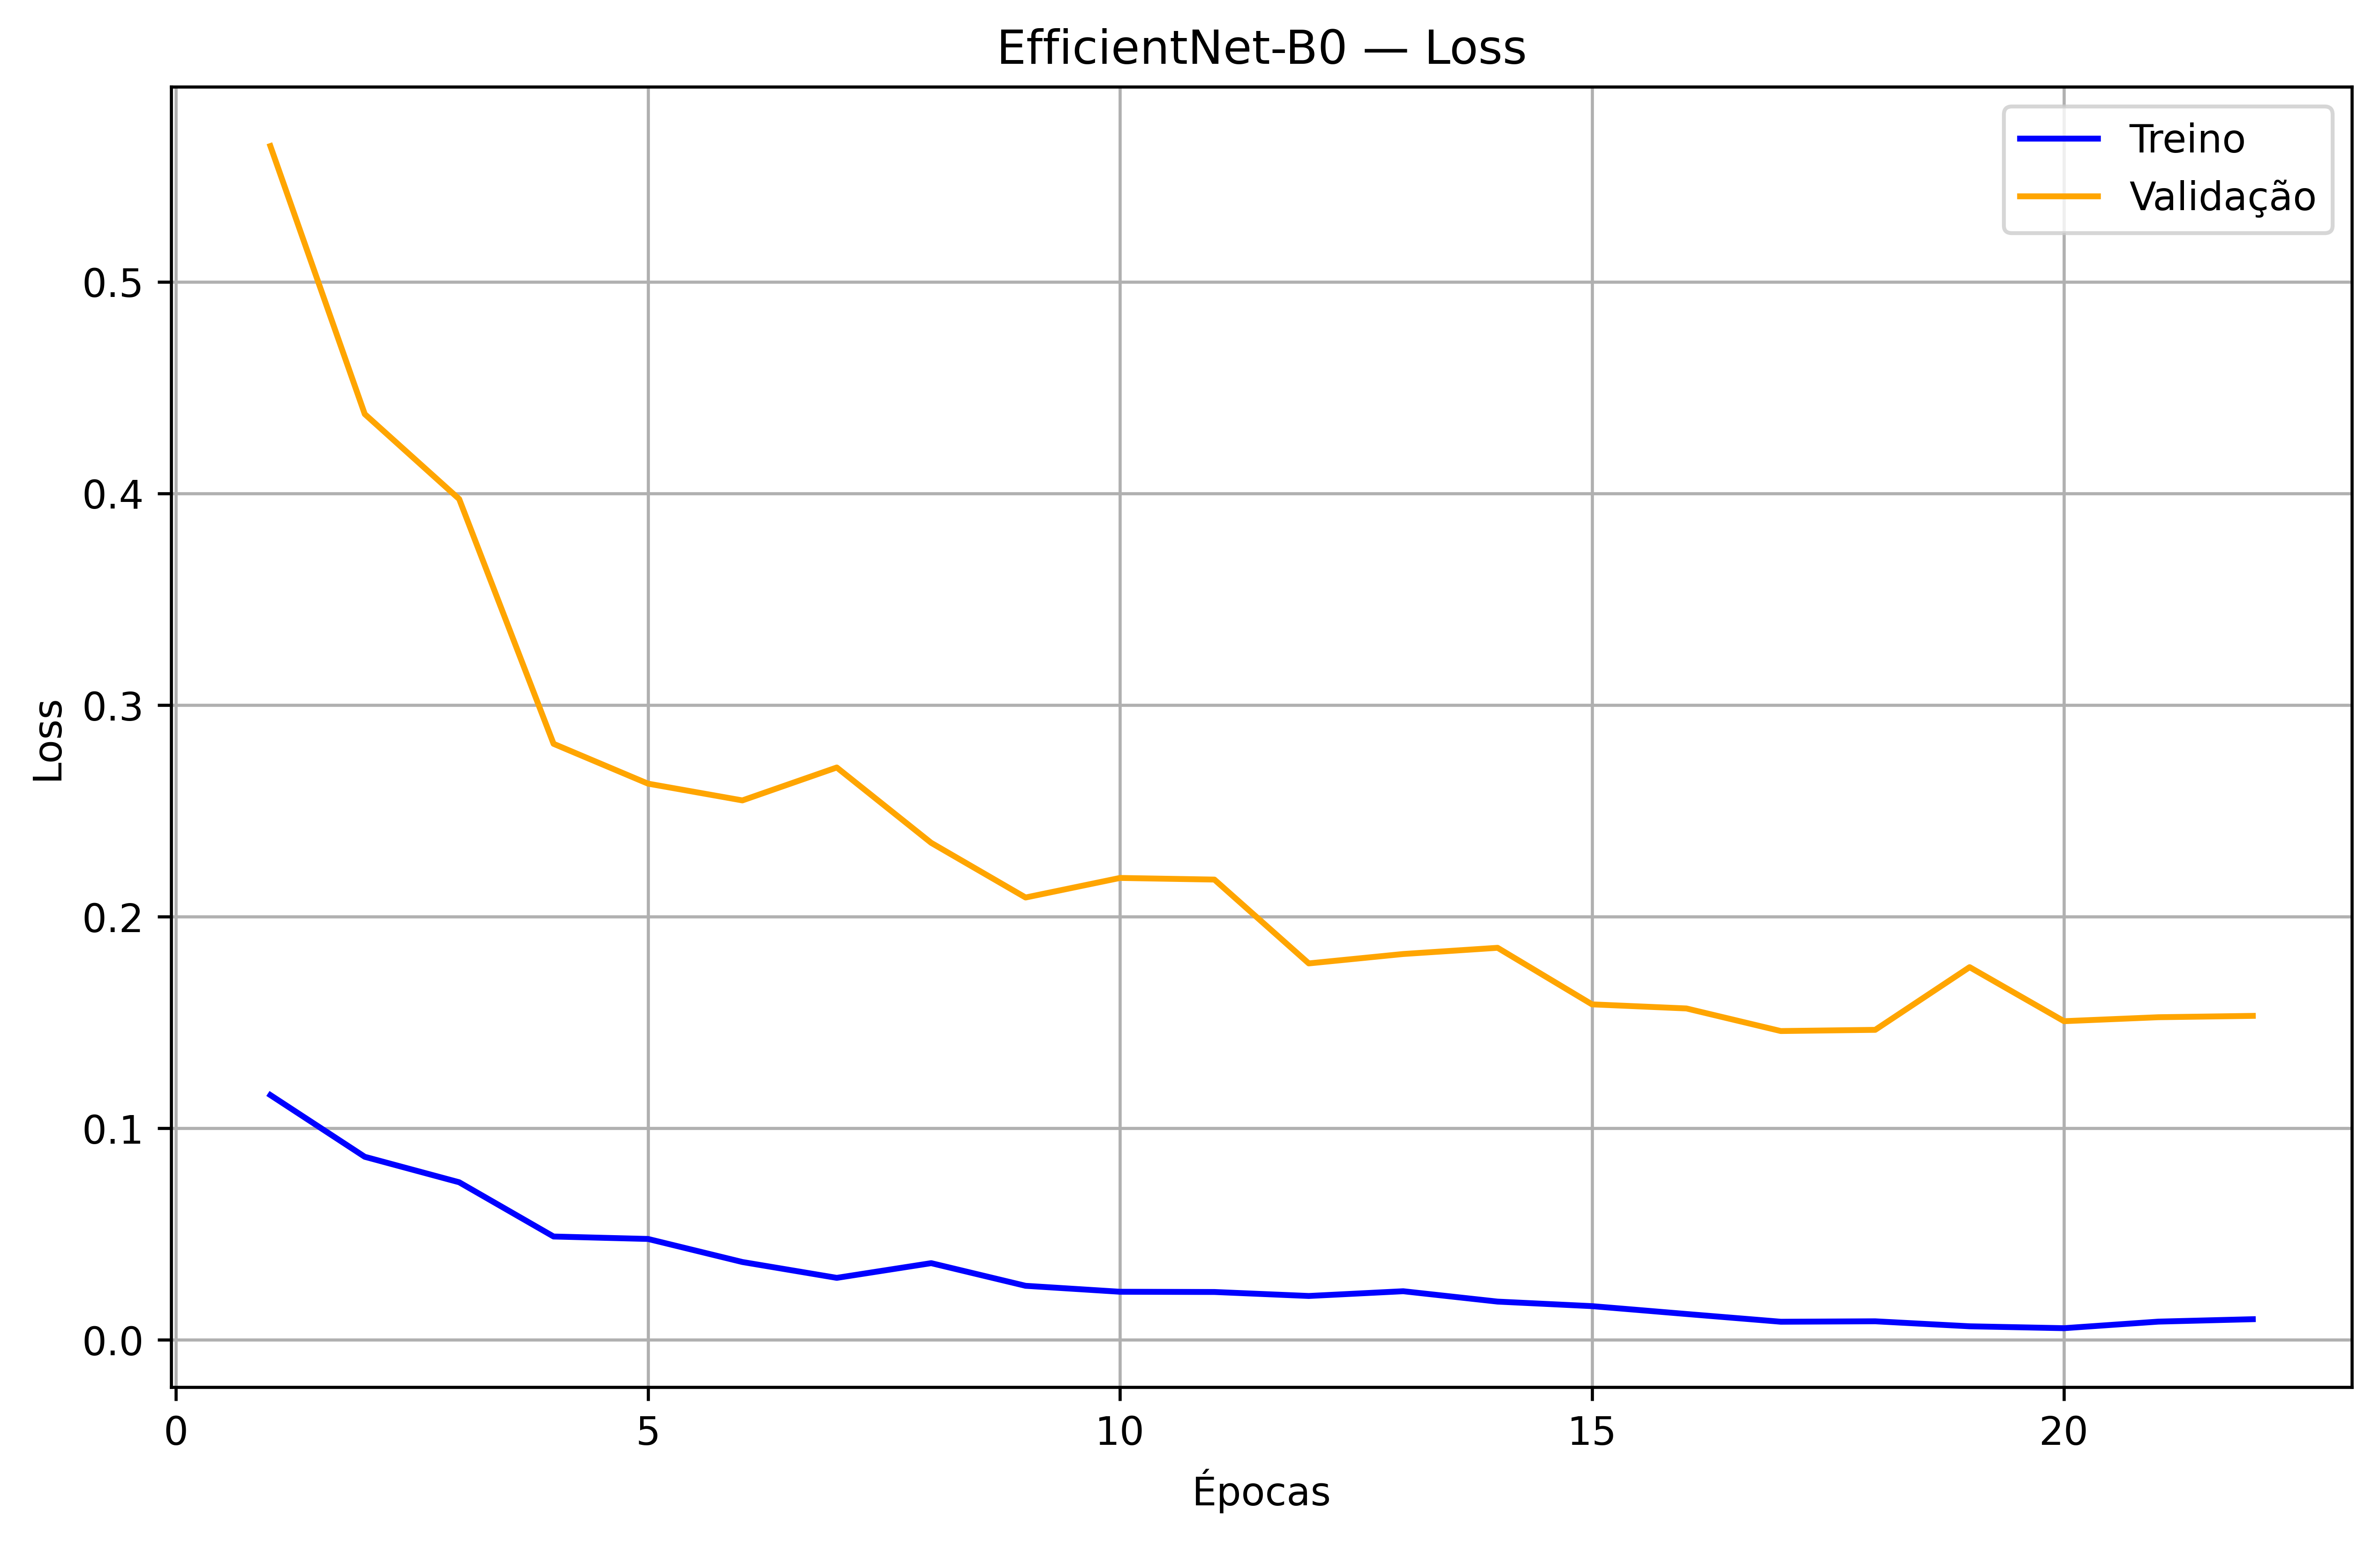

In [36]:
# Plot Loss treino vs validação
plt.figure(figsize=(10,6), dpi=600)
plt.plot(hist_epochs_e, hist_train_loss_e, label="Treino", color="blue")
plt.plot(hist_epochs_e, hist_val_loss_e, label="Validação", color="orange")
plt.title("EfficientNet-B0 — Loss")
plt.xlabel("Épocas"); plt.ylabel("Loss")
plt.grid(True); plt.legend(); plt.show()

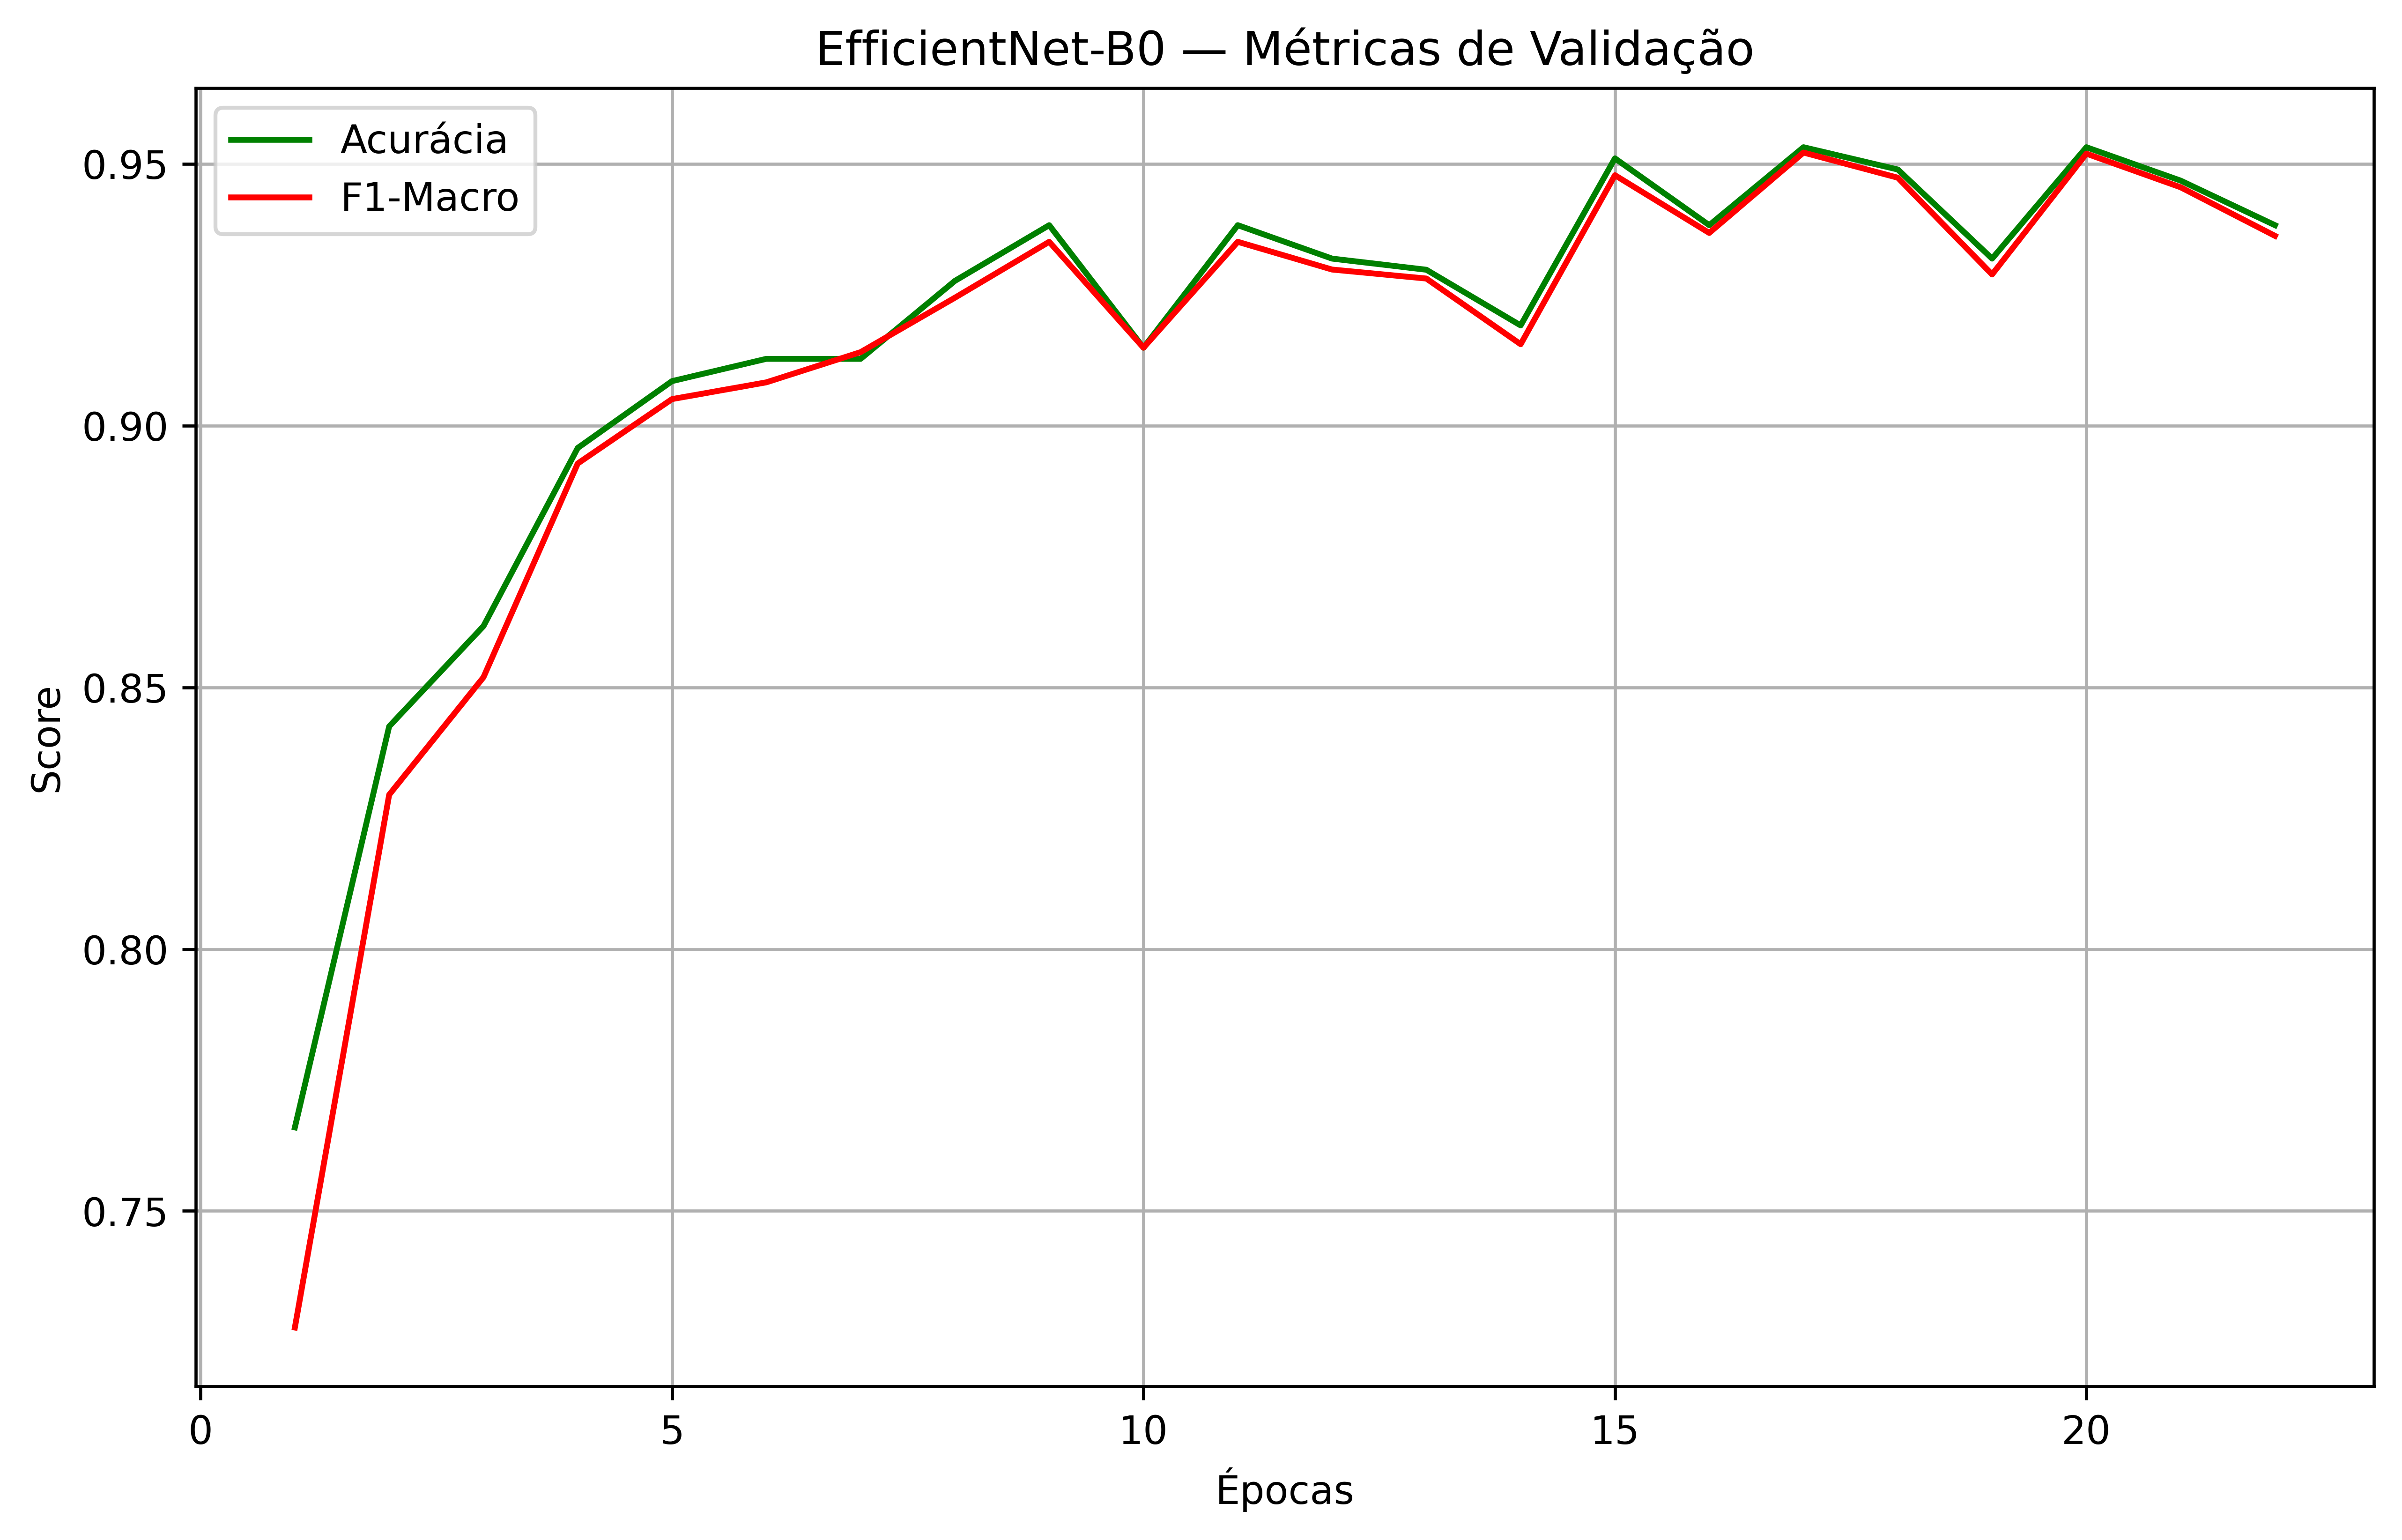

In [37]:
# Plot Métricas accuracy vs F1
plt.figure(figsize=(10,6), dpi=600)
plt.plot(hist_epochs_e, hist_val_acc_e, label="Acurácia", color="green")
plt.plot(hist_epochs_e, hist_val_f1_e, label="F1-Macro", color="red")
plt.title("EfficientNet-B0 — Métricas de Validação")
plt.xlabel("Épocas"); plt.ylabel("Score")
plt.grid(True); plt.legend(); plt.show()

## Teste

### Classificação

In [38]:
# Execução da avaliação 
test_loss_e, test_acc_e, test_f1_e, y_pred_e, y_true_e = eval_classification(
    efficientnet, test_loader, device, criterion
)
print(f"[EfficientNet-B0 BEST] test_loss={test_loss_e:.4f} | test_acc={test_acc_e:.4f} | test_f1={test_f1_e:.4f}")

[EfficientNet-B0 BEST] test_loss=0.1649 | test_acc=0.9340 | test_f1=0.9339


### Matriz de confusão

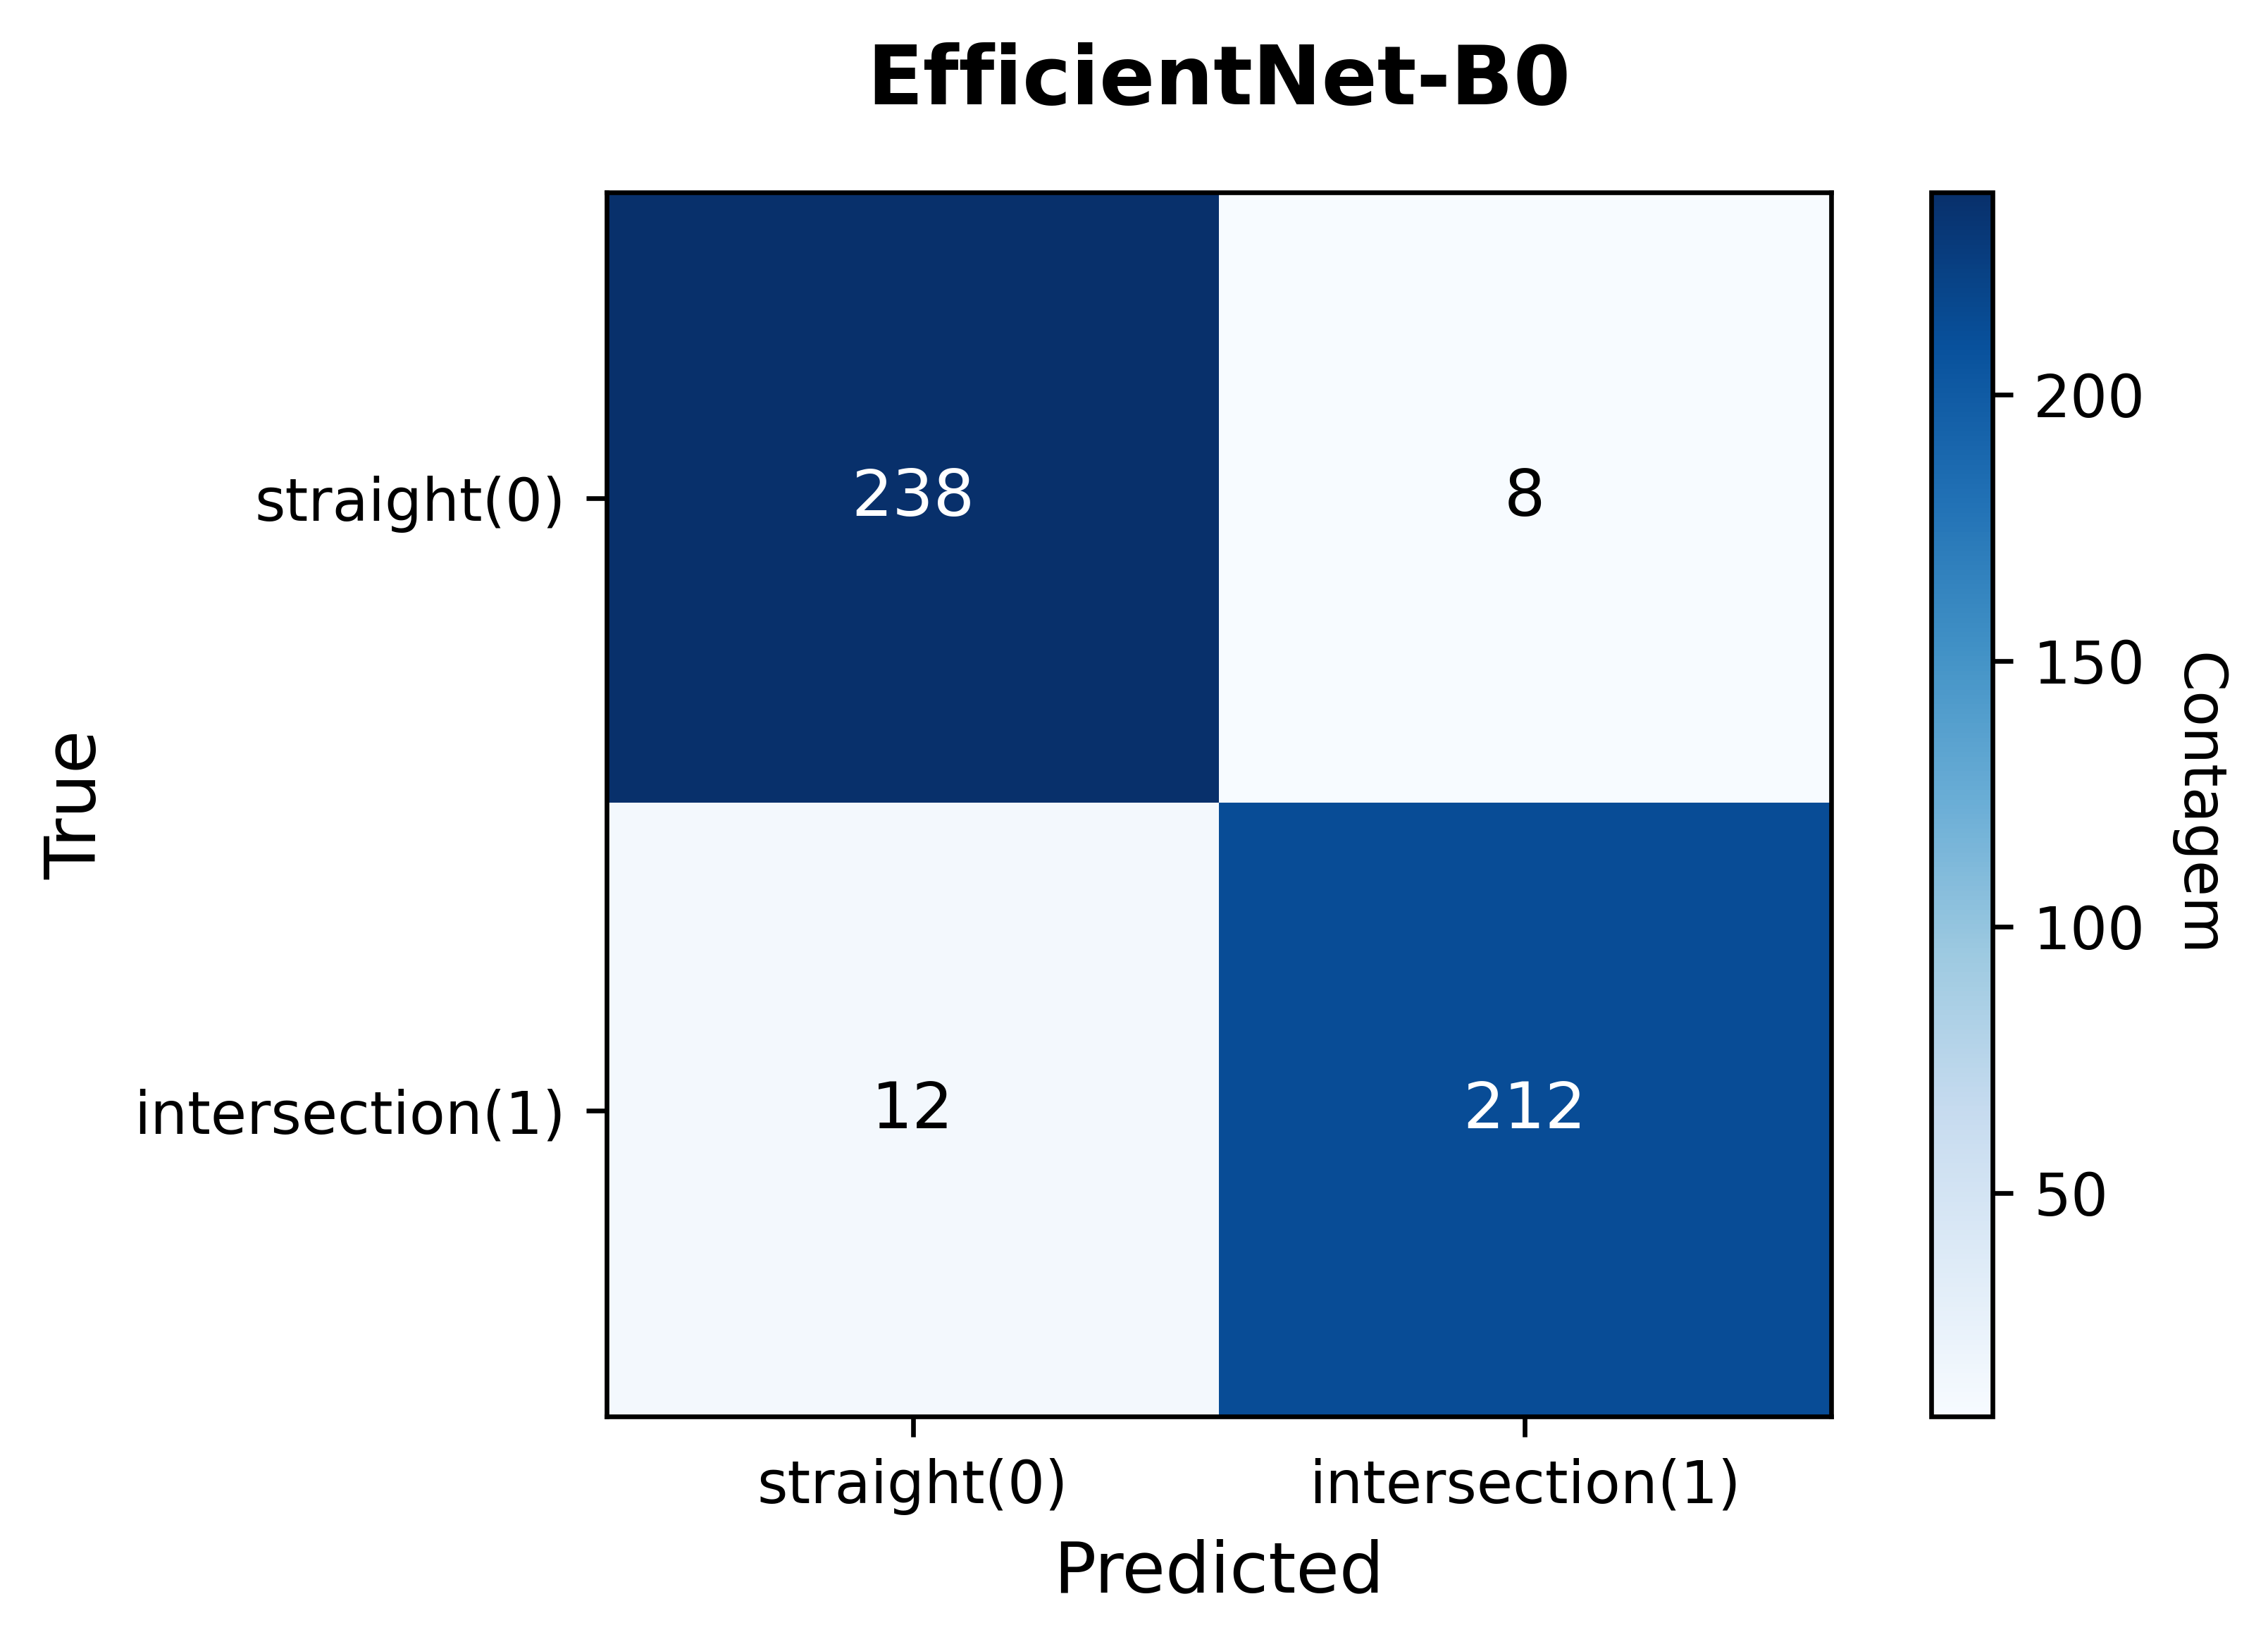

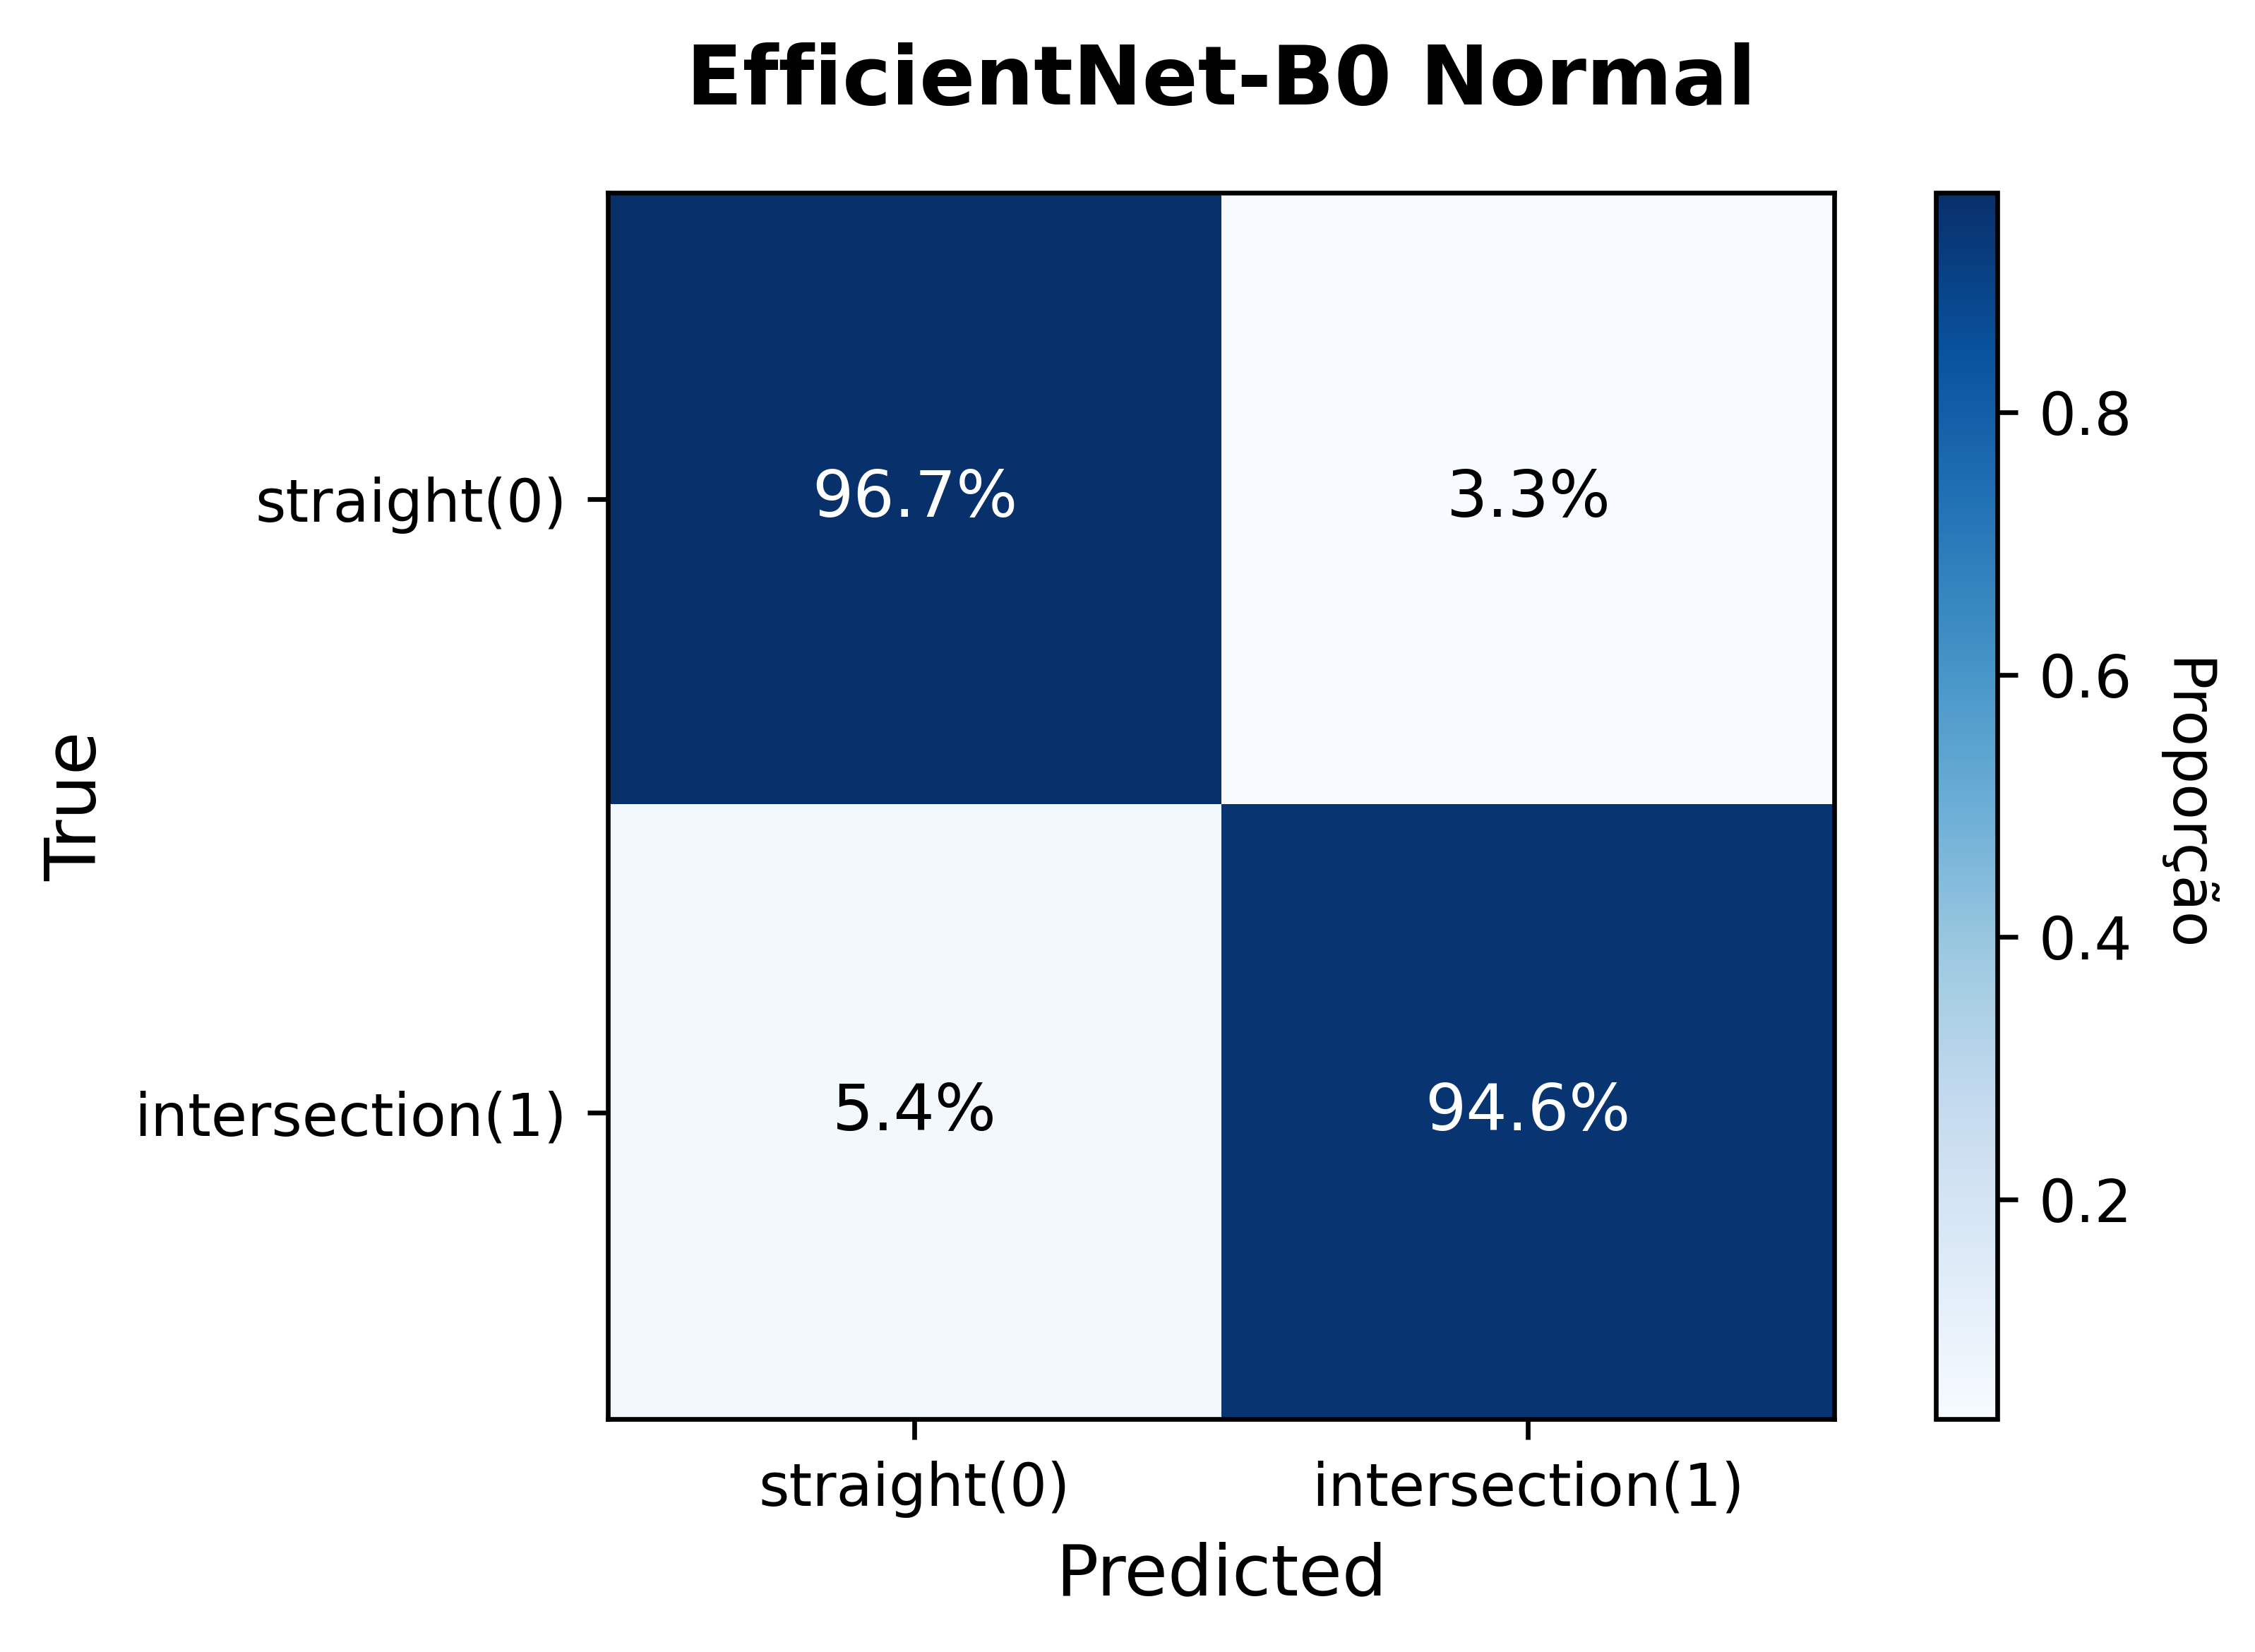

In [39]:
# Matriz de confusão
cm_e = confusion_matrix(y_true_m, y_pred_m, labels=[0, 1])

plot_confusion_matrix(cm_e, class_names, title="EfficientNet-B0", normalize=False)
plot_confusion_matrix(cm_e, class_names, title="EfficientNet-B0 Normal", normalize=True)

### FPS e Recursos

In [40]:
# Métricas de eficiência computacional
perf_e = measure_perf(
    efficientnet, test_loader, device,
    warmup_batches=3,     # pequeno aquecimento
    sample_interval=5,    # amostrar recursos a cada 5 batches
    max_batches=None      # ou limite ex.: 200, se desejar reduzir tempo
)

# Impressão consolidada
print("\n=== Eficiência Computacional (EfficientNet-B0) ===")
print(f"FPS médio:                 {perf_e['fps_mean']:.2f}")
print(f"CPU média (%):             {perf_e['cpu_percent_mean']:.1f}" if not np.isnan(perf_e['cpu_percent_mean']) else "CPU média (%):             N/D")
print(f"RAM média (MB):            {perf_e['ram_mb_mean']:.1f}" if not np.isnan(perf_e['ram_mb_mean']) else "RAM média (MB):            N/D")
print(f"GPU Util média (%):        {perf_e['gpu_util_percent_mean']:.1f}" if not np.isnan(perf_e['gpu_util_percent_mean']) else "GPU Util média (%):        N/D")
print(f"GPU Mem aloc média (MB):   {perf_e['gpu_mem_mb_mean']:.1f}" if not np.isnan(perf_e['gpu_mem_mb_mean']) else "GPU Mem aloc média (MB):   N/D")
print(f"Frames contabilizados:     {perf_e['frames_counted']}")
print(f"Tempo total (s):           {perf_e['time_seconds']:.2f}")


=== Eficiência Computacional (EfficientNet-B0) ===
FPS médio:                 324.19
CPU média (%):             608.4
RAM média (MB):            1927.4
GPU Util média (%):        N/D
GPU Mem aloc média (MB):   126.8
Frames contabilizados:     470
Tempo total (s):           1.45


# ShuffleNetV2

## Construção do modelo

In [41]:
gc.collect()
torch.cuda.empty_cache()

In [42]:
# Carrega o modelo ShuffleNetV2
num_classes_s = 2

# Carrega ShuffleNetV2 (pré-treinado quando disponível)
try:
    shufflenet = models.shufflenet_v2_x1_0(
        weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
    )
except Exception:
    shufflenet = models.shufflenet_v2_x1_0(weights=None)

# Troca apenas a última camada para 2 classes
in_features_s = shufflenet.fc.in_features         # <- camada final padrão
shufflenet.fc = nn.Linear(in_features_s, num_classes_s)

shufflenet = shufflenet.to(device)

## Treinamento

In [43]:
# Scheduler com warmup + cosine
base_lr_s = 3e-4
min_lr_s  = 1e-5
total_epochs_s  = 40
warmup_epochs_s = 3

def get_lr_s(epoch):
    """LR epoch-based (0-based) com warmup + cosine decay."""
    if epoch < warmup_epochs_s:
        return (epoch + 1) / warmup_epochs_s * base_lr_s
    t = (epoch - warmup_epochs_s) / max(1, (total_epochs_s - warmup_epochs_s))
    return min_lr_s + 0.5 * (base_lr_s - min_lr_s) * (1 + np.cos(np.pi * t))

optimizer_s = torch.optim.AdamW(shufflenet.parameters(), lr=base_lr_s, weight_decay=1e-4)

# Treinamento com Early Stopping + histórico em listas (para plot)-
epochs_s    = total_epochs_s
patience_s  = 6
min_delta_s = 0.0

model_path_s = "src/Models/shufflenet_v2.pth"

best_val_loss_s  = math.inf
best_epoch_s     = 0
trigger_times_s  = 0

use_focal_s   = True      # True = Focal Loss; False = MixUp + CE
mixup_alpha_s = 0.2

hist_epochs_s, hist_train_loss_s, hist_val_loss_s, hist_val_acc_s, hist_val_f1_s = [], [], [], [], []

scaler_s = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
best_state_s = None

for epoch in range(1, epochs_s + 1):
    shufflenet.train()
    for g in optimizer_s.param_groups:
        g['lr'] = get_lr_s(epoch-1)

    running_loss_s = 0.0

    for imgs, labels in train_loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_s.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            if use_focal_s:
                logits = shufflenet(imgs)
                loss   = focal_loss_e(logits, labels, gamma=2.0, alpha=0.75)
            else:
                imgs_m, y_mix, lam = mixup_batch_e(imgs, labels, alpha=mixup_alpha_s)
                logits = shufflenet(imgs_m)
                ya, yb = y_mix
                loss = lam * F.cross_entropy(logits, ya) + (1 - lam) * F.cross_entropy(logits, yb)

        scaler_s.scale(loss).backward()
        scaler_s.step(optimizer_s)
        scaler_s.update()

        running_loss_s += loss.item() * imgs.size(0)

    train_loss_s = running_loss_s / len(train_loader.dataset)

    # avaliação
    val_loss_s, val_acc_s, val_f1_s, _, _ = run_eval(shufflenet, val_loader, device)

    print(f"[ShuffleNetV2][Epoch {epoch:02d}] lr={optimizer_s.param_groups[0]['lr']:.6f} | "
          f"train_loss={train_loss_s:.4f} | val_loss={val_loss_s:.4f} | val_acc={val_acc_s:.4f} | val_f1={val_f1_s:.4f}")

    # salva melhor modelo
    if val_loss_s < (best_val_loss_s - min_delta_s):
        best_val_loss_s = val_loss_s
        best_epoch_s    = epoch
        trigger_times_s = 0
        torch.save(shufflenet.state_dict(), model_path_s)
    else:
        trigger_times_s += 1
        if trigger_times_s >= patience_s:
            print(f"Early stopping ativado na epoch {epoch:02d} (sem melhora por {patience_s} épocas).")
        
            break

    # histórico para plot
    hist_epochs_s.append(epoch)
    hist_train_loss_s.append(train_loss_s)
    hist_val_loss_s.append(val_loss_s)
    hist_val_acc_s.append(val_acc_s)
    hist_val_f1_s.append(val_f1_s)

# restaura melhor estado
map_loc = None if torch.cuda.is_available() else "cpu"
shufflenet.load_state_dict(torch.load(model_path_s, map_location=map_loc))
print(f"Melhor modelo (ShuffleNetV2) restaurado da epoch {best_epoch_s:02d} com val_loss={best_val_loss_s:.4f}.")

[ShuffleNetV2][Epoch 01] lr=0.000100 | train_loss=0.1257 | val_loss=0.6599 | val_acc=0.6681 | val_f1=0.5032
[ShuffleNetV2][Epoch 02] lr=0.000200 | train_loss=0.0992 | val_loss=0.4783 | val_acc=0.8319 | val_f1=0.8132
[ShuffleNetV2][Epoch 03] lr=0.000300 | train_loss=0.0754 | val_loss=0.4110 | val_acc=0.8596 | val_f1=0.8443
[ShuffleNetV2][Epoch 04] lr=0.000300 | train_loss=0.0575 | val_loss=0.3640 | val_acc=0.8979 | val_f1=0.8933
[ShuffleNetV2][Epoch 05] lr=0.000299 | train_loss=0.0492 | val_loss=0.3294 | val_acc=0.9043 | val_f1=0.9011
[ShuffleNetV2][Epoch 06] lr=0.000298 | train_loss=0.0452 | val_loss=0.3063 | val_acc=0.9191 | val_f1=0.9163
[ShuffleNetV2][Epoch 07] lr=0.000295 | train_loss=0.0359 | val_loss=0.2606 | val_acc=0.9234 | val_f1=0.9182
[ShuffleNetV2][Epoch 08] lr=0.000292 | train_loss=0.0328 | val_loss=0.2681 | val_acc=0.9170 | val_f1=0.9124
[ShuffleNetV2][Epoch 09] lr=0.000287 | train_loss=0.0260 | val_loss=0.2173 | val_acc=0.9362 | val_f1=0.9333
[ShuffleNetV2][Epoch 10] lr=

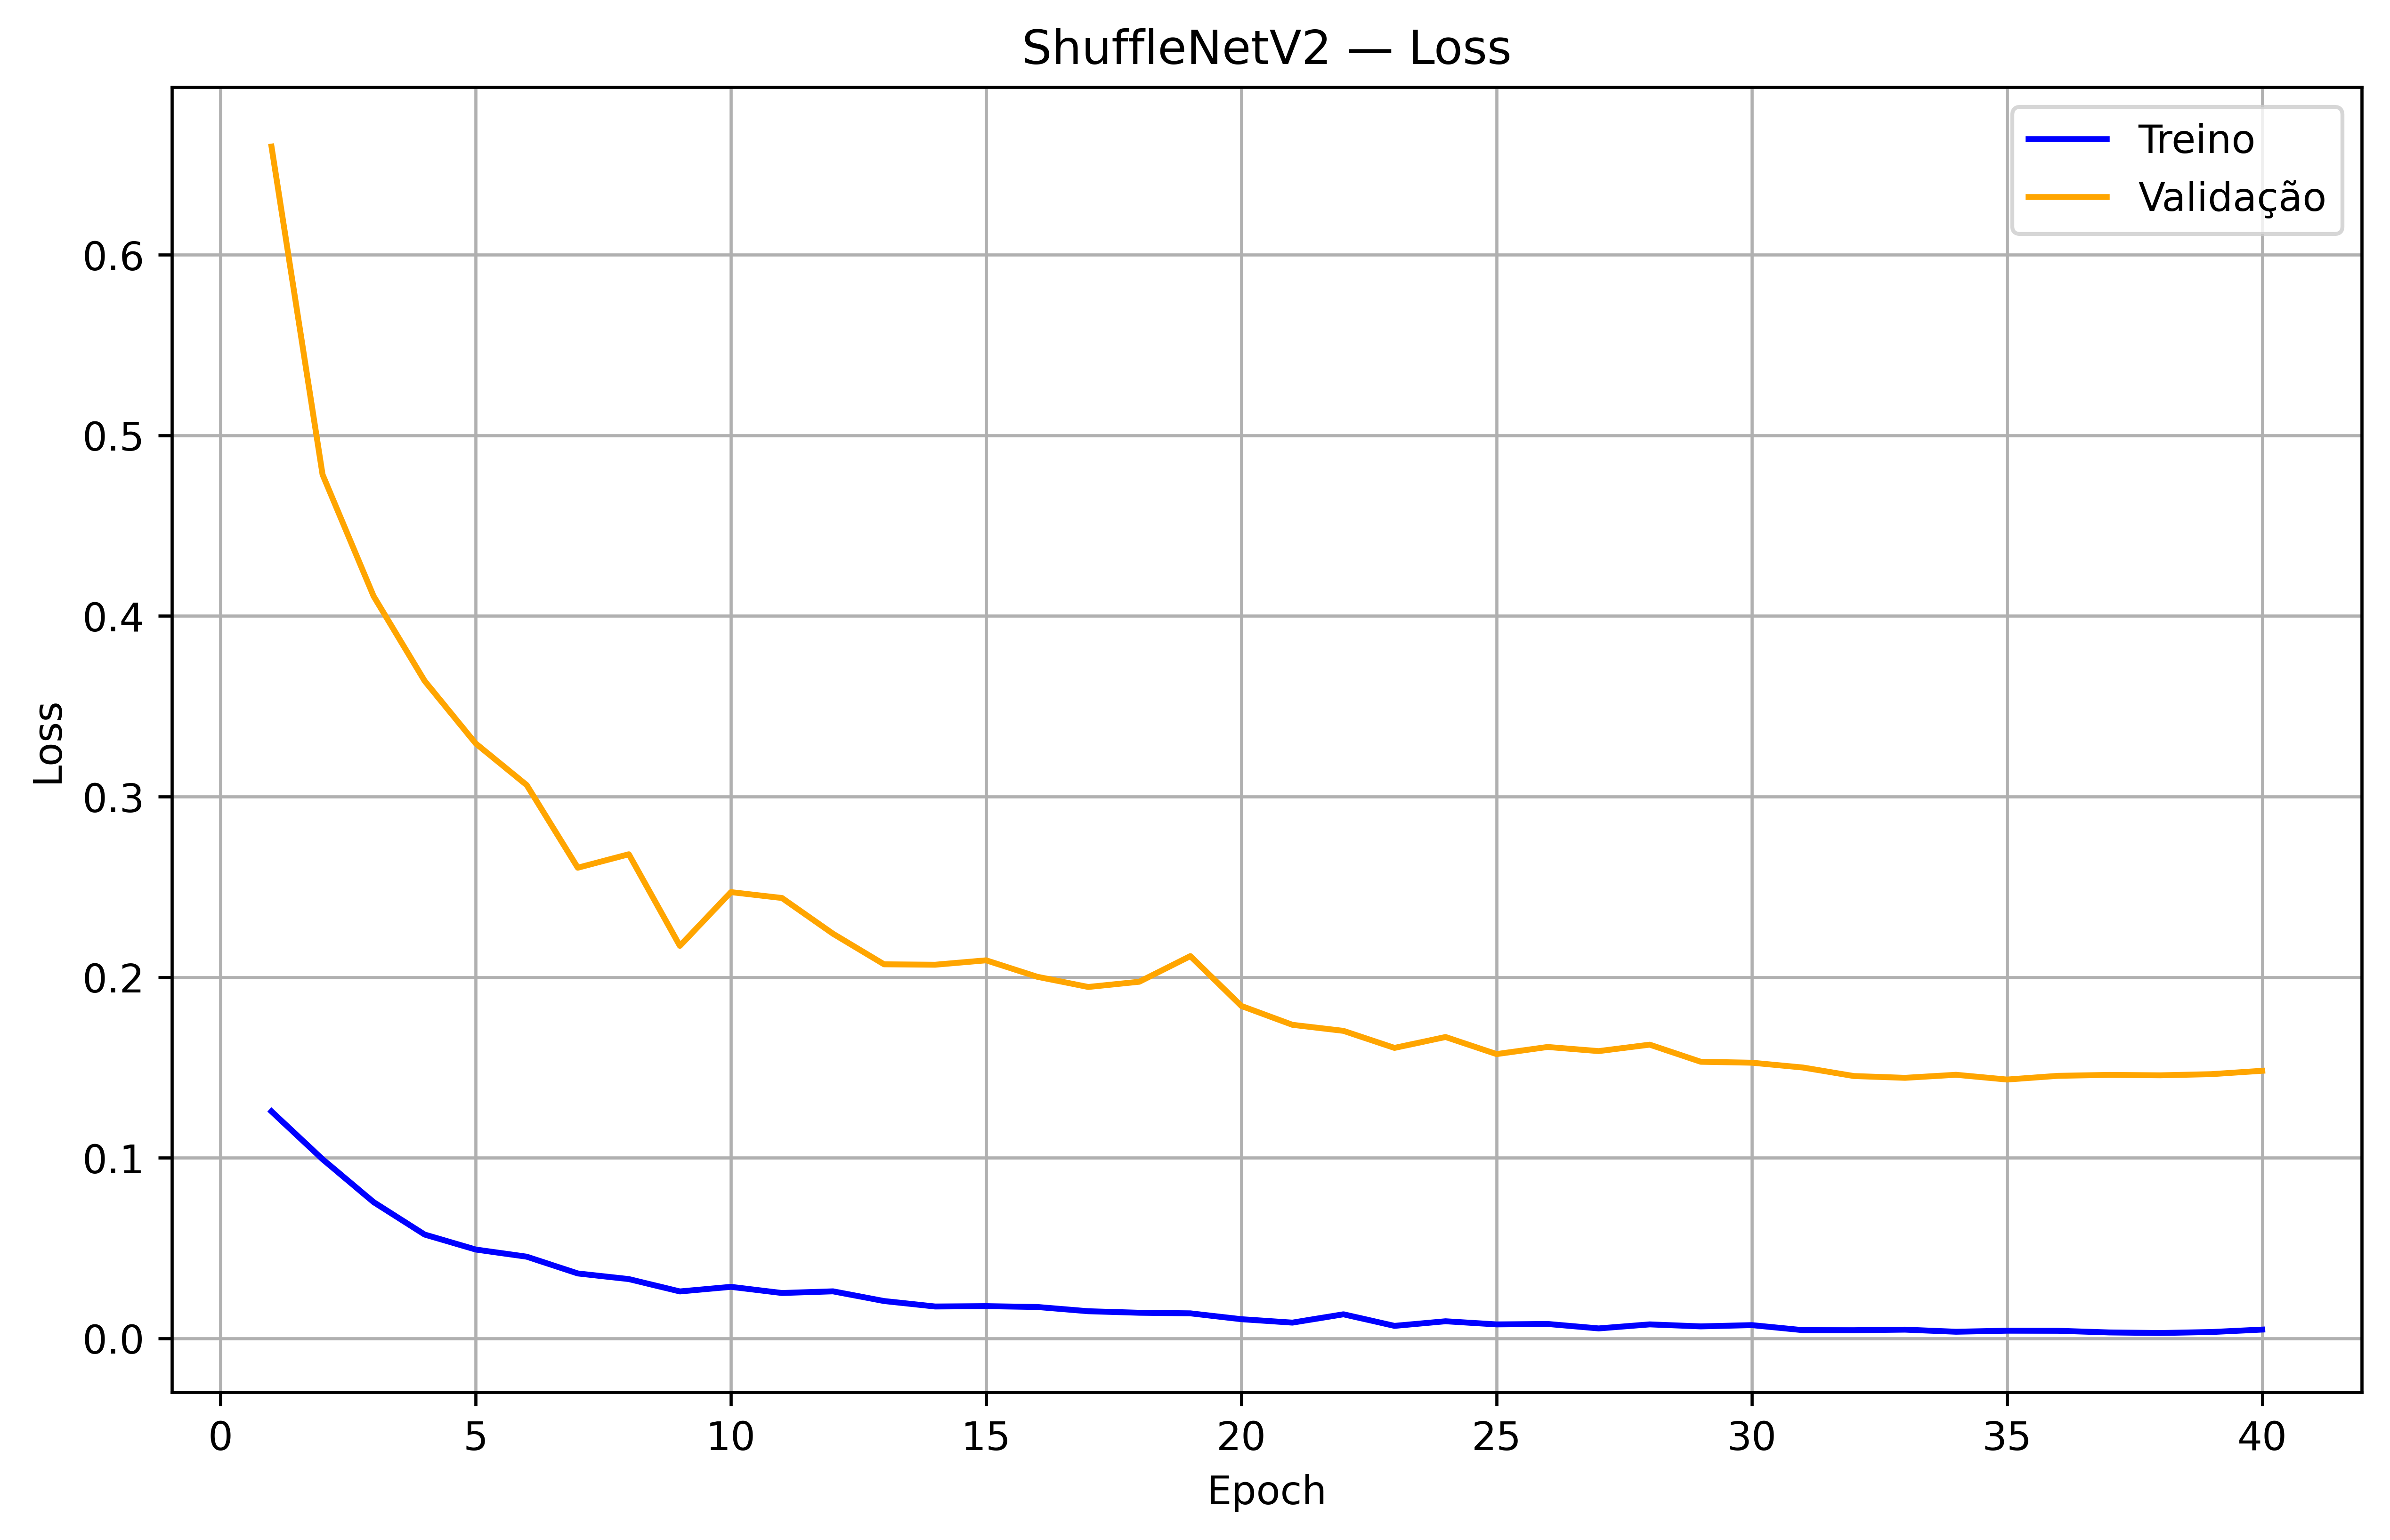

In [44]:
# Plot Loss treino vs validação
plt.figure(figsize=(10,6), dpi=600)
plt.plot(hist_epochs_s, hist_train_loss_s, label="Treino", color="blue")
plt.plot(hist_epochs_s, hist_val_loss_s,   label="Validação",   color="orange")
plt.title("ShuffleNetV2 — Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True); plt.legend(); plt.show()

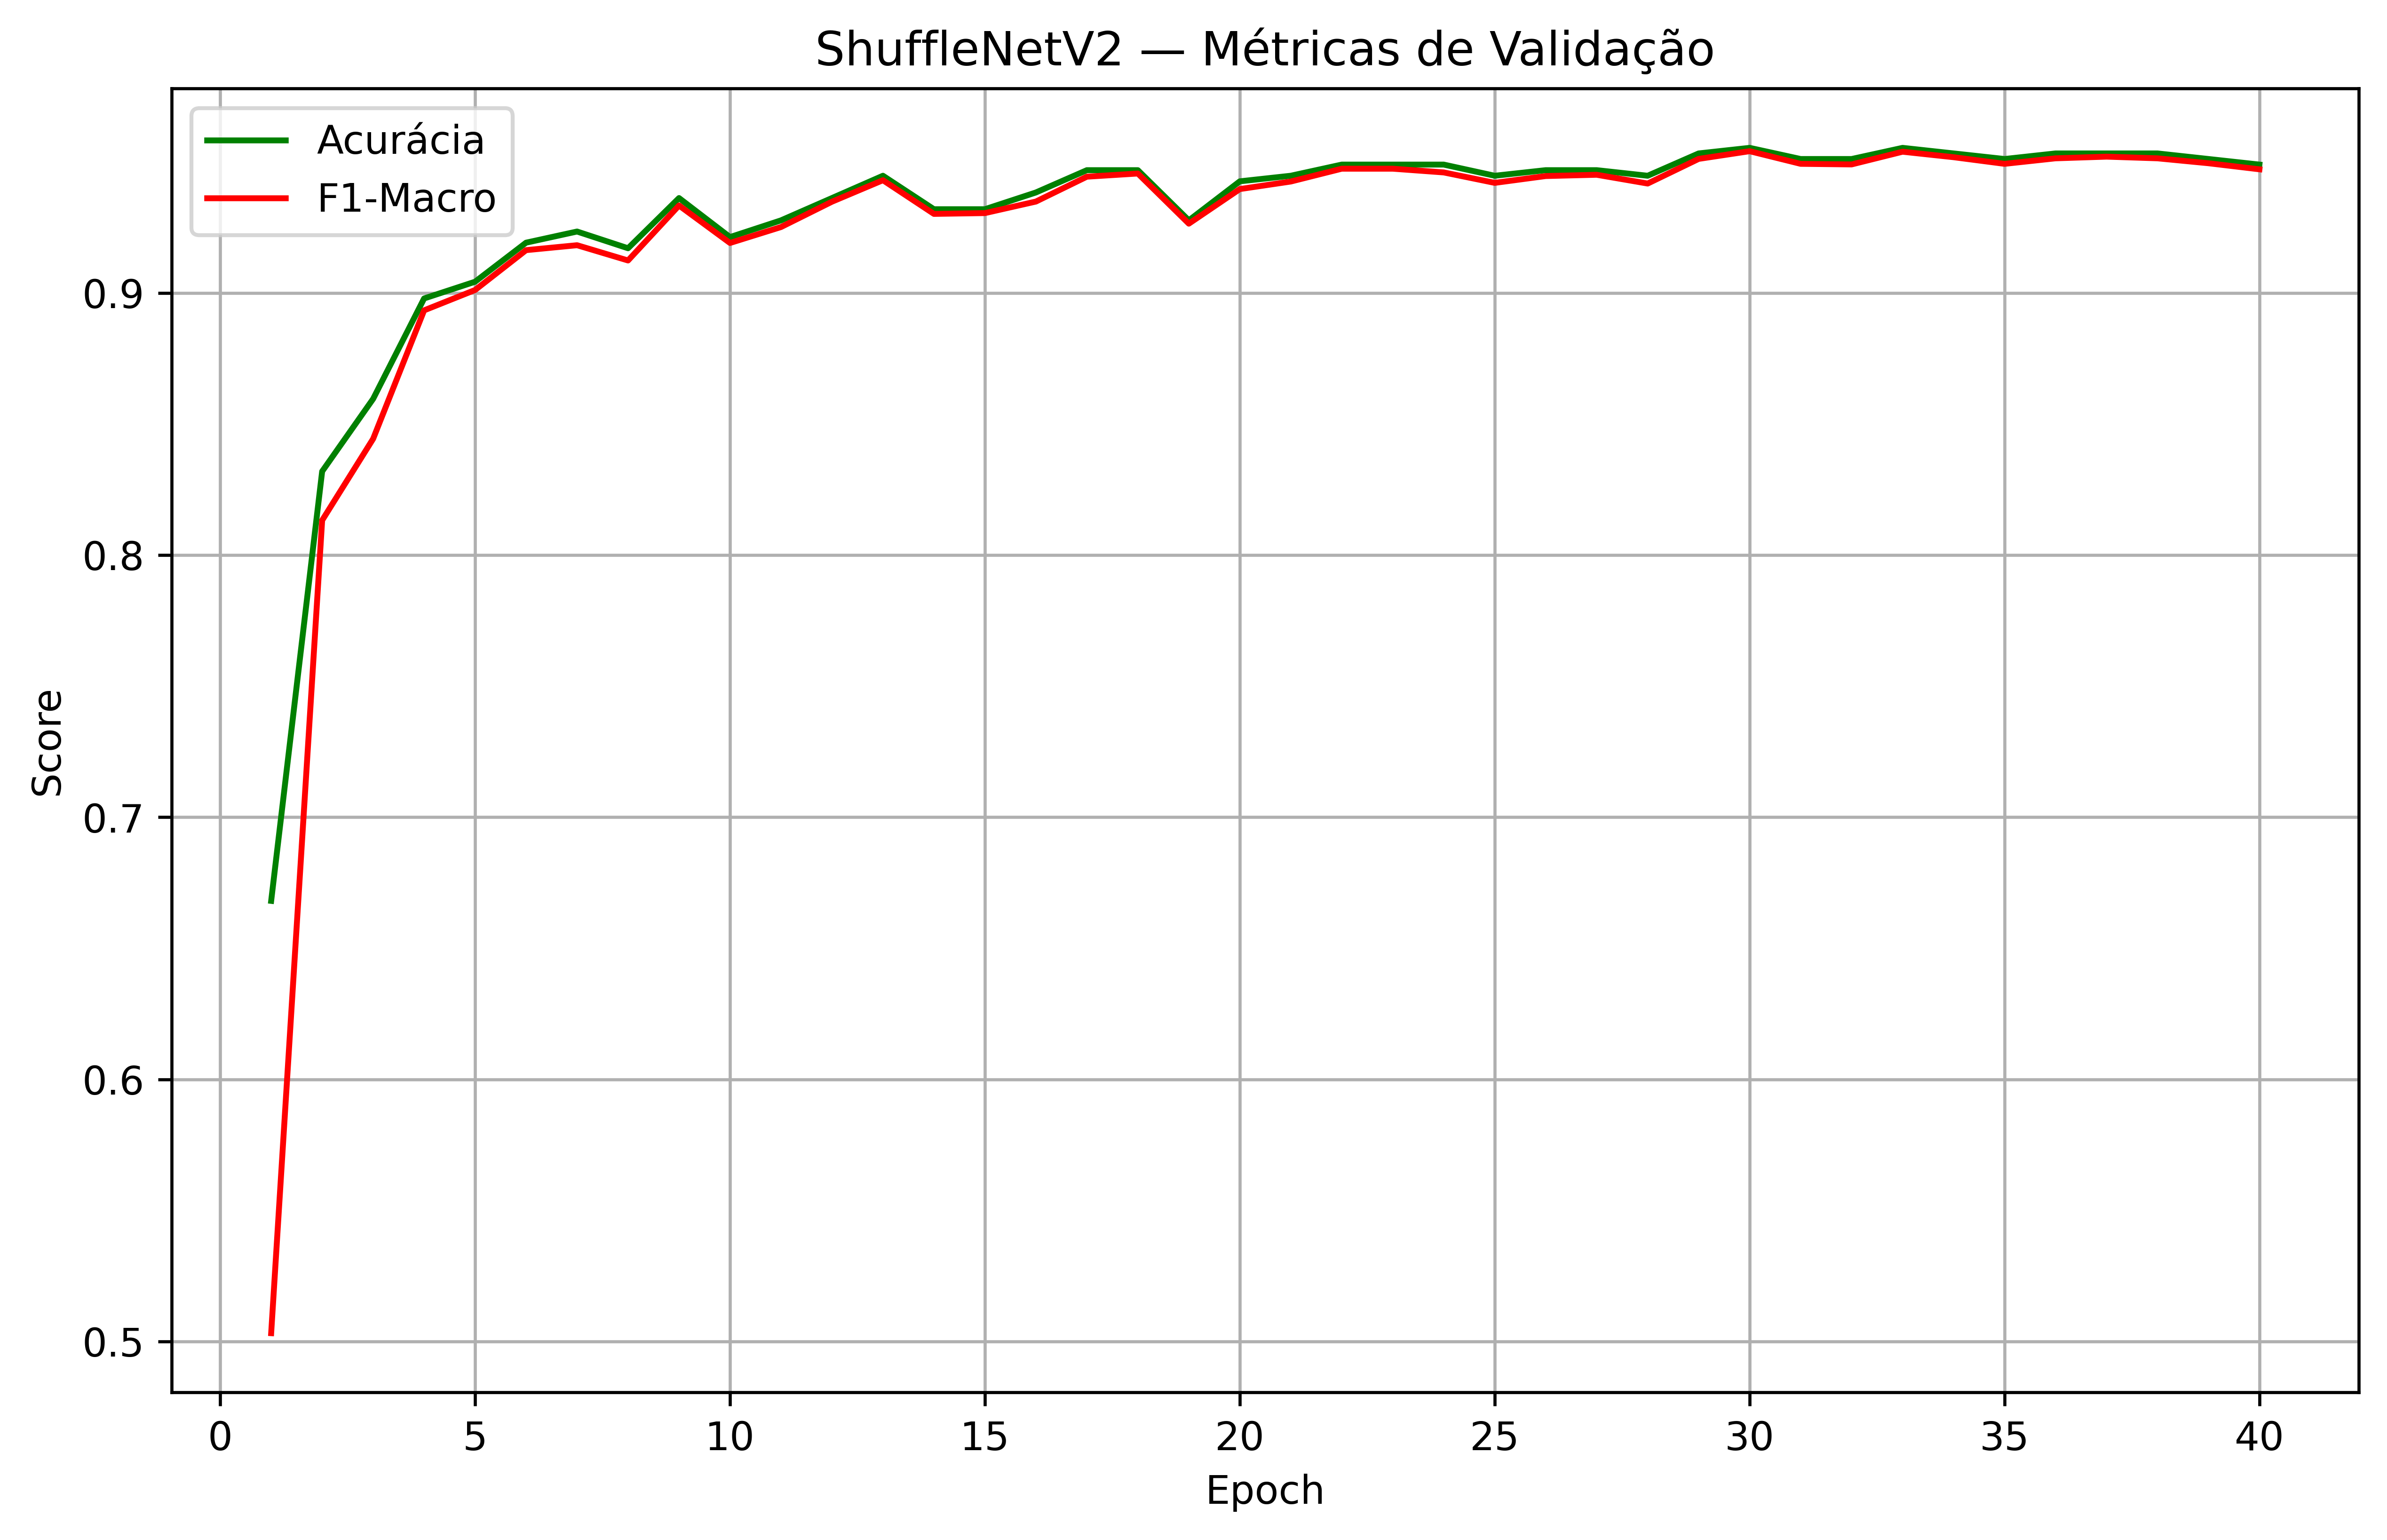

In [45]:
# Plot Métricas accuracy vs F1
plt.figure(figsize=(10,6), dpi=600)
plt.plot(hist_epochs_s, hist_val_acc_s, label="Acurácia", color="green")
plt.plot(hist_epochs_s, hist_val_f1_s,  label="F1-Macro", color="red")
plt.title("ShuffleNetV2 — Métricas de Validação"); plt.xlabel("Epoch"); plt.ylabel("Score")
plt.grid(True); plt.legend(); plt.show()

## Teste

### Classificação

In [46]:
# Execução da avaliação 
test_loss_s, test_acc_s, test_f1_s, y_pred_s, y_true_s = eval_classification(
    shufflenet, test_loader, device, criterion
)
print(f"[ShuffleNetV2 BEST] test_loss={test_loss_s:.4f} | test_acc={test_acc_s:.4f} | test_f1={test_f1_s:.4f}")

[ShuffleNetV2 BEST] test_loss=0.1536 | test_acc=0.9426 | test_f1=0.9424


### Matriz de confusão

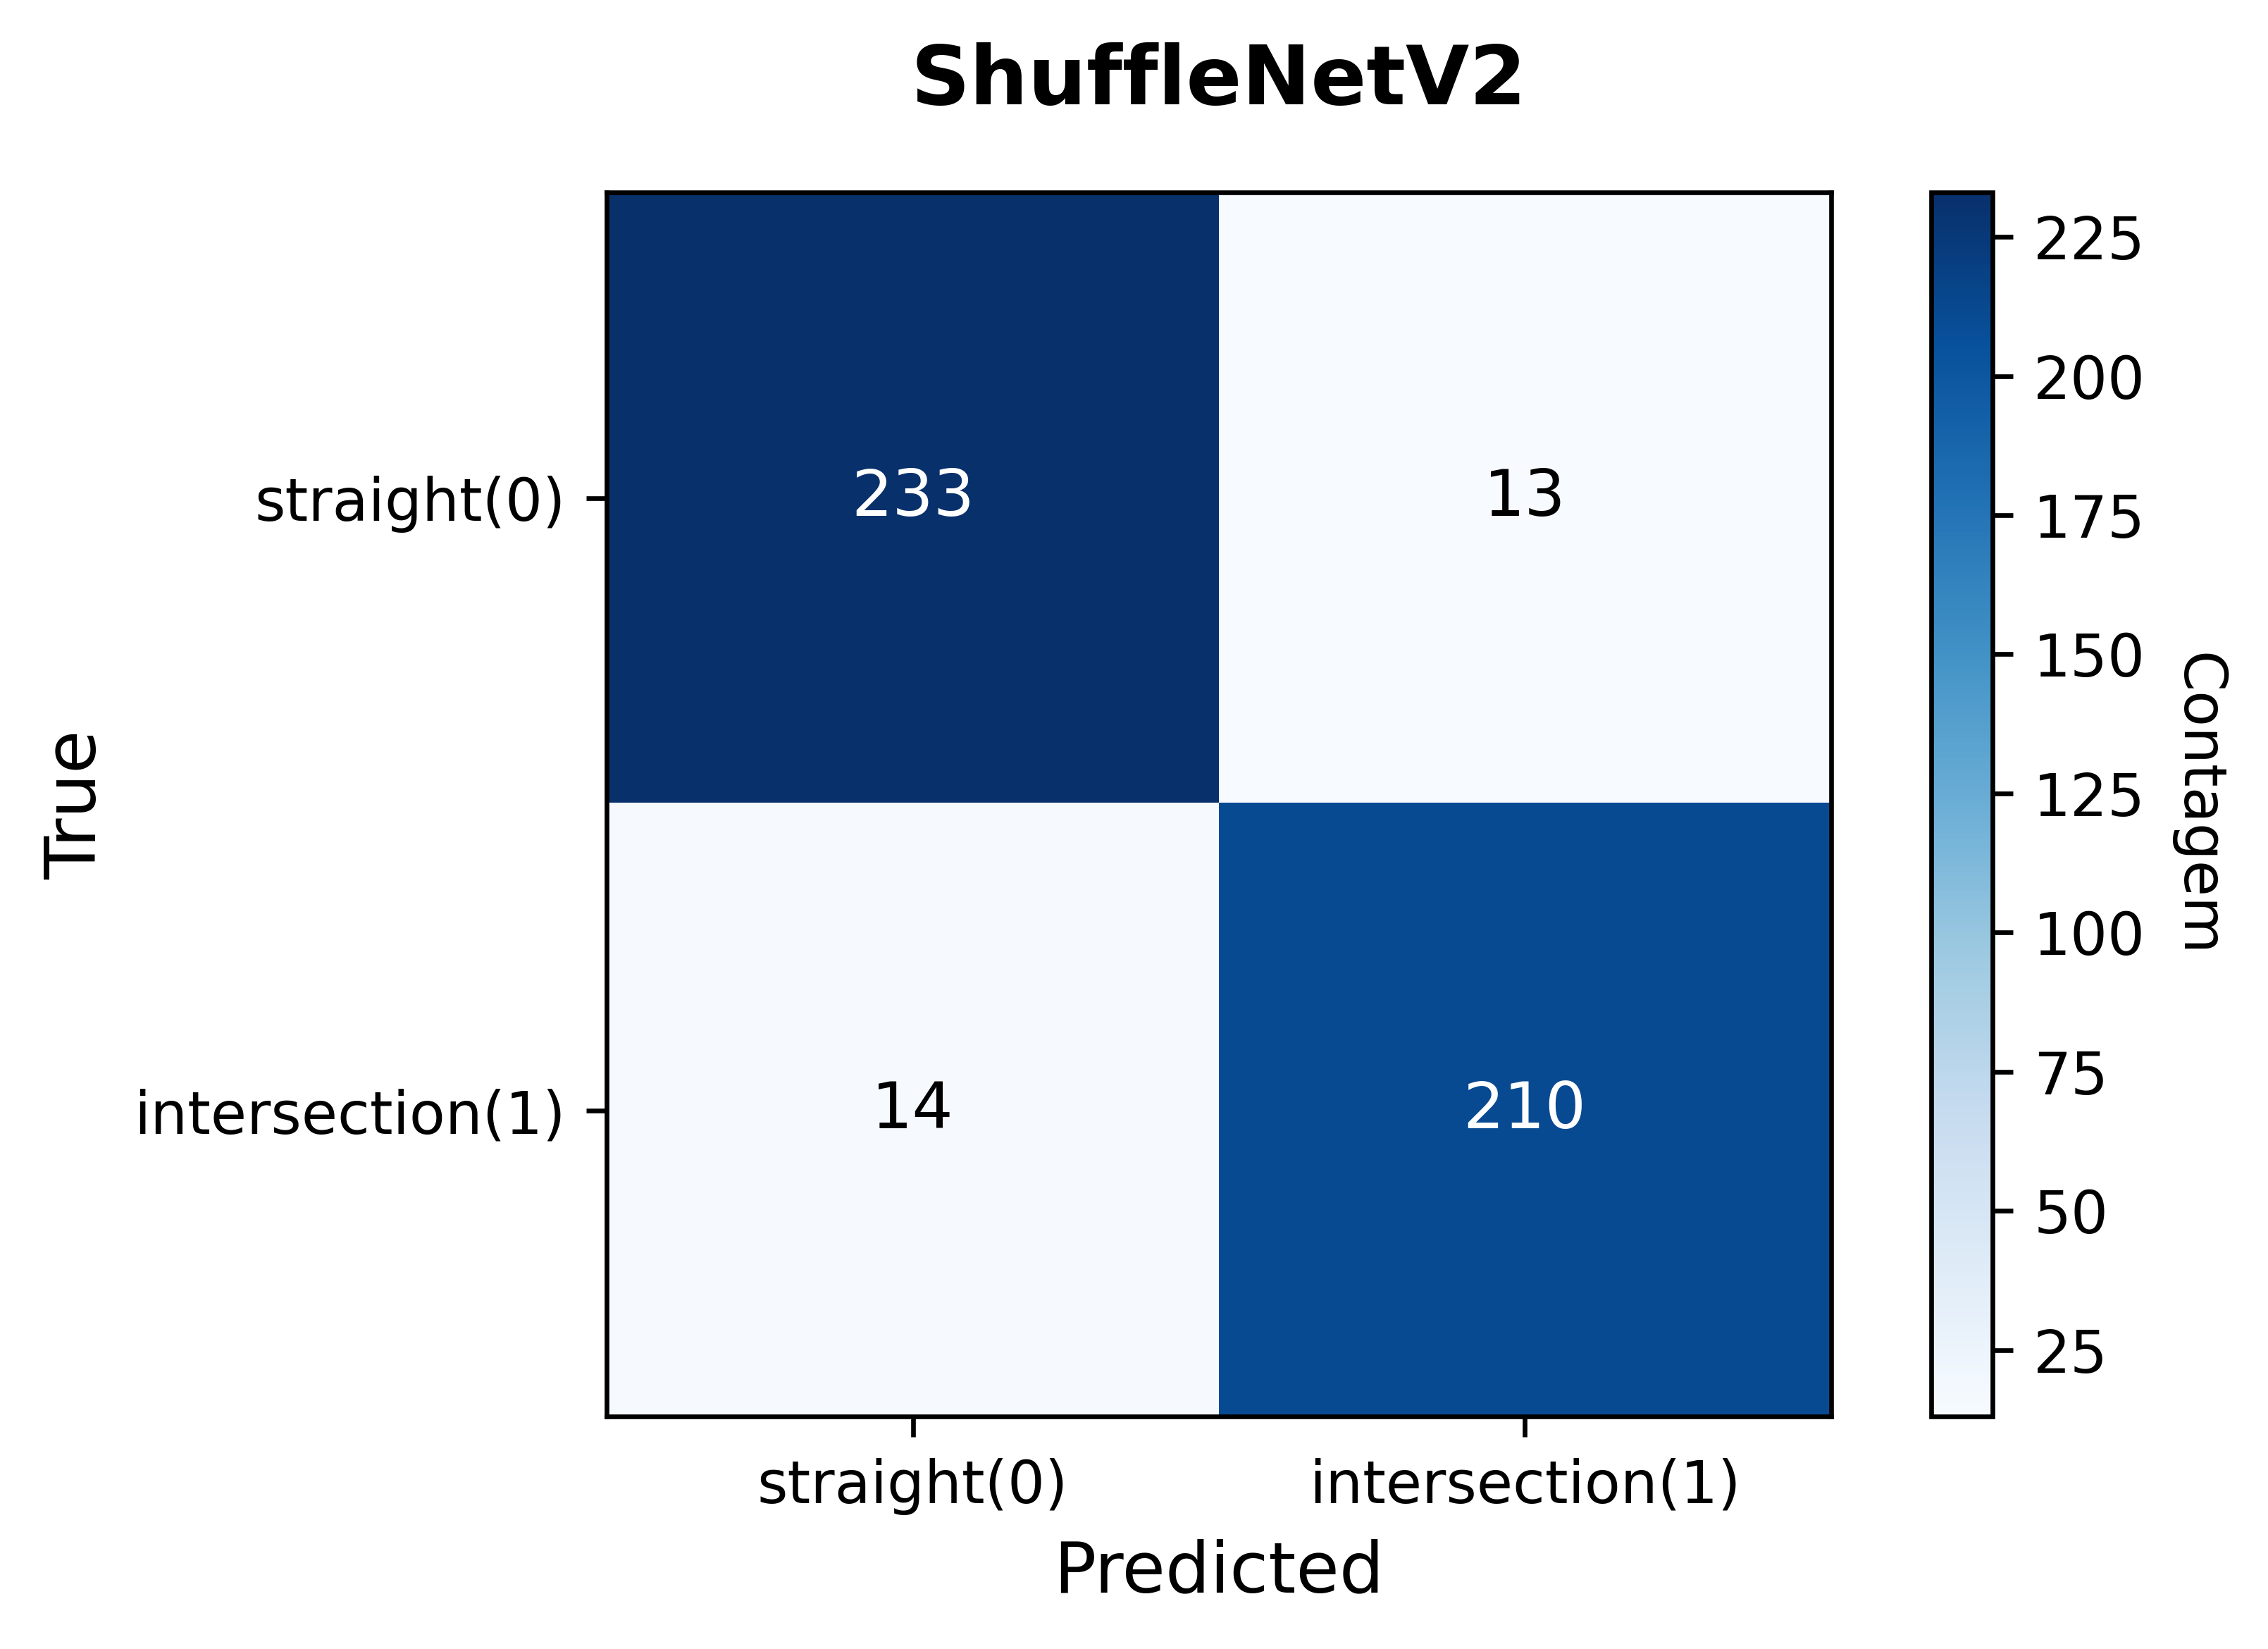

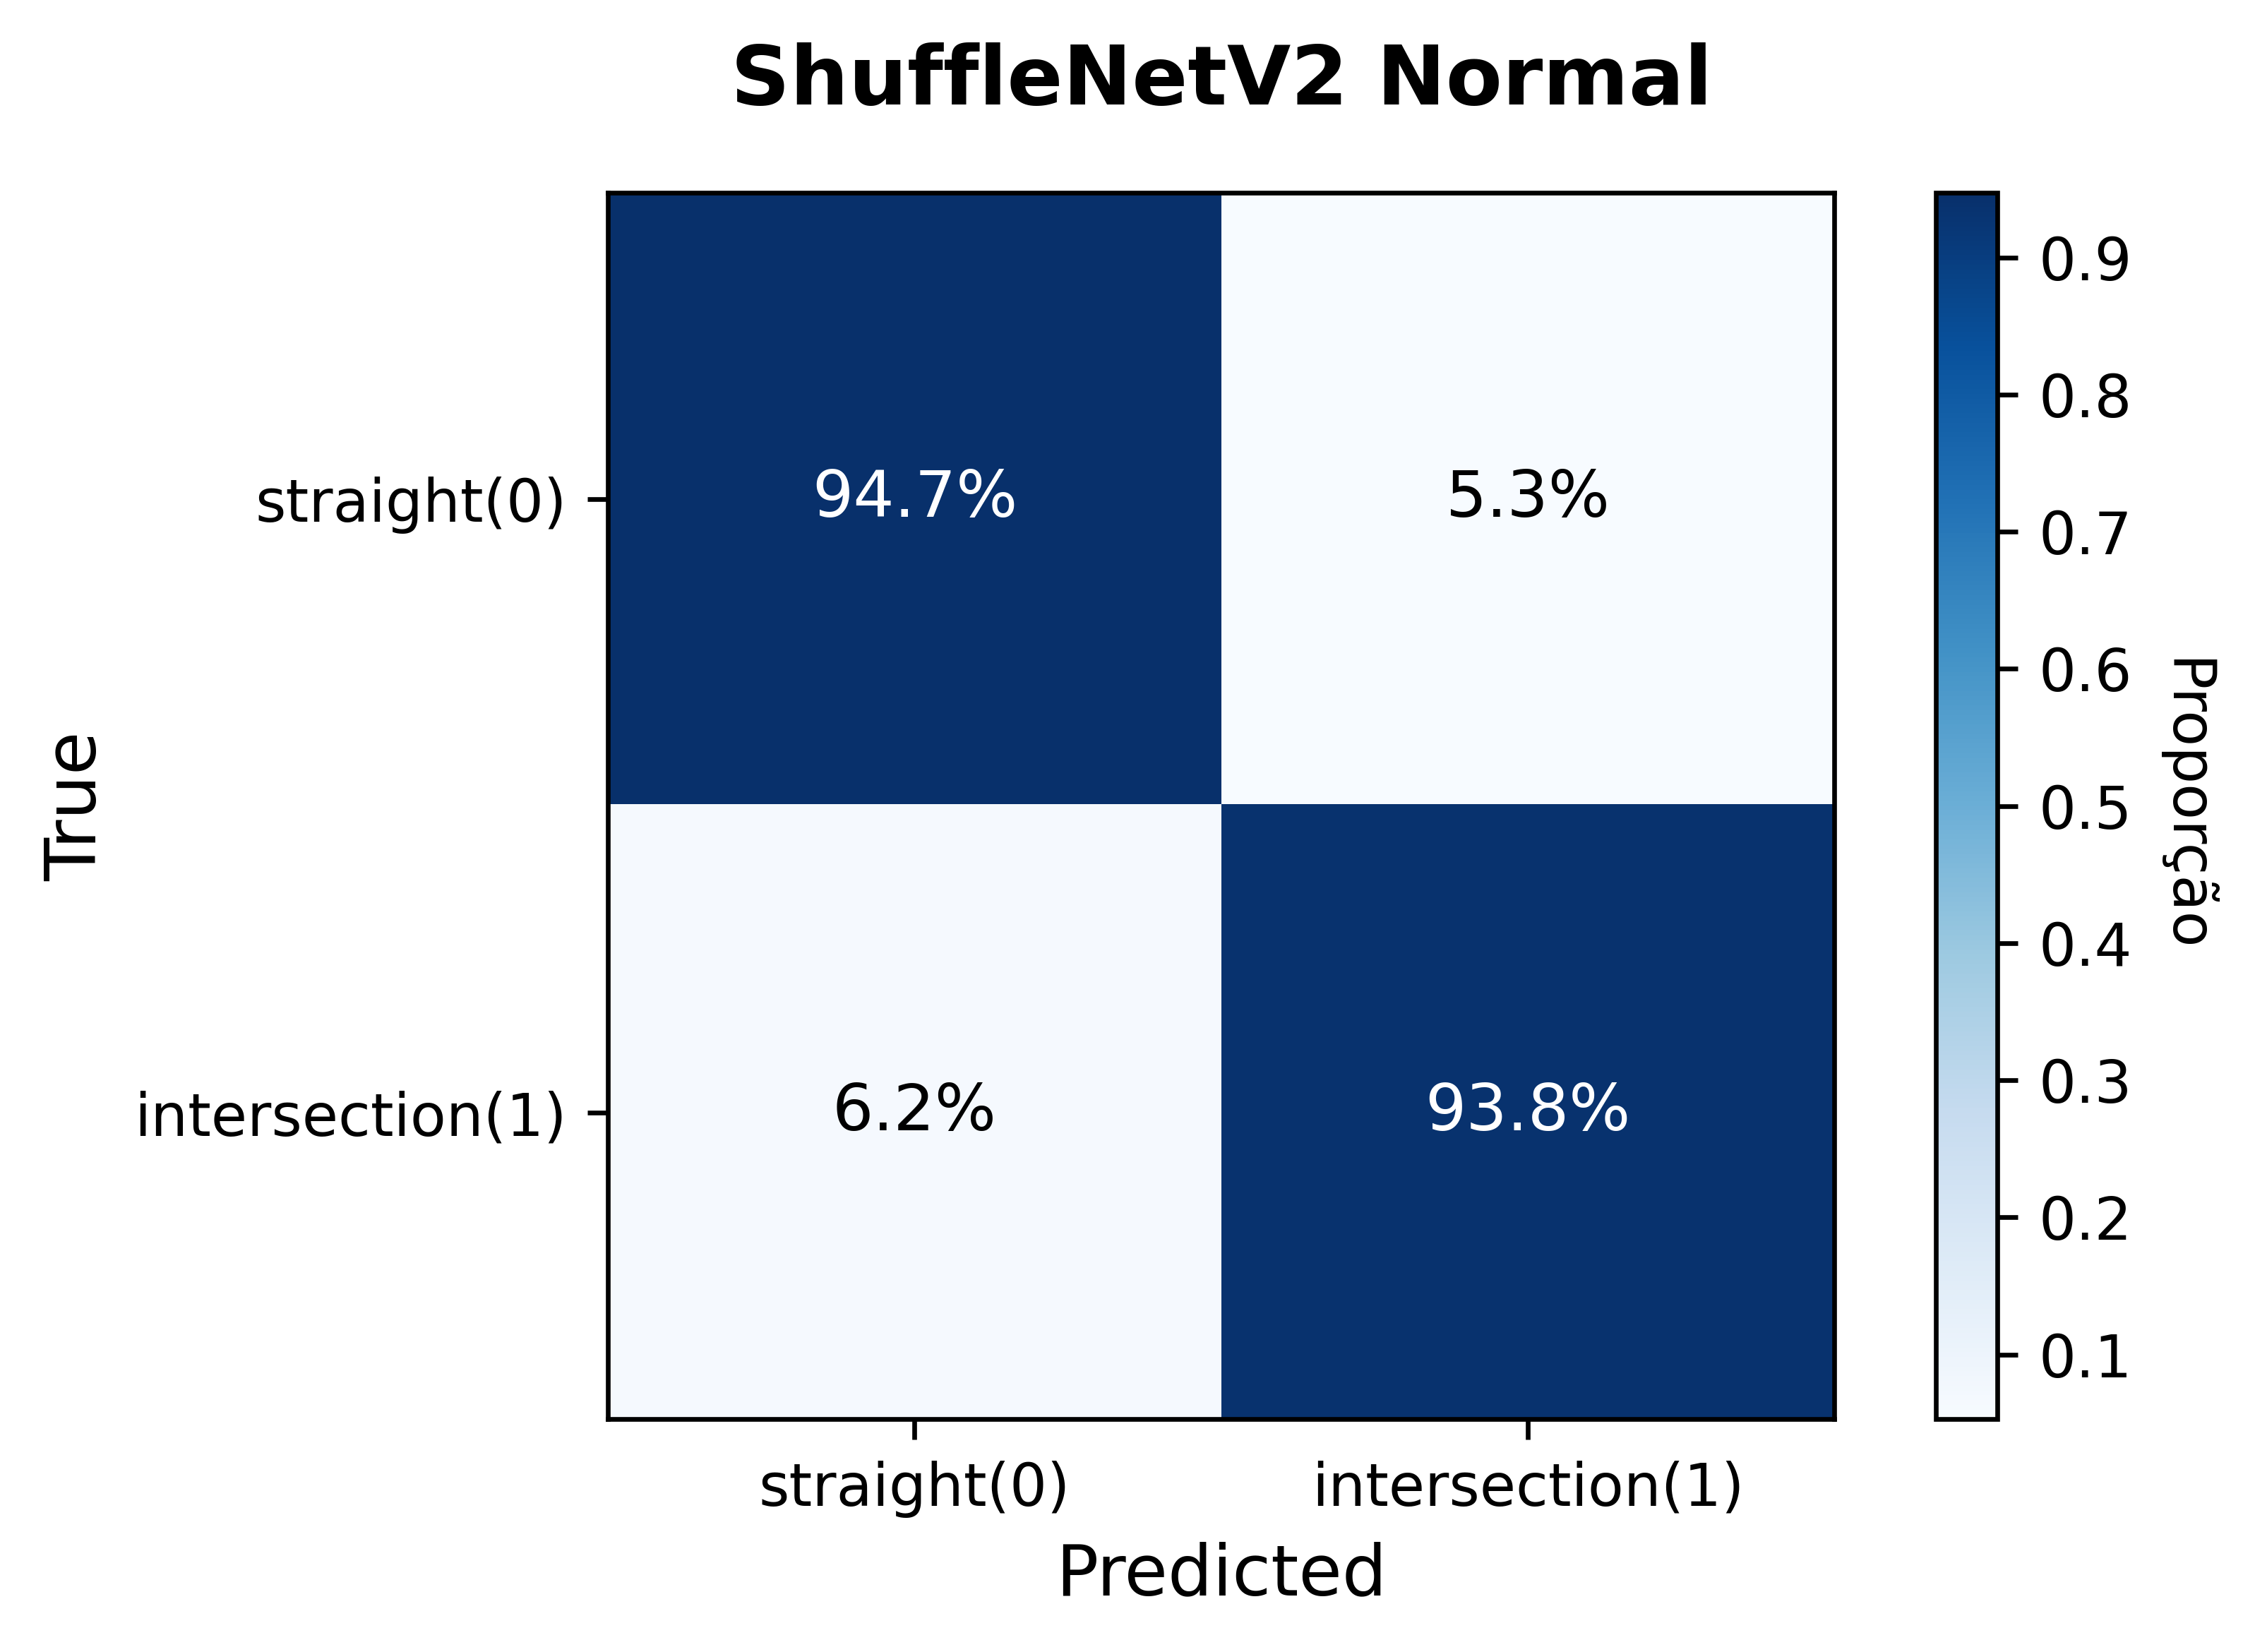

In [47]:
# Matriz de confusão
cm_s = confusion_matrix(y_true_s, y_pred_s, labels=[0, 1])

plot_confusion_matrix(cm_s, class_names, title="ShuffleNetV2", normalize=False)
plot_confusion_matrix(cm_s, class_names, title="ShuffleNetV2 Normal", normalize=True)

### FPS e Recursos

In [49]:
# Métricas de eficiência computacional
perf_s = measure_perf(
    shufflenet, test_loader, device,
    warmup_batches=3,     # pequeno aquecimento
    sample_interval=5,    # amostrar recursos a cada 5 batches
    max_batches=None      # ou limite ex.: 200, se desejar reduzir tempo
)

# Impressão consolidada
print("\n=== Eficiência Computacional (Shufflenet V2) ===")
print(f"FPS médio:                 {perf_s['fps_mean']:.2f}")
print(f"CPU média (%):             {perf_s['cpu_percent_mean']:.1f}" if not np.isnan(perf_s['cpu_percent_mean']) else "CPU média (%):             N/D")
print(f"RAM média (MB):            {perf_s['ram_mb_mean']:.1f}" if not np.isnan(perf_s['ram_mb_mean']) else "RAM média (MB):            N/D")
#print(f"GPU Util média (%):        {perf_s['gpu_util_percent_mean']3:.1f}" if not np.isnan(perf_s['gpu_util_percent_mean']) else "GPU Util média (%):        N/D")
print(f"GPU Mem aloc média (MB):   {perf_s['gpu_mem_mb_mean']:.1f}" if not np.isnan(perf_s['gpu_mem_mb_mean']) else "GPU Mem aloc média (MB):   N/D")
print(f"Frames contabilizados:     {perf_s['frames_counted']}")
print(f"Tempo total (s):           {perf_s['time_seconds']:.2f}")


=== Eficiência Computacional (Shufflenet V2) ===
FPS médio:                 480.81
CPU média (%):             667.8
RAM média (MB):            2383.3
GPU Mem aloc média (MB):   146.2
Frames contabilizados:     470
Tempo total (s):           0.98


# Validação

In [50]:
def build_perf_results_dict(perf_m, perf_e, perf_s):
    """Monta a lista consolidada com os resultados de desempenho dos três modelos."""
    # função utilitária para converter NaN em None (evita problemas nos rótulos dos gráficos)
    def _nan_to_none(x):
        try:
            return None if (x is None or np.isnan(x)) else float(x)
        except Exception:
            return None

    perf_results = [
        {
            "model": "MobileNetV3-Small",
            "fps": _nan_to_none(perf_m.get("fps_mean")),
            "cpu": _nan_to_none(perf_m.get("cpu_percent_mean")),      # % multi-core
            "ram": _nan_to_none(perf_m.get("ram_mb_mean")),           # MB
            "gpu": _nan_to_none(perf_m.get("gpu_util_percent_mean")), # % (se NVML disponível)
            "gpu_mem": _nan_to_none(perf_m.get("gpu_mem_mb_mean")),   # MB
        },
        {
            "model": "EfficientNet-B0",
            "fps": _nan_to_none(perf_e.get("fps_mean")),
            "cpu": _nan_to_none(perf_e.get("cpu_percent_mean")),
            "ram": _nan_to_none(perf_e.get("ram_mb_mean")),
            "gpu": _nan_to_none(perf_e.get("gpu_util_percent_mean")),
            "gpu_mem": _nan_to_none(perf_e.get("gpu_mem_mb_mean")),
        },
        {
            "model": "ShuffleNet V2",
            "fps": _nan_to_none(perf_s.get("fps_mean")),
            "cpu": _nan_to_none(perf_s.get("cpu_percent_mean")),
            "ram": _nan_to_none(perf_s.get("ram_mb_mean")),
            "gpu": _nan_to_none(perf_s.get("gpu_util_percent_mean")),
            "gpu_mem": _nan_to_none(perf_s.get("gpu_mem_mb_mean")),
        },
    ]
    return perf_results

In [51]:
def plot_fps_bar(perf_results):
    """Plota gráfico de barras comparando FPS médio entre os modelos."""
    models = [r["model"] for r in perf_results]
    fps_vals = [0.0 if r["fps"] is None else r["fps"] for r in perf_results]

    plt.figure(figsize=(10, 6), dpi=600)
    bars = plt.bar(models, fps_vals, alpha=0.85)
    plt.title("Comparação de FPS (validação)", fontsize=14, fontweight="bold")
    plt.ylabel("FPS médio")
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # anota valores nas barras
    for b, v in zip(bars, fps_vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + max(fps_vals)*0.02,
                 f"{v:.1f}", ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()

In [52]:
def plot_resources_grouped(perf_results):
    """Plota gráfico de barras agrupadas para CPU(%), RAM(MB), GPU(%), GPU Mem(MB) por modelo."""
    models = [r["model"] for r in perf_results]
    cpu_vals = [np.nan if r["cpu"] is None else r["cpu"] for r in perf_results]
    ram_vals = [np.nan if r["ram"] is None else r["ram"] for r in perf_results]
    gpu_vals = [np.nan if r["gpu"] is None else r["gpu"] for r in perf_results]
    gpu_mem_vals = [np.nan if r["gpu_mem"] is None else r["gpu_mem"] for r in perf_results]

    x = np.arange(len(models))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6), dpi=600)
    b1 = ax.bar(x - 1.5*width, np.nan_to_num(cpu_vals, nan=0.0), width, label="CPU (%)", alpha=0.85)
    b2 = ax.bar(x - 0.5*width, np.nan_to_num(ram_vals, nan=0.0), width, label="RAM (MB)", alpha=0.85)
    b3 = ax.bar(x + 0.5*width, np.nan_to_num(gpu_vals, nan=0.0), width, label="GPU Util (%)", alpha=0.85)
    b4 = ax.bar(x + 1.5*width, np.nan_to_num(gpu_mem_vals, nan=0.0), width, label="GPU Mem (MB)", alpha=0.85)

    ax.set_title("Consumo de recursos computacionais (validação)", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, rotation=0)
    ax.set_ylabel("Valor médio")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # rótulos acima das barras (pulando NaN = 0 com indicação)
    def _annotate(bars, values, fmt="{:.1f}"):
        for b, v in zip(bars, values):
            vnum = 0.0 if (v is None or (isinstance(v, float) and np.isnan(v))) else v
            label = "N/D" if (v is None or (isinstance(v, float) and np.isnan(v))) else fmt.format(vnum)
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(1.0, np.nanmax(np.nan_to_num(values, nan=0.0))*0.02),
                    label, ha="center", va="bottom", fontsize=9)

    _annotate(b1, cpu_vals, "{:.1f}")
    _annotate(b2, ram_vals, "{:.0f}")
    _annotate(b3, gpu_vals, "{:.1f}")
    _annotate(b4, gpu_mem_vals, "{:.0f}")

    plt.tight_layout()
    plt.show()

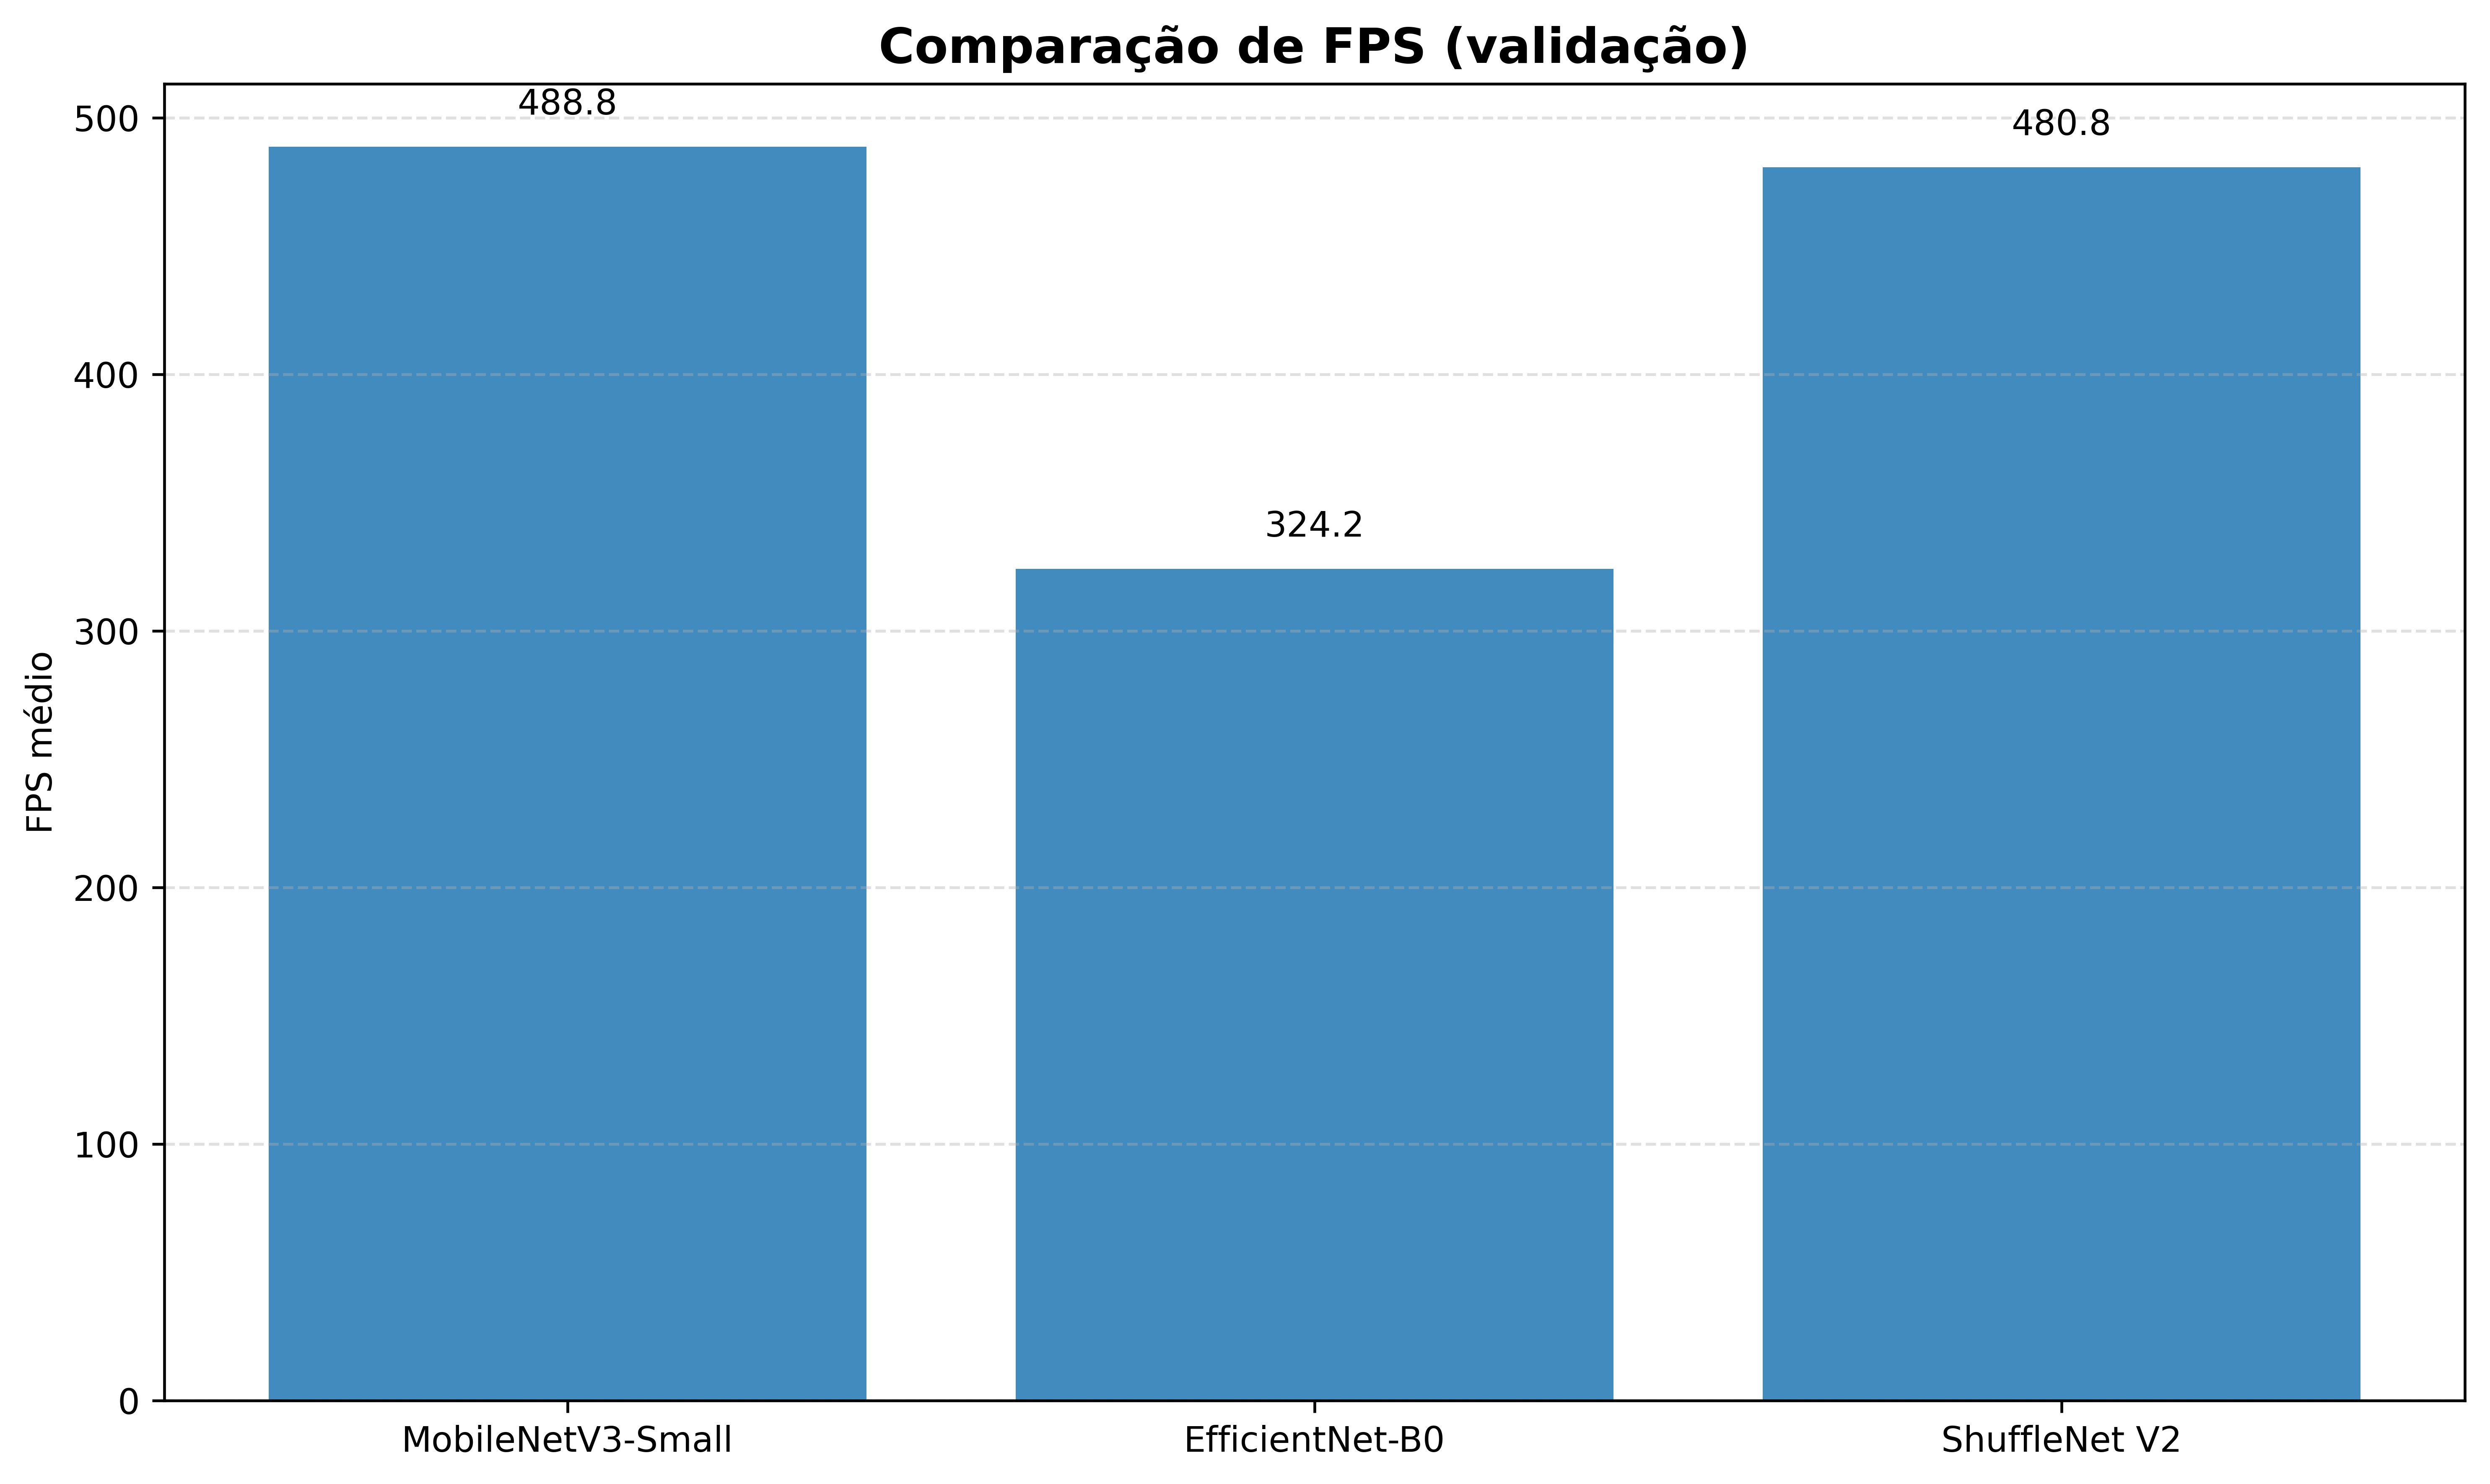

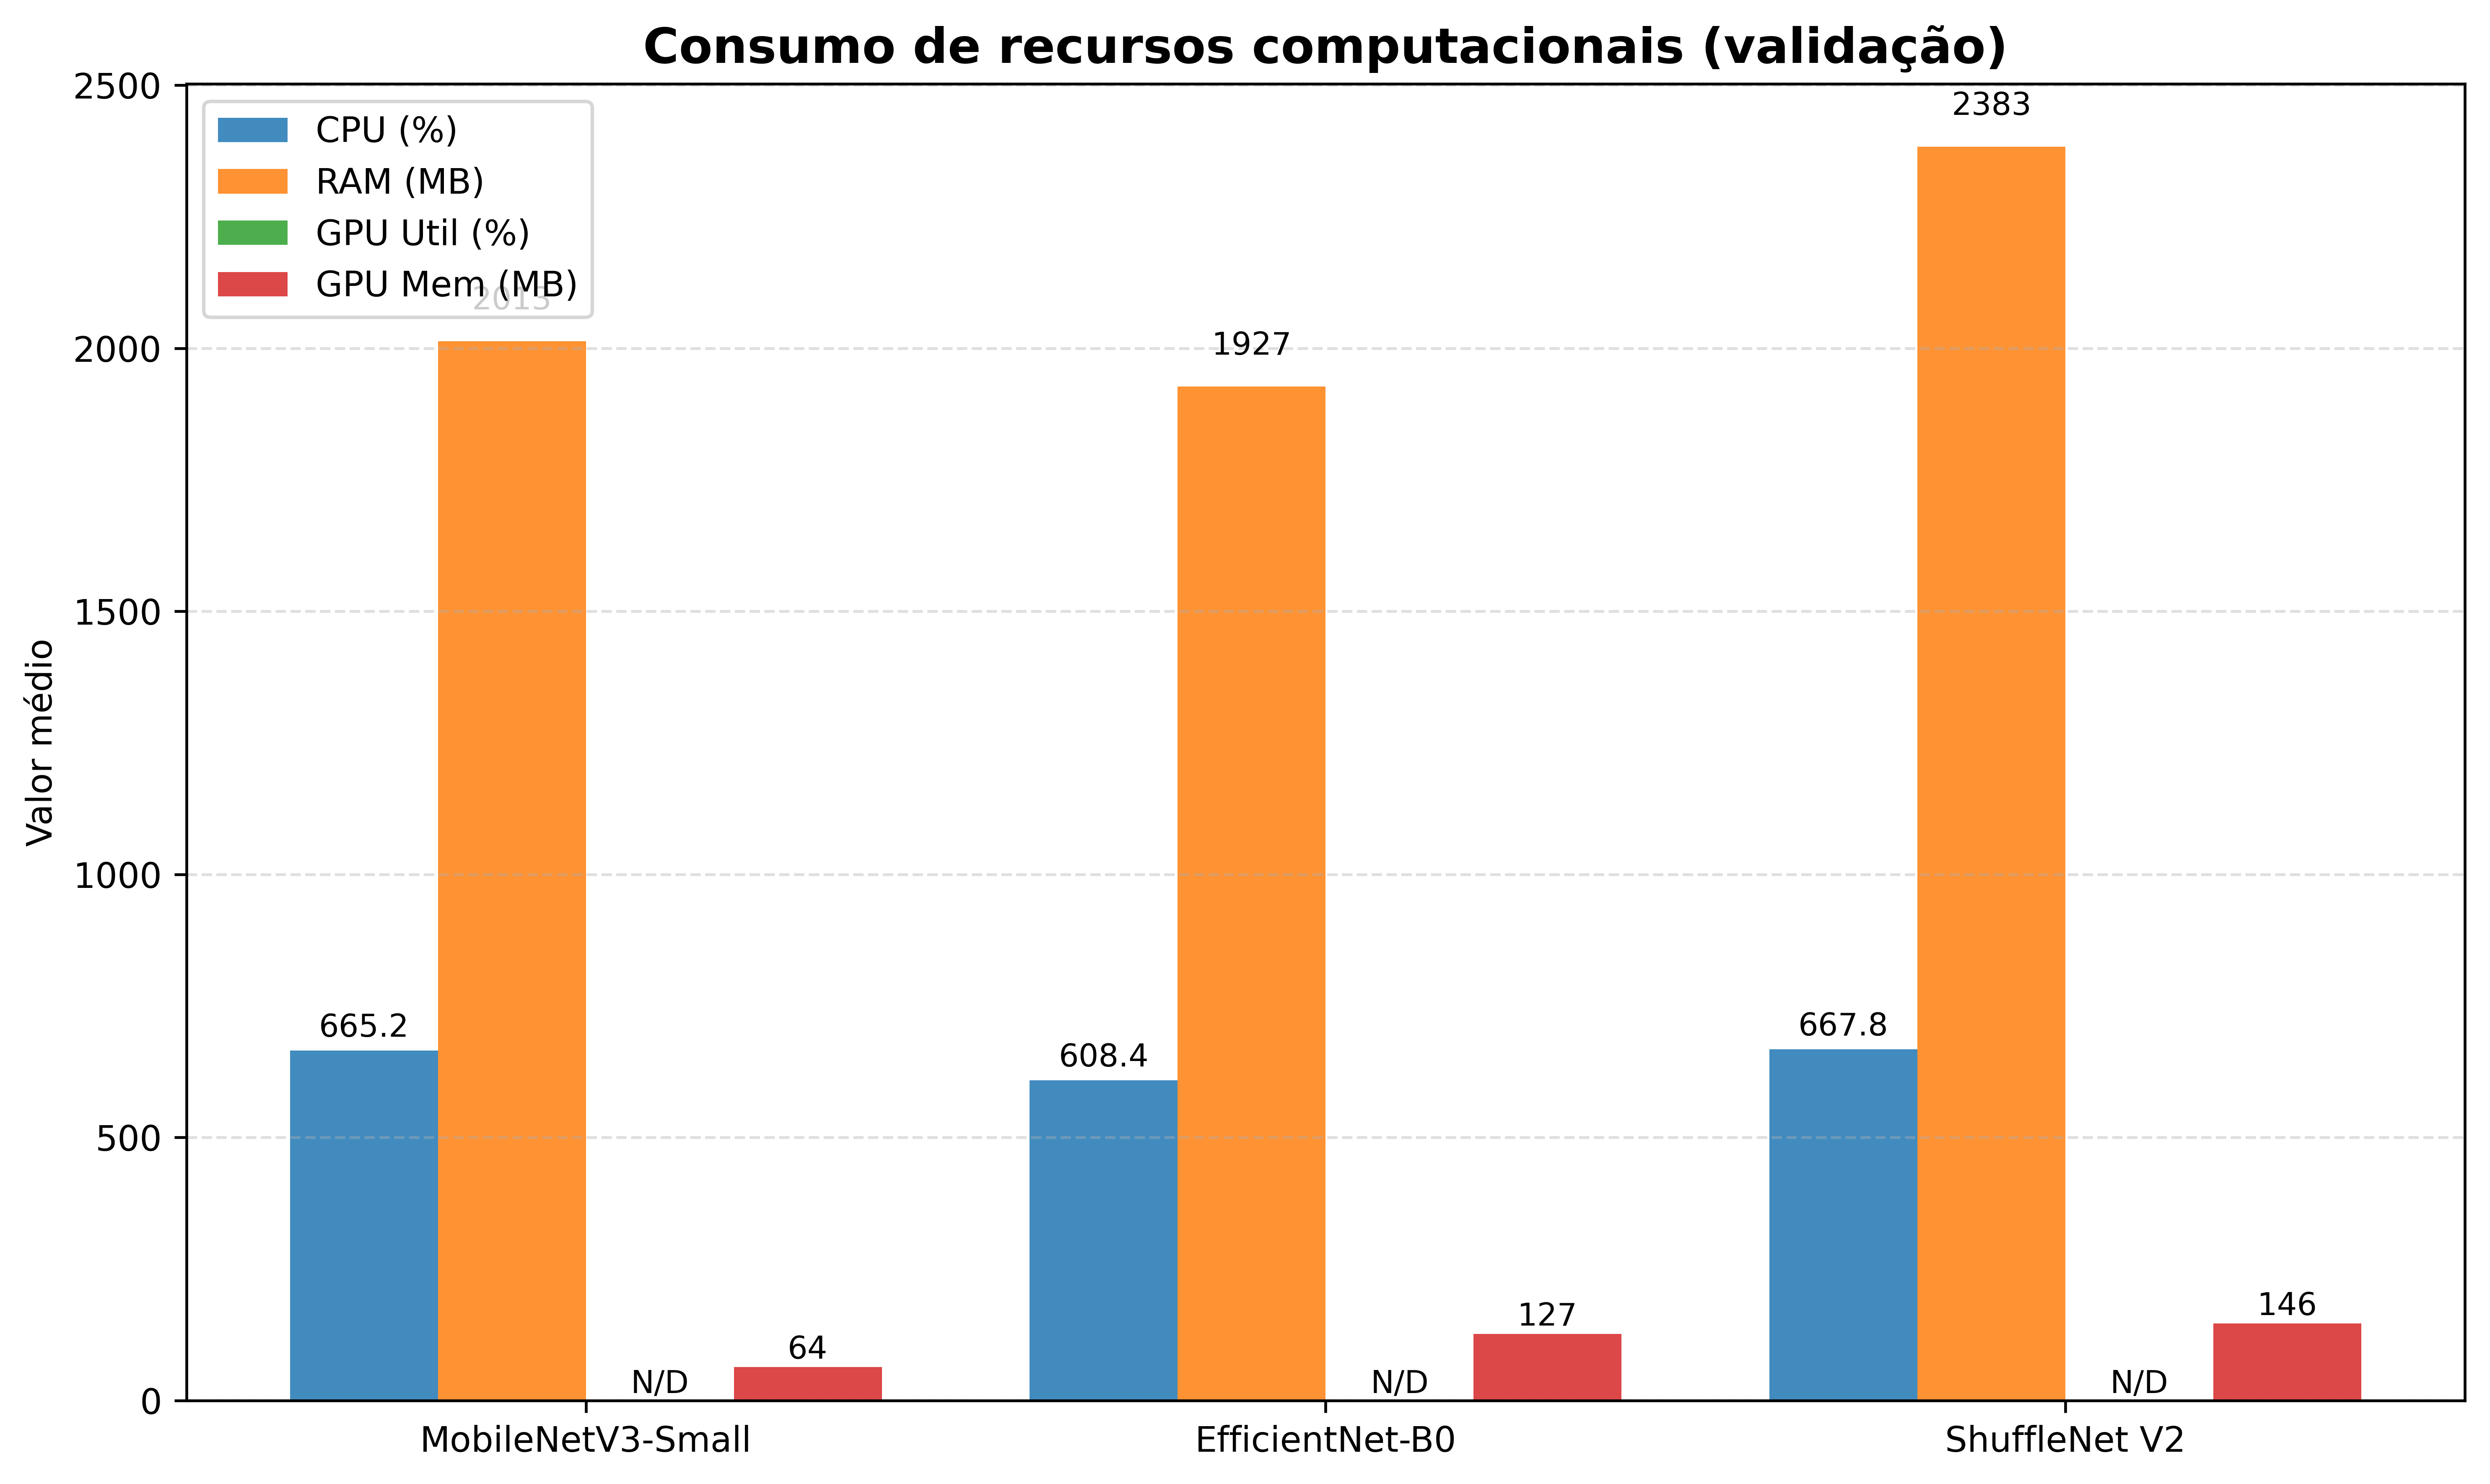

In [53]:
# Após medir perf_m, perf_e e perf_s, gere os gráficos conjuntos
perf_results = build_perf_results_dict(perf_m, perf_e, perf_s)
plot_fps_bar(perf_results)
plot_resources_grouped(perf_results)

In [54]:
# Resumo de desempenho dos modelos
summary_rows = [
    ("MobileNetV3-Small", f"{test_acc_m:.4f}", f"{test_f1_m:.4f}", f"{test_loss_m:.4f}"),
    ("EfficientNet‑B0", f"{test_acc_e:.4f}", f"{test_f1_e:.4f}", f"{test_loss_e:.4f}"),
    ("ShuffleNetV2", f"{test_acc_s:.4f}", f"{test_f1_s:.4f}", f"{test_loss_s:.4f}")
]
print("\n=== Test summary ===")
print("{:<20} | acc   | f1    | loss".format("model"))
print("-"*50)
for name, acc, f1s, loss in summary_rows:
    print("{:<20} | {:>5} | {:>5} | {:>5}".format(name, acc, f1s, loss))


=== Test summary ===
model                | acc   | f1    | loss
--------------------------------------------------
MobileNetV3-Small    | 0.9574 | 0.9573 | 0.1284
EfficientNet‑B0      | 0.9340 | 0.9339 | 0.1649
ShuffleNetV2         | 0.9426 | 0.9424 | 0.1536
